# Analisis Descriptivo Univariado — Dataset PyMEs

**Fuente**: `data/ia_pymes.xlsx` (368 encuestas a dueños/as de pequeñas y medianas empresas)

**Objetivo (Pipeline Step 2)**: caracterizar la muestra y las respuestas mediante estadistica
descriptiva univariada — tablas de frecuencia, graficos de barras y analisis de valores
faltantes — como base para las etapas posteriores de cruces y modelamiento.

## Tabla de contenidos

1. [Notas de preparacion de datos](#1.-Notas-de-preparacion-de-datos)
2. [Resumen del dataset](#2.-Resumen-del-dataset)
3. [Perfil demografico](#3.-Perfil-demografico)
    - [3.1 Sexo](#3.1-Sexo)
    - [3.2 Rango etario (edad)](#3.2-Rango-etario-(edad))
    - [3.3 Nivel educacional (niveduc)](#3.3-Nivel-educacional-(niveduc))
    - [3.4 Ocupacion](#3.4-Ocupacion)
    - [3.5 Grupo socioeconomico (nse)](#3.5-Grupo-socioeconomico-(nse))
4. [Variables de respuesta del negocio](#4.-Variables-de-respuesta-del-negocio)
    - [4.1 p01 — Tarea que mas tiempo consume](#4.1-p01-—-Tarea-que-mas-tiempo-consume)
    - [4.2 p02 — Principal fuente de ayuda](#4.2-p02-—-Principal-fuente-de-ayuda)
    - [4.3 p03 — Barreras para crecer](#4.3-p03-—-Barreras-para-crecer)
    - [4.4 p04 — Tiempo semanal dispuesto a aprender](#4.4-p04-—-Tiempo-semanal-dispuesto-a-aprender)
5. [Analisis de valores faltantes](#5.-Analisis-de-valores-faltantes)
6. [Resumen de hallazgos clave](#6.-Resumen-de-hallazgos-clave)


## 1. Notas de preparacion de datos

Antes de este analisis se revisaron los helpers compartidos (`analysis_helpers.py`, entregable
del Step 1) y se corrigieron tres inconsistencias que habrian distorsionado las frecuencias de
`p03`/`p04` y el ordenamiento de `edad`/`niveduc`:

1. **Mapeo de columnas incompleto (`PYMES_CODES`)** — el libro `ia_pymes.xlsx` tiene 13 columnas
   (6 demograficas + 7 de respuesta: `p01`, `p01_otro`, `p02`, `p02_otro`, `p03`, `p03_otro`,
   `p04`), pero la lista original solo declaraba 11 codigos. Esto desplazaba el mapeo: la
   columna de "otro" de `p02` quedaba etiquetada como `p03`, la pregunta real de barreras
   ("¿Qué te frena...?") quedaba etiquetada como `p04`, y la pregunta de tiempo semanal quedaba
   sin mapear. Se agregaron `p02_otro` y `p03_otro` a `PYMES_CODES` para alinear el mapeo con el
   diccionario de columnas documentado en `CLAUDE.md`.
2. **`lowercase_df()` no normalizaba columnas de texto** — con pandas 3.0, `read_excel` infiere
   dtype `str` (no `object`) para columnas de texto, y la condicion original
   (`s.dtype == object`) las omitia silenciosamente. Se amplio la condicion con
   `pd.api.types.is_string_dtype(s.dtype)` para que `p01`–`p04` tambien queden en minusculas,
   consistente con el resto del pipeline.
3. **Categorias con guion mal normalizadas** — valores como `"[31 - 40]"` (con espacios) no
   calzaban con la categoria canonica `"[31-40]"`, dejando `edad` practicamente sin orden logico.
   Se agrego un paso de normalizacion de guiones en `normalize_text()`.
4. **`niveduc` con niveles no documentados** — la muestra incluye "basica incompleta/completa"
   y "postgrado", ausentes del orden canonico original. Al ser extremos inequivocos (por debajo
   de "media" y por encima de "universitaria completa" respectivamente), se agregaron a
   `CATEGORY_ORDERS["niveduc"]`.

`ocupacion` tambien contiene 3 categorias fuera del orden canonico (`alto(a) ejecutivo(a)`,
`ejecutivo(a) medio(a) / profesional independiente`, `trabajos menores e informales`) cuya
posicion jerarquica es ambigua sin definicion de negocio; se dejan intencionalmente sin ordenar
y se documentan como hallazgo de calidad de datos en la Seccion 3.4, en vez de asumir un orden.


In [1]:
from analysis_helpers import *
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

dfpymes = load_survey(PYMES_PATH, PYMES_CODES, dataset="pymes")
set_theme("light")


Rename map (raw header -> code):
  id         <- 'ID'
  sexo       <- 'SEXO'
  edad       <- 'RANGO ETARIO'
  niveduc    <- '¿NIVEL EDUCACIONAL?'
  ocupacion  <- '¿TIPO DE TRABAJO?'
  nse        <- 'GRUPO NSE'
  p01        <- 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)'
  p01_otro   <- 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))'
  p02        <- 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)'
  p02_otro   <- 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))'
  p03        <- '¿Qué te frena hoy para hacer crecer tu negocio? (Total)'
  p03_otro   <- '¿Qué te frena hoy para hacer crecer

/Users/tomas/github/icd_ia/analysis_helpers.py:381: UserWarning: Column 'ocupacion' has 3 value(s) outside the canonical ordering: ['alto(a) ejecutivo(a)', 'ejecutivo(a) medio(a) / profesional independiente', 'trabajos menores e informales'] -- appended as trailing categories.
  df = apply_categoricals(df, strict=strict, verbose=verbose)


<module 'matplotlib.pyplot' from '/Users/tomas/.pyenv/versions/datascience/lib/python3.14/site-packages/matplotlib/pyplot.py'>

## 2. Resumen del dataset

Vista general de columnas, tipos de dato y completitud antes de entrar al detalle
variable por variable.

In [2]:
labeled_info(dfpymes)

,code,label,dtype,n_valid,n_missing,pct_missing,n_unique
0,id,ID,int64,368,0,0.0,368
1,sexo,SEXO,category,368,0,0.0,2
2,edad,RANGO ETARIO,category,368,0,0.0,5
3,niveduc,¿NIVEL EDUCACIONAL?,category,368,0,0.0,9
4,ocupacion,¿TIPO DE TRABAJO?,category,368,0,0.0,10
5,nse,GRUPO NSE,category,368,0,0.0,4
6,p01,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",str,368,0,0.0,5
7,p01_otro,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",float64,0,368,100.0,0
8,p02,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",str,368,0,0.0,5
9,p02_otro,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",float64,0,368,100.0,0


In [3]:
labeled_head(dfpymes, 5)

,id\nID,sexo\nSEXO,edad\nRANGO ETARIO,niveduc\n¿NIVEL EDUCACIONAL?,ocupacion\n¿TIPO DE TRABAJO?,nse\nGRUPO NSE,"p01\nDe las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)","p01_otro\nDe las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))","p02\nCuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)","p02_otro\nCuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))",p03\n¿Qué te frena hoy para hacer crecer tu negocio? (Total),p03_otro\n¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),"p04\nSi una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?"
0,1,masculino,[51-60],media completa,jubilado(a),d+e,llevar contabilidad,NaN,familia o amigos,NaN,falta de capital,NaN,1 a 2 horas
1,2,femenino,[51-60],tecnica superior completa,estudiante,c3,atender clientes,NaN,redes sociales / internet,NaN,falta de capital,NaN,1 a 2 horas
2,3,masculino,[41-50],universitaria completa,ejecutivo(a) medio(a) / profesional independiente,abc1,hacer publicidad,NaN,familia o amigos,NaN,falta de capital,NaN,más de 4 horas
3,4,femenino,[31-40],tecnica superior incompleta,dueño(a) de casa,c3,llevar contabilidad,NaN,familia o amigos,NaN,falta de capital,NaN,1 hora o menos
4,5,masculino,[18-30],universitaria completa,empleado(a) administrativo(a) / tecnico,abc1,atender clientes,NaN,nadie / lo resuelvo solo,NaN,falta de capital,NaN,más de 4 horas


### Interpretacion — Resumen del dataset (Hallazgo 1)

El dataset tiene **368 respuestas y 13 columnas**: 5 variables demograficas (`sexo`, `edad`,
`niveduc`, `ocupacion`, `nse`), 4 preguntas cerradas de negocio (`p01`–`p04`) y 3 campos de
texto libre "otro" (`p01_otro`, `p02_otro`, `p03_otro`). Las 9 variables categoricas principales
tienen **0% de valores faltantes** — cobertura completa para el analisis univariado. Los 3
campos "otro" estan **100% vacios** (ver Seccion 5): ningun respondente selecciono la opcion
abierta, por lo que no aportan senal adicional en este dataset.

## 3. Perfil demografico

### 3.1 Sexo

In [4]:
tbl_sexo = labeled_value_counts_detailed(dfpymes, "sexo")
tbl_sexo

sexo - SEXO   (n = 368)
------------------------------------------------------------------------
  femenino                             192   52.2%  ##############################
  masculino                            176   47.8%  ############################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,femenino,192,52.2,52.2,52.2
1,masculino,176,47.8,47.8,100.0


findfont: Failed to find font weight semibold, now using 700.


'/Users/tomas/github/icd_ia/figures/pymes/pymes_sexo_bar.png'

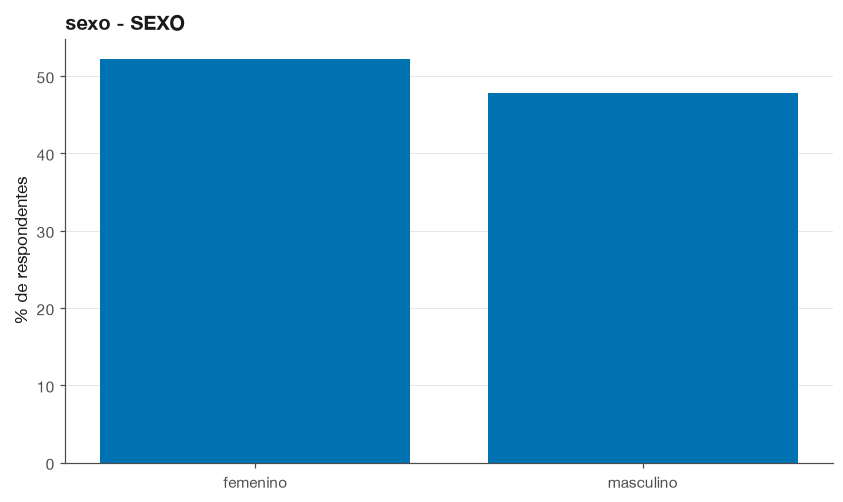

In [5]:
ax = bar_freq(dfpymes, "sexo", horizontal=False)
save_fig(ax, "pymes_sexo_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 2):** la muestra esta **casi equilibrada por genero**
(52.2% femenino vs. 47.8% masculino, 192 vs. 176 respondentes), sin sesgo relevante que
condicione las comparaciones por sexo en etapas posteriores.

### 3.2 Rango etario (edad)

In [6]:
tbl_edad = labeled_value_counts_detailed(dfpymes, "edad")
tbl_edad

edad - RANGO ETARIO   (n = 368)
------------------------------------------------------------------------
  [18-30]                               55   14.9%  ###################
  [31-40]                               75   20.4%  ##########################
  [41-50]                               86   23.4%  ##############################
  [51-60]                               79   21.5%  ############################
  [61+]                                 73   19.8%  #########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,[18-30],55,14.9,14.9,14.9
1,[31-40],75,20.4,20.4,35.3
2,[41-50],86,23.4,23.4,58.7
3,[51-60],79,21.5,21.5,80.2
4,[61+],73,19.8,19.8,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_edad_bar.png'

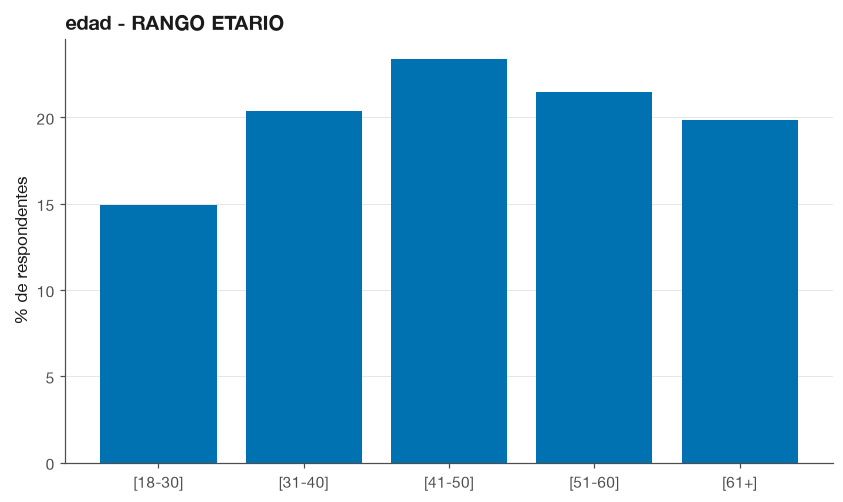

In [7]:
ax = bar_freq(dfpymes, "edad", horizontal=False)
save_fig(ax, "pymes_edad_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 3):** la edad **se concentra en tramos medios y altos**: los
grupos `[41-50]` (23.4%) y `[51-60]` (21.5%) son los mas numerosos, y sumando `[61+]` (19.8%)
el **64.7% de los dueños/as de PyMEs tiene 41 años o mas**. El tramo joven `[18-30]` es el
menos representado (14.9%), lo que sugiere que el emprendimiento PyME en esta muestra es
mayoritariamente una actividad de adultos de mediana edad y mayores, no de emprendedores
jovenes.

### 3.3 Nivel educacional (niveduc)

In [8]:
tbl_niveduc = labeled_value_counts_detailed(dfpymes, "niveduc")
tbl_niveduc

niveduc - ¿NIVEL EDUCACIONAL?   (n = 368)
------------------------------------------------------------------------
  basica incompleta                      1    0.3%  
  basica completa                        4    1.1%  #
  media incompleta                       6    1.6%  ##
  media completa                        97   26.4%  ##############################
  tecnica superior incompleta           41   11.1%  #############
  tecnica superior completa             79   21.5%  ########################
  universitaria incompleta              47   12.8%  ###############
  universitaria completa                83   22.6%  ##########################
  postgrado                             10    2.7%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,basica incompleta,1,0.3,0.3,0.3
1,basica completa,4,1.1,1.1,1.4
2,media incompleta,6,1.6,1.6,3.0
3,media completa,97,26.4,26.4,29.4
4,tecnica superior incompleta,41,11.1,11.1,40.5
5,tecnica superior completa,79,21.5,21.5,62.0
6,universitaria incompleta,47,12.8,12.8,74.8
7,universitaria completa,83,22.6,22.6,97.4
8,postgrado,10,2.7,2.7,100.1


'/Users/tomas/github/icd_ia/figures/pymes/pymes_niveduc_bar.png'

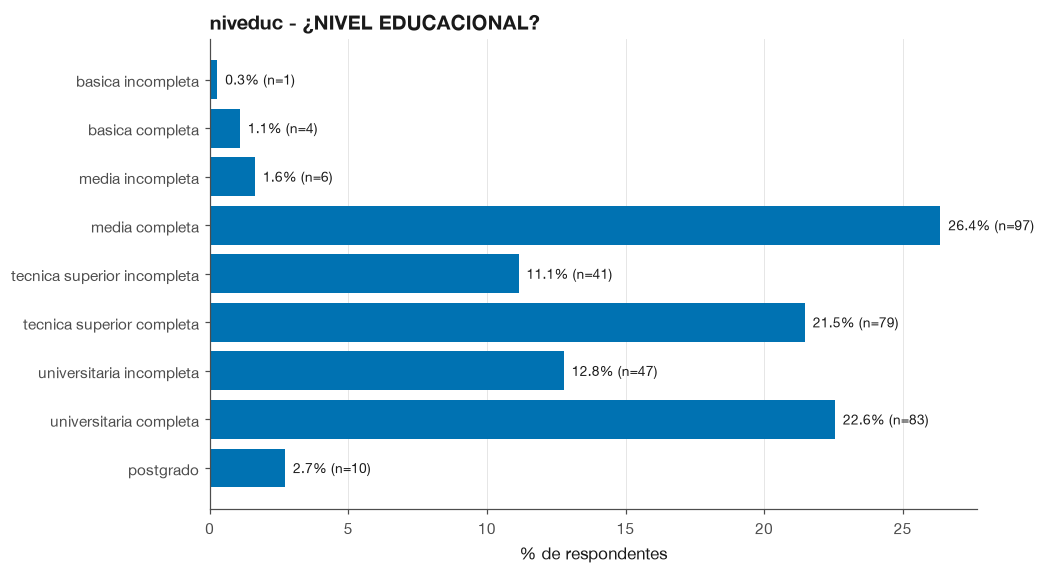

In [9]:
ax = bar_freq(dfpymes, "niveduc", horizontal=True)
save_fig(ax, "pymes_niveduc_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 4):** el nivel educacional es **heterogeneo pero con clara
mayoria post-secundaria**: sumando tecnica superior (completa+incompleta, 32.6%) y
universitaria (completa+incompleta, 35.4%), el **70.7% de la muestra tiene formacion
post-secundaria**, aunque gran parte incompleta. La educacion basica es marginal (1.4%
combinado) y el postgrado es minoritario (2.7%). Esto contradice la percepcion habitual de
que las/os dueñas/os de PyMEs tienen bajo nivel educativo formal: en esta muestra predomina
la educacion media completa (26.4%) y superior, no la basica.

### 3.4 Ocupacion

In [10]:
tbl_ocupacion = labeled_value_counts_detailed(dfpymes, "ocupacion")
tbl_ocupacion

ocupacion - ¿TIPO DE TRABAJO?   (n = 368)
------------------------------------------------------------------------
  cesante                               25    6.8%  ##########
  estudiante                            21    5.7%  ########
  dueño(a) de casa                      32    8.7%  ############
  jubilado(a)                           36    9.8%  ##############
  oficio menor                          20    5.4%  ########
  oficio calificado                     31    8.4%  ############
  empleado(a) administrativo(a) /       77   20.9%  ##############################
  alto(a) ejecutivo(a)                  13    3.5%  #####
  ejecutivo(a) medio(a) / profesio      54   14.7%  #####################
  trabajos menores e informales         59   16.0%  #######################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,cesante,25,6.8,6.8,6.8
1,estudiante,21,5.7,5.7,12.5
2,dueño(a) de casa,32,8.7,8.7,21.2
3,jubilado(a),36,9.8,9.8,31.0
4,oficio menor,20,5.4,5.4,36.4
5,oficio calificado,31,8.4,8.4,44.8
6,empleado(a) administrativo(a) / tecnico,77,20.9,20.9,65.7
7,alto(a) ejecutivo(a),13,3.5,3.5,69.2
8,ejecutivo(a) medio(a) / profesional independiente,54,14.7,14.7,83.9
9,trabajos menores e informales,59,16.0,16.0,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_ocupacion_bar.png'

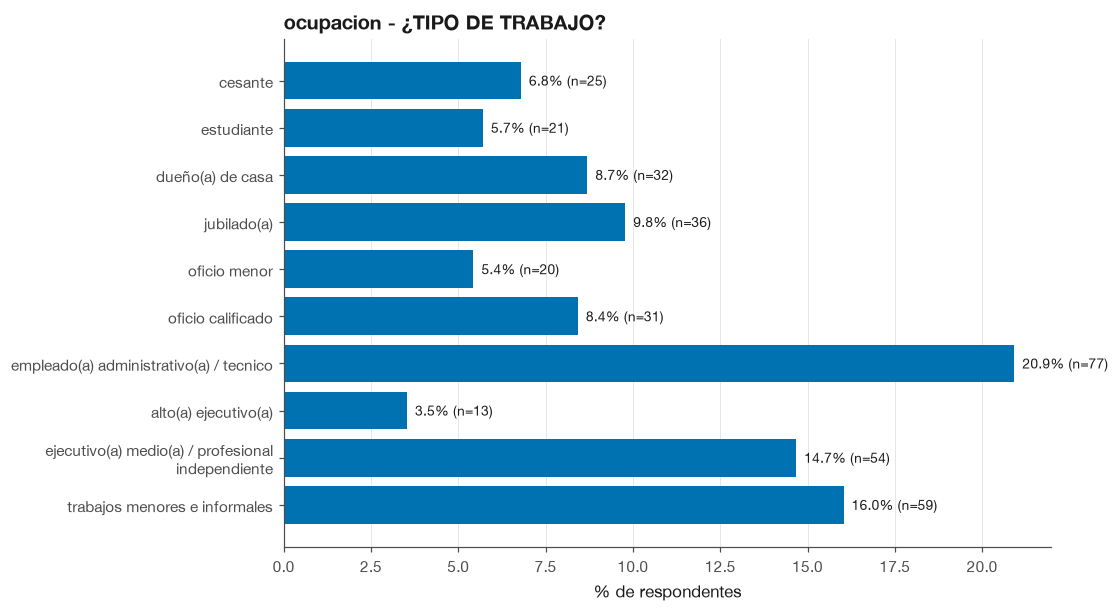

In [11]:
ax = bar_freq(dfpymes, "ocupacion", horizontal=True)
save_fig(ax, "pymes_ocupacion_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 5):** la categoria mas frecuente es "empleado(a)
administrativo(a) / tecnico" (20.9%), seguida de "trabajos menores e informales" (16.0%) y
"ejecutivo(a) medio(a) / profesional independiente" (14.7%) — es decir, muchas/os dueñas/os de
PyME combinan el negocio con otra ocupacion declarada, desde trabajo informal hasta roles
profesionales. **Nota de calidad de datos:** las 3 categorias mencionadas junto con
"alto(a) ejecutivo(a)" (3.5%) no forman parte del orden jerarquico documentado en
`CLAUDE.md`/`CATEGORY_ORDERS`, por lo que quedan como categorias adicionales sin una posicion
jerarquica definida (ver Seccion 1). Cualquier analisis ordinal de `ocupacion` en etapas
posteriores deberia primero decidir, junto al equipo de negocio, donde ubicar estos 3 niveles
antes de tratarlos como una escala.

### 3.5 Grupo socioeconomico (nse)

In [12]:
tbl_nse = labeled_value_counts_detailed(dfpymes, "nse")
tbl_nse

nse - GRUPO NSE   (n = 368)
------------------------------------------------------------------------
  d+e                                   66   17.9%  ###############
  c3                                   122   33.2%  ############################
  c2                                   131   35.6%  ##############################
  abc1                                  49   13.3%  ###########
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,d+e,66,17.9,17.9,17.9
1,c3,122,33.2,33.2,51.1
2,c2,131,35.6,35.6,86.7
3,abc1,49,13.3,13.3,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_nse_bar.png'

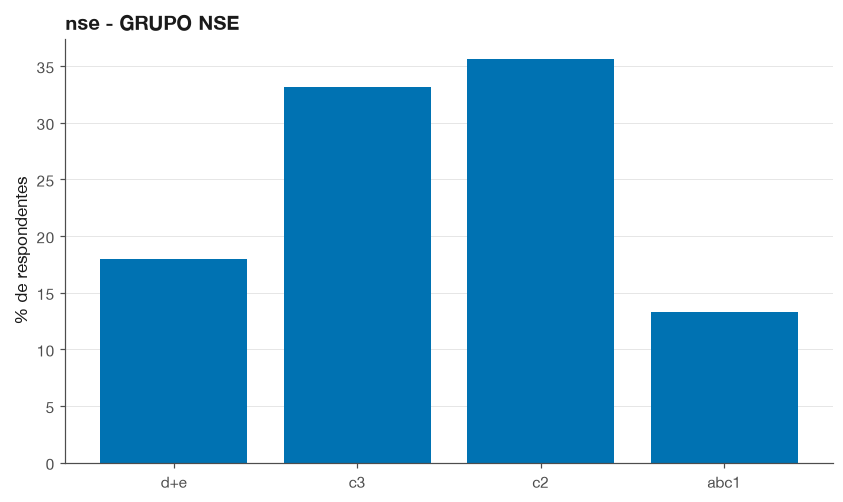

In [13]:
ax = bar_freq(dfpymes, "nse", horizontal=False)
save_fig(ax, "pymes_nse_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 6):** el grupo socioeconomico esta **concentrado en el
segmento medio** (c3 33.2% + c2 35.6% = 68.8%), con menor representacion de los extremos
(d+e 17.9%, abc1 13.3%). No hay valores faltantes en `nse` para este dataset (a diferencia del
dataset de competentes, donde si se observa 1 caso sin dato).

## 4. Variables de respuesta del negocio

### 4.1 p01 — Tarea que mas tiempo consume

In [14]:
tbl_p01 = labeled_value_counts_detailed(dfpymes, "p01")
tbl_p01

p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)   (n = 368)
------------------------------------------------------------------------
  llevar contabilidad                   59   16.0%  ##################
  atender clientes                     100   27.2%  ##############################
  hacer publicidad                      94   25.5%  ############################
  ninguna me quita tiempo / no apl      55   14.9%  ################
  controlar inventario                  60   16.3%  ##################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,llevar contabilidad,59,16.0,16.0,16.0
1,atender clientes,100,27.2,27.2,43.2
2,hacer publicidad,94,25.5,25.5,68.7
3,ninguna me quita tiempo / no aplica,55,14.9,14.9,83.6
4,controlar inventario,60,16.3,16.3,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p01_bar.png'

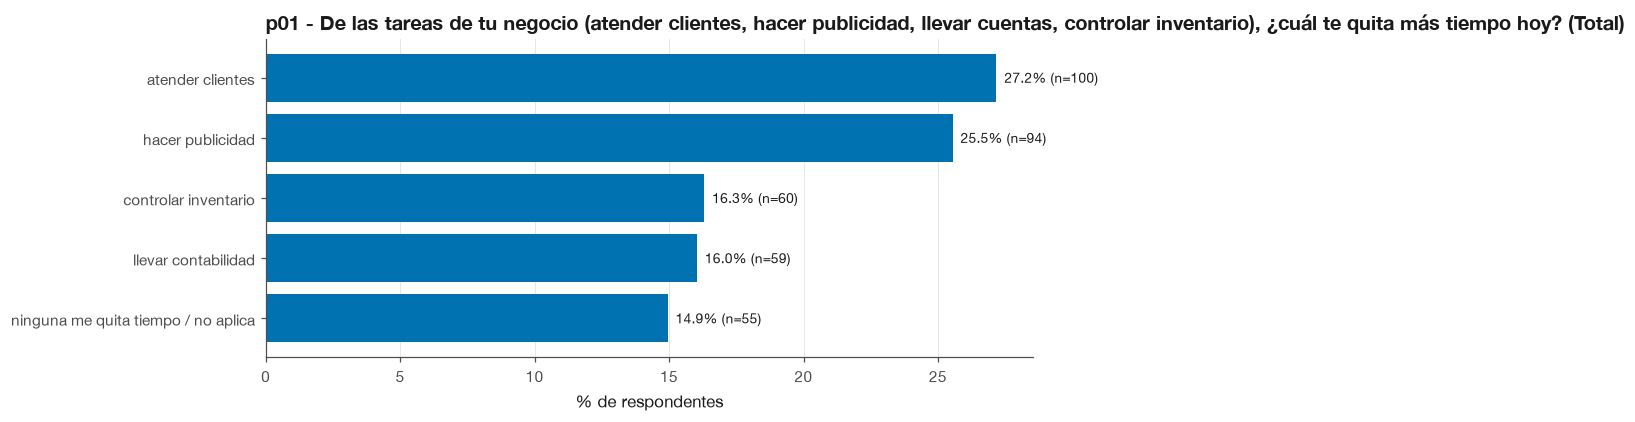

In [15]:
ax = bar_freq(dfpymes, "p01", horizontal=True)
save_fig(ax, "pymes_p01_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 7):** no hay una tarea claramente dominante: "atender
clientes" (27.2%) y "hacer publicidad" (25.5%) concentran mas de la mitad de las respuestas,
seguidas por "controlar inventario" (16.3%) y "llevar contabilidad" (16.0%) en niveles
similares. Un 14.9% declara que "ninguna" tarea le quita tiempo. La distribucion relativamente
pareja sugiere que **no existe un unico cuello de botella operativo** en el negocio promedio;
soluciones digitales dirigidas a una sola tarea (p.ej. solo contabilidad) dejarian fuera a la
mayoria de la demanda.

### 4.2 p02 — Principal fuente de ayuda

In [16]:
tbl_p02 = labeled_value_counts_detailed(dfpymes, "p02")
tbl_p02

p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)   (n = 368)
------------------------------------------------------------------------
  familia o amigos                     189   51.4%  ##############################
  redes sociales / internet             78   21.2%  ############
  nadie / lo resuelvo solo              47   12.8%  #######
  un curso o capacitación               38   10.3%  ######
  sercotec u otra institución públ      16    4.3%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,familia o amigos,189,51.4,51.4,51.4
1,redes sociales / internet,78,21.2,21.2,72.6
2,nadie / lo resuelvo solo,47,12.8,12.8,85.4
3,un curso o capacitación,38,10.3,10.3,95.7
4,sercotec u otra institución pública,16,4.3,4.3,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p02_bar.png'

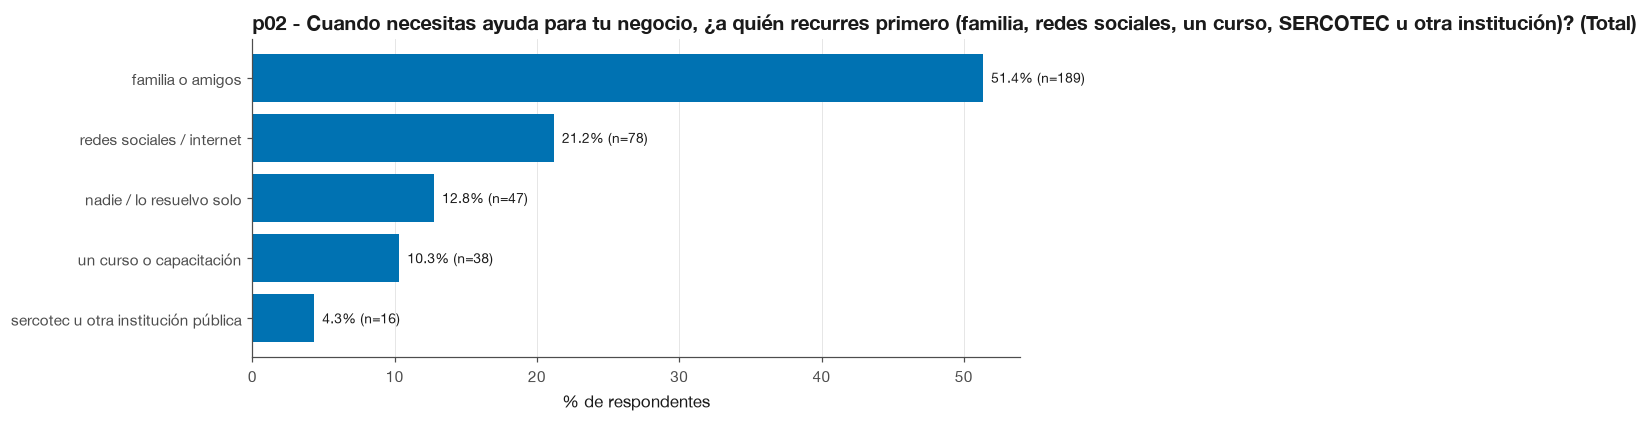

In [17]:
ax = bar_freq(dfpymes, "p02", horizontal=True)
save_fig(ax, "pymes_p02_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 8):** la fuente de ayuda **claramente dominante es
"familia o amigos"** (51.4%, mas de la mitad de la muestra), seguida por "redes
sociales / internet" (21.2%). El apoyo institucional formal es marginal: "un curso o
capacitacion" (10.3%) y especialmente "SERCOTEC u otra institucion publica" (solo 4.3%). Este
patron revela una **brecha de alcance institucional**: los canales formales de apoyo al
emprendimiento llegan a una fraccion muy pequeña de la muestra, mientras que la red social
informal absorbe la mayor parte de la demanda de ayuda.

### 4.3 p03 — Barreras para crecer

In [18]:
tbl_p03 = labeled_value_counts_detailed(dfpymes, "p03")
tbl_p03

p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total)   (n = 368)
------------------------------------------------------------------------
  falta de capital                     222   60.3%  ##############################
  falta de conocimiento                 28    7.6%  ####
  falta de clientes                     53   14.4%  #######
  falta de tiempo                       43   11.7%  ######
  nada me frena                         22    6.0%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,falta de capital,222,60.3,60.3,60.3
1,falta de conocimiento,28,7.6,7.6,67.9
2,falta de clientes,53,14.4,14.4,82.3
3,falta de tiempo,43,11.7,11.7,94.0
4,nada me frena,22,6.0,6.0,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p03_bar.png'

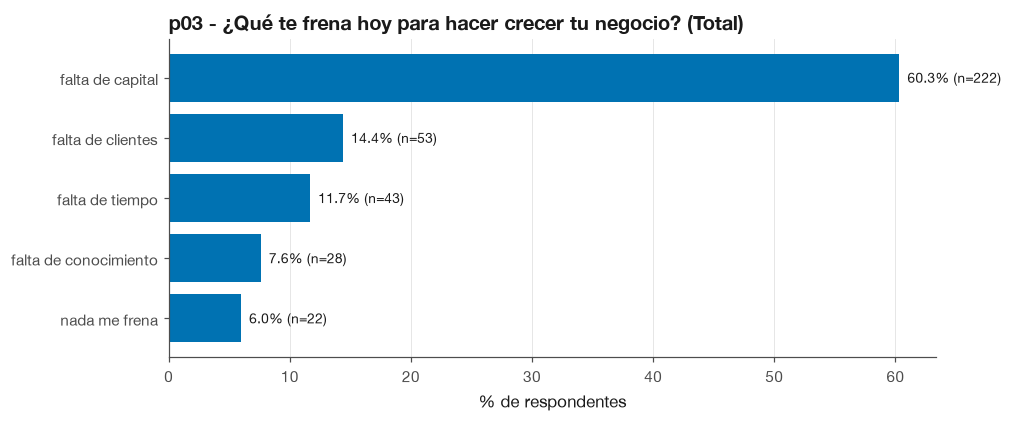

In [19]:
ax = bar_freq(dfpymes, "p03", horizontal=True)
save_fig(ax, "pymes_p03_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 9):** "falta de capital" es, por lejos, **la barrera mas
citada** (60.3%, mas del doble que la suma de las siguientes dos categorias). Le siguen "falta
de clientes" (14.4%) y "falta de tiempo" (11.7%), mientras que "falta de conocimiento" (7.6%) y
"nada me frena" (6.0%) son minoritarias. Esto es relevante para el diseño de intervenciones:
**las herramientas digitales por si solas no resuelven la barrera principal declarada** (acceso
a capital), aunque si podrian aportar a barreras secundarias como captacion de clientes o
gestion eficiente del tiempo.

### 4.4 p04 — Tiempo semanal dispuesto a aprender

In [20]:
tbl_p04 = labeled_value_counts_detailed(dfpymes, "p04")
tbl_p04

p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?   (n = 368)
------------------------------------------------------------------------
  1 a 2 horas                          106   28.8%  ##############################
  más de 4 horas                        88   23.9%  #########################
  1 hora o menos                        59   16.0%  #################
  no estoy dispuesto a dedicar tie      21    5.7%  ######
  2 a 4 horas                           94   25.5%  ###########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,1 a 2 horas,106,28.8,28.8,28.8
1,más de 4 horas,88,23.9,23.9,52.7
2,1 hora o menos,59,16.0,16.0,68.7
3,no estoy dispuesto a dedicar tiempo,21,5.7,5.7,74.4
4,2 a 4 horas,94,25.5,25.5,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p04_bar.png'

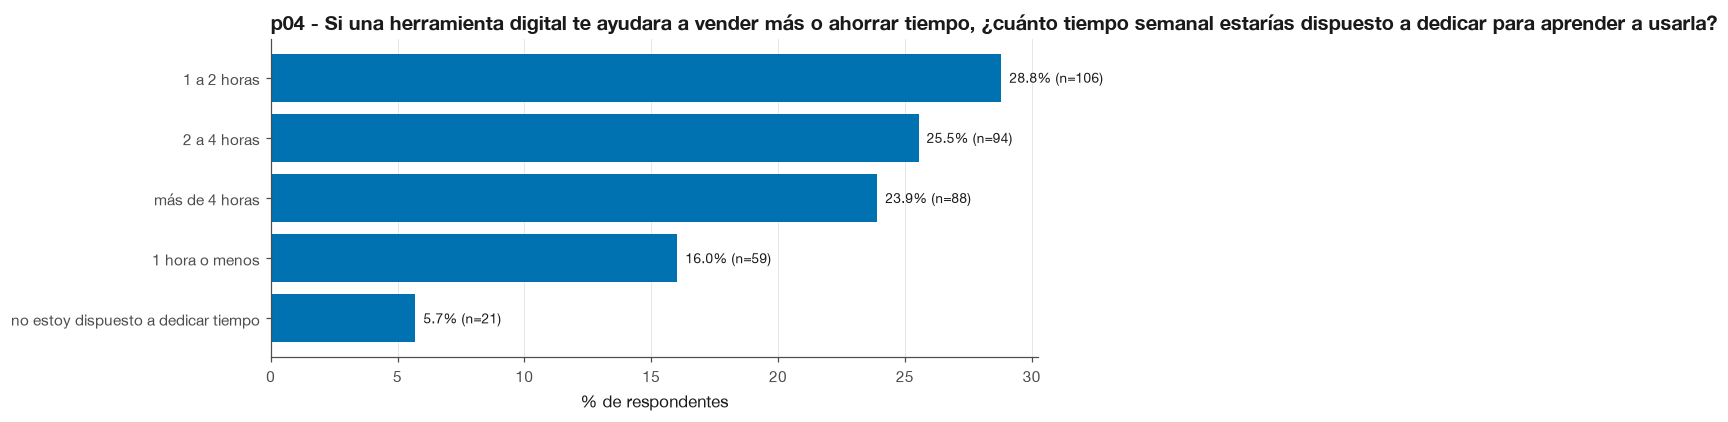

In [21]:
ax = bar_freq(dfpymes, "p04", horizontal=True)
save_fig(ax, "pymes_p04_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 10):** existe **alta disposicion a invertir tiempo en
aprender herramientas digitales**: el 94.3% de la muestra (347 de 368) esta dispuesta a
dedicar al menos algo de tiempo semanal, distribuido de forma relativamente pareja entre
"1 a 2 horas" (28.8%), "2 a 4 horas" (25.5%) y "mas de 4 horas" (23.9%). Solo el 5.7% no esta
dispuesto a dedicar tiempo. Esta es una señal favorable para el diseño de capacitaciones
digitales cortas (Step 10, Caso de uso 2): la barrera no parece ser falta de voluntad, sino
—segun el Hallazgo 9— falta de capital y de canales institucionales de apoyo (Hallazgo 8).

## Section 3: Cross-Tabulation Analysis

Esta seccion cruza las **5 variables demograficas** (`sexo`, `edad`, `niveduc`, `ocupacion`, `nse`) con las
**variables de respuesta** del negocio (`p01`, `p02`, `p03`, `p04`) para identificar asociaciones y
diferencias de patron entre segmentos. Se calculan **tablas de contingencia con porcentajes por fila**
(`crosstab_pct(..., pct='row', margins=False)`) y se visualizan como **barras apiladas al 100%**
(`stacked_bar`), guardadas en `figures/pymes/crosstabs/`.

**Nota metodologica sobre la 5ta variable de respuesta.** El diseno original contemplaba 5 variables de
respuesta (`p01`, `p02`, `p03`, `p04` + una adicional). Sin embargo, las columnas de texto libre
`p01_otro`, `p02_otro` y `p03_otro` tienen **0 de 368 respuestas validas** (100% missing) -- nadie
selecciono la opcion "otro" en estas preguntas cerradas, por lo que no son utilizables como variable de
cruce. En su lugar se construye una **variable derivada `p04_bin`** (disposicion binaria: *dispuesto* vs
*no dispuesto* a dedicar tiempo, colapsando las 4 categorias de tiempo positivo de `p04` en *dispuesto*).
Esta variable esta directamente alineada con el Caso de Uso 2 del roadmap (Paso 10: predecir disposicion a
invertir en aprendizaje digital), por lo que sienta las bases para el modelamiento del Paso 8.

**Matriz resultante:** 5 demograficas x 5 respuestas (`p01`, `p02`, `p03`, `p04`, `p04_bin`) = **25 crosstabs**.

**Notas de calidad de datos a tener presente en todo el analisis:**
- `ocupacion` tiene **3 categorias fuera del orden canonico** definido en `CATEGORY_ORDERS`
  (`alto(a) ejecutivo(a)`, `ejecutivo(a) medio(a) / profesional independiente`,
  `trabajos menores e informales`) -- aparecen como categorias finales (trailing) en vez de estar
  intercaladas en la jerarquia laboral, lo que limita la interpretacion de "orden" en esos 3 niveles.
- `nse` solo presenta **4 de las 9 categorias** del esquema (`d+e`, `c3`, `c2`, `abc1`); los niveles mas
  granulares (`e`, `d`, `c1b`, `c1a`, `ab`) no estan presentes en los datos -- el orden ascendente se
  preserva, pero con menor granularidad que la definida en el esquema.
- `niveduc` tiene **3 categorias con muestras muy pequenas** (`basica incompleta` n=1, `basica completa`
  n=4, `media incompleta` n=6); los porcentajes de fila en esas categorias son inestables y deben
  interpretarse con cautela (celdas de conteo esperado bajo para el Paso 5 de chi-cuadrado).


### 3.0 Variable derivada: `p04_bin`

Colapsa `p04` en una variable binaria de disposicion a invertir tiempo en aprender herramientas digitales, usada como 5ta variable de respuesta en la matriz de cruces.

In [22]:
import matplotlib.pyplot as plt

dfpymes['p04_bin'] = dfpymes['p04'].apply(
    lambda v: 'no dispuesto' if v == 'no estoy dispuesto a dedicar tiempo' else 'dispuesto'
)
dfpymes['p04_bin'] = pd.Categorical(
    dfpymes['p04_bin'], categories=['dispuesto', 'no dispuesto'], ordered=True
)
dfpymes = set_labels(dfpymes, {
    'p04_bin': 'p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales'
})
dfpymes['p04_bin'].value_counts(sort=False, dropna=False)

p04_bin
dispuesto       347
no dispuesto     21
Name: count, dtype: int64

### 3.1 `sexo` x variables de respuesta

Muestra: femenino n=192, masculino n=176 (practicamente equilibrada).

#### 3.1.1 `sexo` x `p01` -- Tarea que mas tiempo consume

In [23]:
ct_counts = pd.crosstab(dfpymes['sexo'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='sexo', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
sexo,,,,,
femenino,47,32,55,27,31
masculino,53,28,39,32,24


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
sexo - SEXO,,,,,
femenino,24.5,16.7,28.6,14.1,16.1
masculino,30.1,15.9,22.2,18.2,13.6


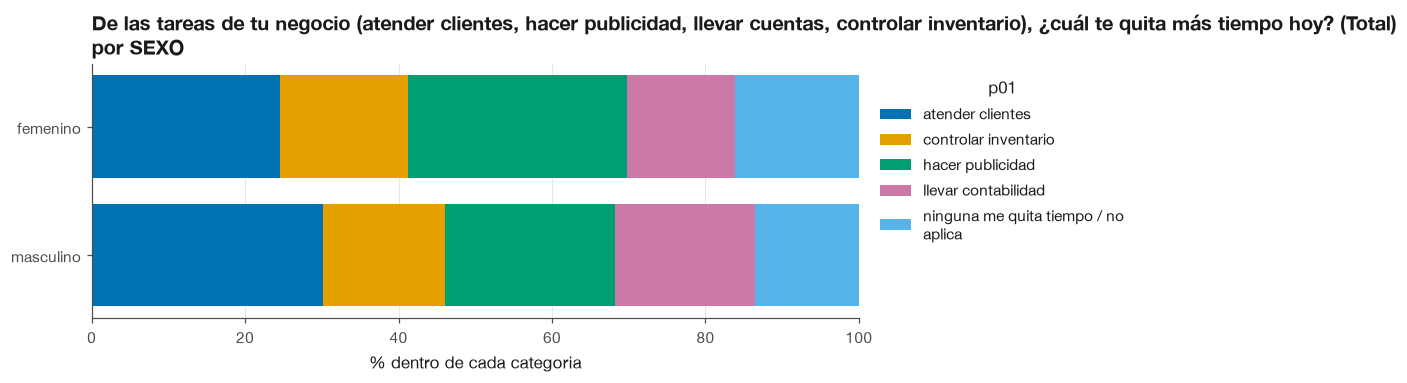

In [24]:
ax = stacked_bar(dfpymes, rows='sexo', cols='p01')
save_fig(ax, 'pymes_sexo_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (sexo x p01):**

- Las diferencias por genero en p01 son modestas (todas <6 puntos porcentuales): hombres priorizan algo mas *atender clientes* (30.1% vs 24.5% en mujeres), mientras mujeres citan mas *hacer publicidad* (28.6% vs 22.2%).
- *Llevar contabilidad* es levemente mas reportado por hombres (18.2% vs 14.1%), pero en general el patron de tareas que consumen tiempo es muy similar entre generos.
- Conclusion: el sexo no parece ser un predictor fuerte de p01; las brechas observadas son de magnitud pequena y probablemente dentro del margen de variacion muestral (a confirmar con chi-cuadrado en el Paso 5).

#### 3.1.2 `sexo` x `p02` -- Principal fuente de ayuda

In [25]:
ct_counts = pd.crosstab(dfpymes['sexo'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='sexo', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
sexo,,,,,
femenino,104,21,38,7,22
masculino,85,26,40,9,16


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
sexo - SEXO,,,,,
femenino,54.2,10.9,19.8,3.6,11.5
masculino,48.3,14.8,22.7,5.1,9.1


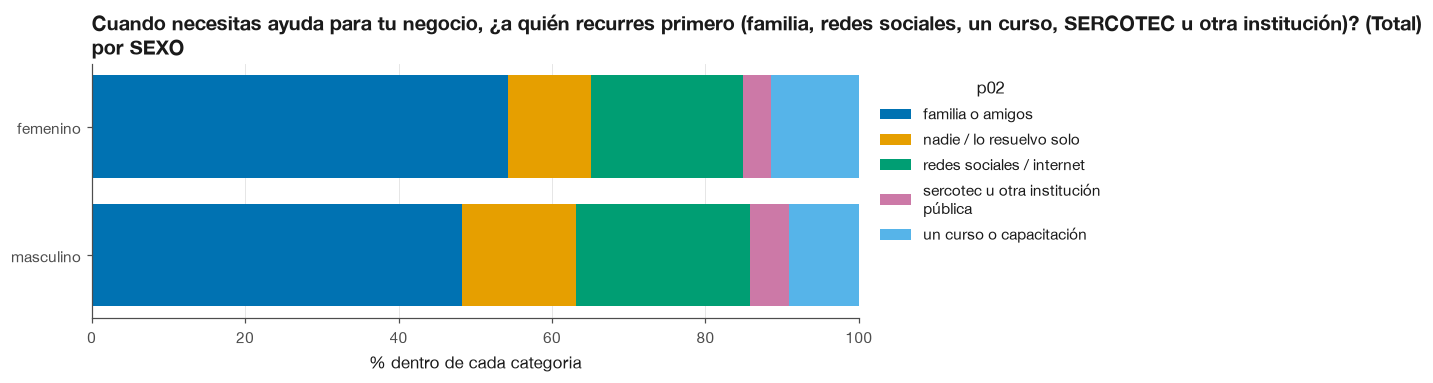

In [26]:
ax = stacked_bar(dfpymes, rows='sexo', cols='p02')
save_fig(ax, 'pymes_sexo_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (sexo x p02):**

- *Familia o amigos* domina en ambos generos, pero mas entre mujeres (54.2% vs 48.3% en hombres), sugiriendo una leve mayor dependencia de redes informales.
- Los hombres reportan algo mas *nadie / lo resuelvo solo* (14.8% vs 10.9%) y *redes sociales/internet* (22.7% vs 19.8%), consistente con un patron levemente mas autonomo/digital.
- El uso de SERCOTEC u otra institucion publica es bajo en ambos grupos (3.6% mujeres, 5.1% hombres) -- la brecha de genero en el uso de apoyo institucional es pequena pero desfavorece a las mujeres.

#### 3.1.3 `sexo` x `p03` -- Barreras para crecer

In [27]:
ct_counts = pd.crosstab(dfpymes['sexo'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='sexo', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
sexo,,,,,
femenino,118,26,16,21,11
masculino,104,27,12,22,11


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
sexo - SEXO,,,,,
femenino,61.5,13.5,8.3,10.9,5.7
masculino,59.1,15.3,6.8,12.5,6.2


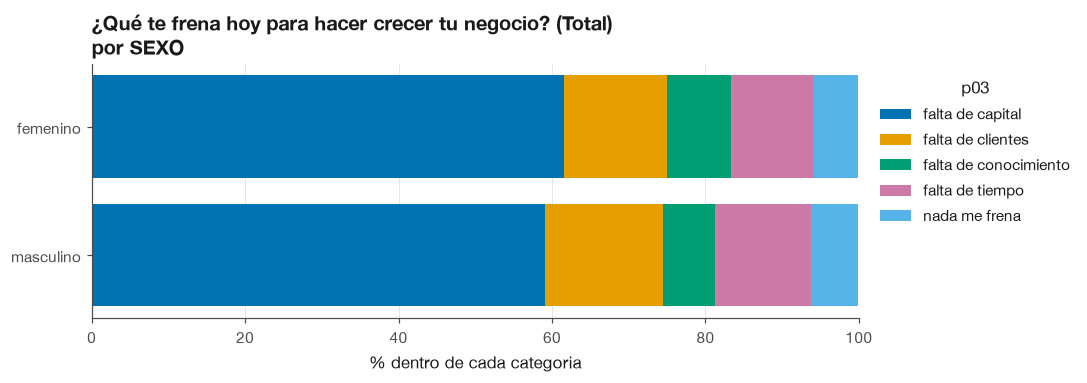

In [28]:
ax = stacked_bar(dfpymes, rows='sexo', cols='p03')
save_fig(ax, 'pymes_sexo_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (sexo x p03):**

- *Falta de capital* es la barrera dominante y practicamente identica entre generos (61.5% mujeres vs 59.1% hombres), indicando que el acceso a capital es un problema transversal, no diferenciado por sexo.
- El resto de las barreras (clientes, conocimiento, tiempo, nada) tambien muestran diferencias menores a 2 puntos porcentuales entre generos.
- Dato de calidad: la ausencia de brechas de genero en p03 sugiere que las politicas de apoyo a PyMEs no necesitan segmentarse por sexo en esta dimension especifica.

#### 3.1.4 `sexo` x `p04` -- Tiempo semanal dispuesto a aprender

In [29]:
ct_counts = pd.crosstab(dfpymes['sexo'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='sexo', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
sexo,,,,,
femenino,59,33,46,44,10
masculino,47,26,48,44,11


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
sexo - SEXO,,,,,
femenino,30.7,17.2,24.0,22.9,5.2
masculino,26.7,14.8,27.3,25.0,6.2


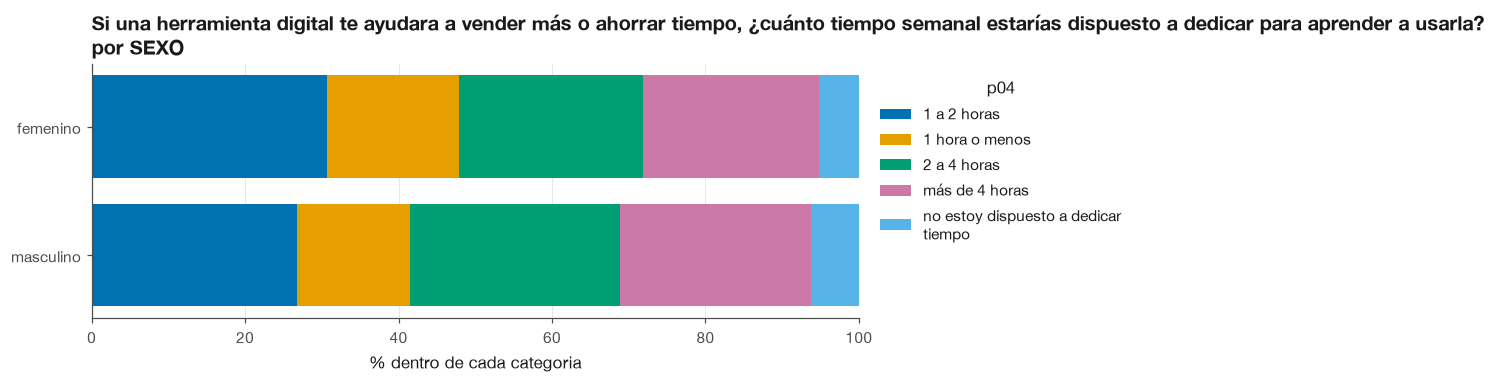

In [30]:
ax = stacked_bar(dfpymes, rows='sexo', cols='p04')
save_fig(ax, 'pymes_sexo_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (sexo x p04):**

- La distribucion de tiempo dispuesto a dedicar es similar entre generos; mujeres se concentran algo mas en *1 a 2 horas* (30.7% vs 26.7%) y hombres en *2 a 4 horas* (27.3% vs 24.0%).
- La opcion *mas de 4 horas* es casi identica (22.9% mujeres, 25.0% hombres), y la resistencia total (*no estoy dispuesto*) es baja en ambos grupos (5.2% vs 6.2%).
- En conjunto, el genero no discrimina fuertemente cuanto tiempo semanal se esta dispuesto a invertir en aprender herramientas digitales.

#### 3.1.5 `sexo` x `p04_bin` -- Disposicion a aprender (binario: dispuesto / no dispuesto)

In [31]:
ct_counts = pd.crosstab(dfpymes['sexo'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='sexo', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
sexo,,
femenino,182,10
masculino,165,11


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
sexo - SEXO,,
femenino,94.8,5.2
masculino,93.8,6.2


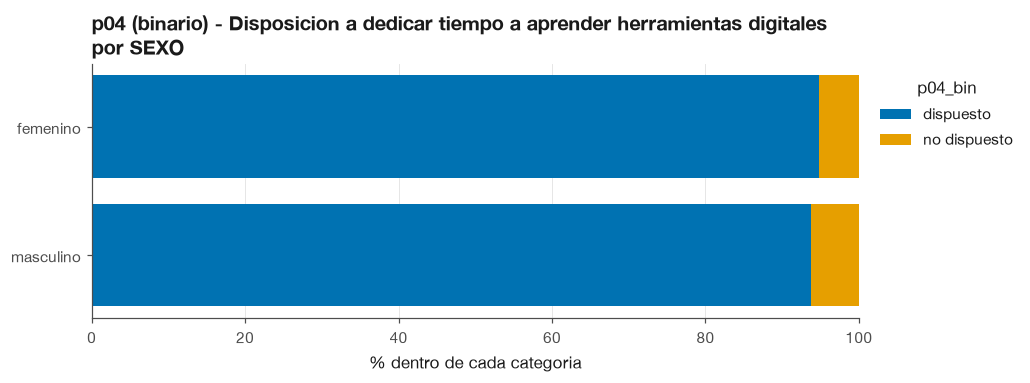

In [32]:
ax = stacked_bar(dfpymes, rows='sexo', cols='p04_bin')
save_fig(ax, 'pymes_sexo_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (sexo x p04_bin):**

- La version binaria confirma lo anterior: 94.8% de mujeres y 93.8% de hombres se declaran *dispuestos* a dedicar algo de tiempo -- una diferencia de apenas 1 punto porcentual.
- La disposicion general a aprender herramientas digitales es muy alta (>93%) en ambos generos, por lo que el genero no seria un criterio util para segmentar campanas de capacitacion basadas solo en la disposicion binaria.

### 3.2 `edad` x variables de respuesta

Muestra por tramo: [18-30] n=55, [31-40] n=75, [41-50] n=86, [51-60] n=79, [61+] n=73.

#### 3.2.1 `edad` x `p01` -- Tarea que mas tiempo consume

In [33]:
ct_counts = pd.crosstab(dfpymes['edad'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='edad', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
edad,,,,,
[18-30],15,11,17,6,6
[31-40],20,8,28,15,4
[41-50],19,18,26,12,11
[51-60],18,12,16,15,18
[61+],28,11,7,11,16


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
edad - RANGO ETARIO,,,,,
[18-30],27.3,20.0,30.9,10.9,10.9
[31-40],26.7,10.7,37.3,20.0,5.3
[41-50],22.1,20.9,30.2,14.0,12.8
[51-60],22.8,15.2,20.3,19.0,22.8
[61+],38.4,15.1,9.6,15.1,21.9


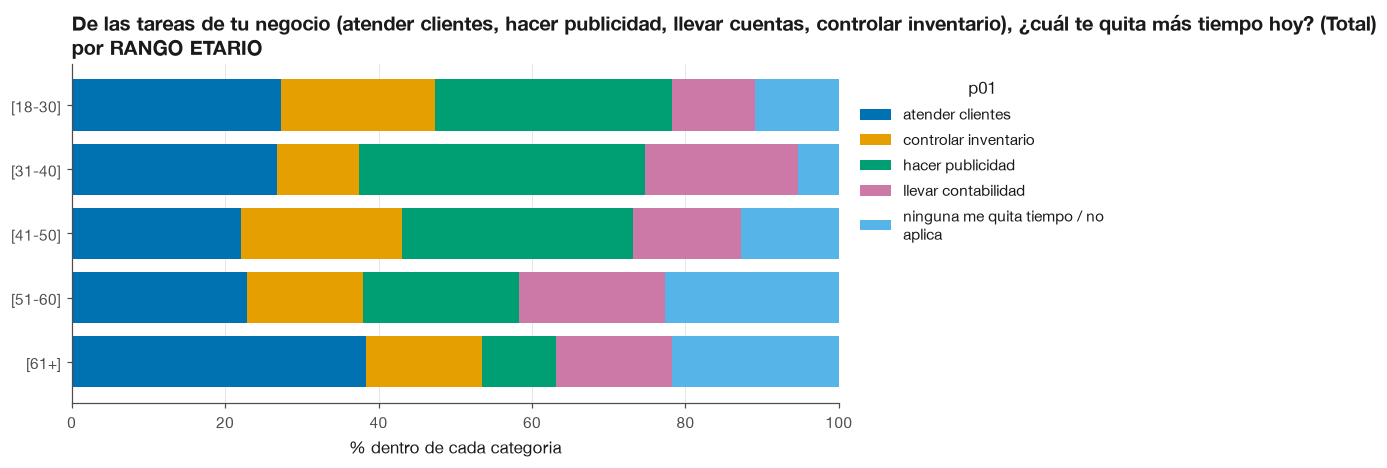

In [34]:
ax = stacked_bar(dfpymes, rows='edad', cols='p01')
save_fig(ax, 'pymes_edad_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (edad x p01):**

- *Atender clientes* se dispara al 38.4% en el tramo 61+ (vs 22-30% en los demas tramos), mostrando que los duenos de mayor edad son los mas absorbidos por la atencion directa a clientes.
- *Hacer publicidad* cae de forma casi monotona con la edad: 30.9% (18-30) -> 37.3% (31-40) -> 30.2% (41-50) -> 20.3% (51-60) -> 9.6% (61+), evidenciando que el marketing es un dolor mucho mas relevante para duenos jovenes y de mediana edad que para los mayores.
- *Ninguna me quita tiempo* crece con la edad (10.9% en 18-30 a 21.9% en 61+), consistente con negocios de menor intensidad operativa entre los duenos de mayor edad.

#### 3.2.2 `edad` x `p02` -- Principal fuente de ayuda

In [35]:
ct_counts = pd.crosstab(dfpymes['edad'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='edad', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
edad,,,,,
[18-30],29,7,15,0,4
[31-40],40,7,18,3,7
[41-50],45,9,15,6,11
[51-60],35,10,18,4,12
[61+],40,14,12,3,4


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
edad - RANGO ETARIO,,,,,
[18-30],52.7,12.7,27.3,0.0,7.3
[31-40],53.3,9.3,24.0,4.0,9.3
[41-50],52.3,10.5,17.4,7.0,12.8
[51-60],44.3,12.7,22.8,5.1,15.2
[61+],54.8,19.2,16.4,4.1,5.5


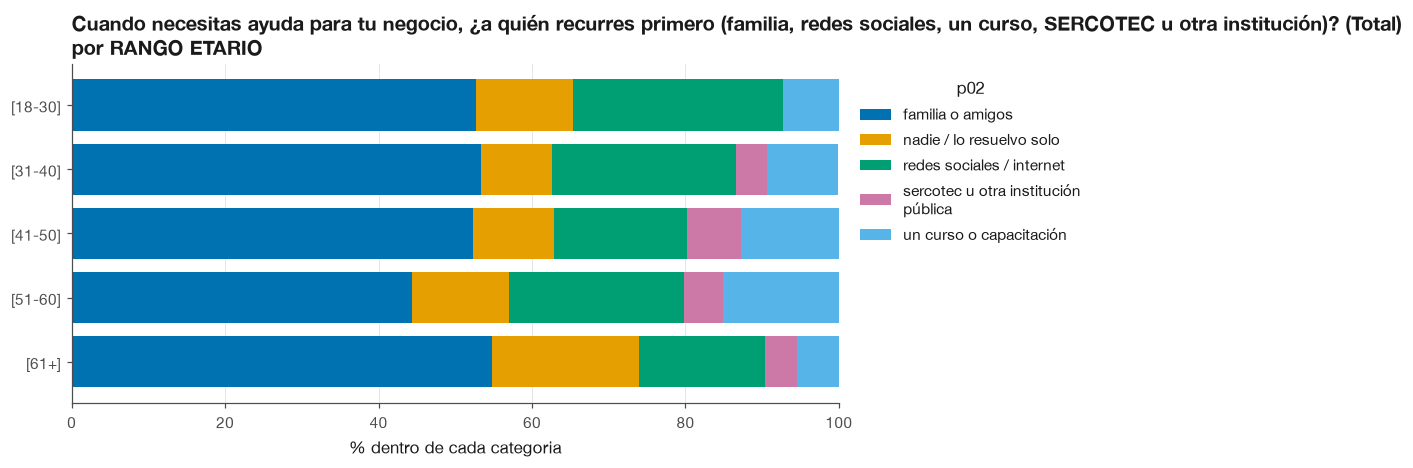

In [36]:
ax = stacked_bar(dfpymes, rows='edad', cols='p02')
save_fig(ax, 'pymes_edad_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (edad x p02):**

- El uso de *redes sociales/internet* como fuente de ayuda decae con la edad: 27.3% (18-30) a 16.4% (61+), reflejando una brecha digital etaria clara en la busqueda de apoyo.
- El uso de *SERCOTEC u otra institucion publica* es 0.0% en el tramo 18-30 y sube a 7.0% en 41-50, sugiriendo que el conocimiento/acceso a programas publicos se construye con la trayectoria del negocio y no esta disponible desde el inicio.
- *Familia o amigos* se mantiene como la fuente dominante en todos los tramos (44-55%), sin una tendencia etaria clara -- es el canal de ayuda mas resiliente independientemente de la edad.

#### 3.2.3 `edad` x `p03` -- Barreras para crecer

In [37]:
ct_counts = pd.crosstab(dfpymes['edad'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='edad', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
edad,,,,,
[18-30],22,14,6,10,3
[31-40],49,9,6,9,2
[41-50],59,10,5,7,5
[51-60],54,6,5,11,3
[61+],38,14,6,6,9


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
edad - RANGO ETARIO,,,,,
[18-30],40.0,25.5,10.9,18.2,5.5
[31-40],65.3,12.0,8.0,12.0,2.7
[41-50],68.6,11.6,5.8,8.1,5.8
[51-60],68.4,7.6,6.3,13.9,3.8
[61+],52.1,19.2,8.2,8.2,12.3


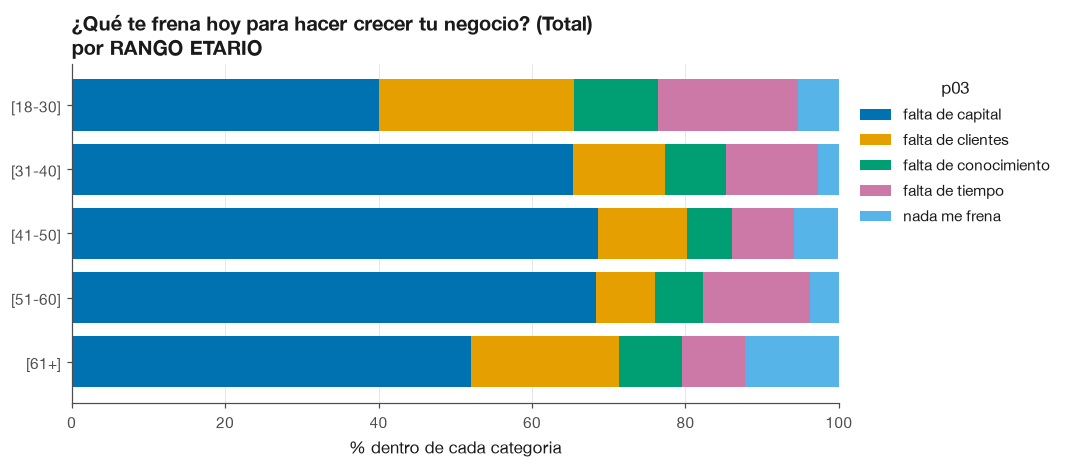

In [38]:
ax = stacked_bar(dfpymes, rows='edad', cols='p03')
save_fig(ax, 'pymes_edad_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (edad x p03):**

- *Falta de capital* muestra un patron en forma de U invertida: minimo en 18-30 (40.0%), maximo en 41-50 y 51-60 (~68%), y cae a 52.1% en 61+ -- el problema de capital golpea con mas fuerza a los duenos en edad laboral central.
- *Falta de clientes* tiene el patron opuesto (forma de U): alto en 18-30 (25.5%) y en 61+ (19.2%), bajo en los tramos intermedios (7.6-12.0%) -- los negocios mas nuevos/jovenes y los de duenos mayores enfrentan mas dificultad para atraer clientes, posiblemente por redes de contacto menos consolidadas o en declive.
- *Nada me frena* es mas frecuente en 61+ (12.3%) que en el resto (2.7-5.8%), sugiriendo que una parte de los duenos mayores gestiona negocios de menor ambicion de crecimiento.

#### 3.2.4 `edad` x `p04` -- Tiempo semanal dispuesto a aprender

In [39]:
ct_counts = pd.crosstab(dfpymes['edad'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='edad', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
edad,,,,,
[18-30],12,11,13,14,5
[31-40],23,13,16,20,3
[41-50],20,9,28,26,3
[51-60],21,13,23,18,4
[61+],30,13,14,10,6


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
edad - RANGO ETARIO,,,,,
[18-30],21.8,20.0,23.6,25.5,9.1
[31-40],30.7,17.3,21.3,26.7,4.0
[41-50],23.3,10.5,32.6,30.2,3.5
[51-60],26.6,16.5,29.1,22.8,5.1
[61+],41.1,17.8,19.2,13.7,8.2


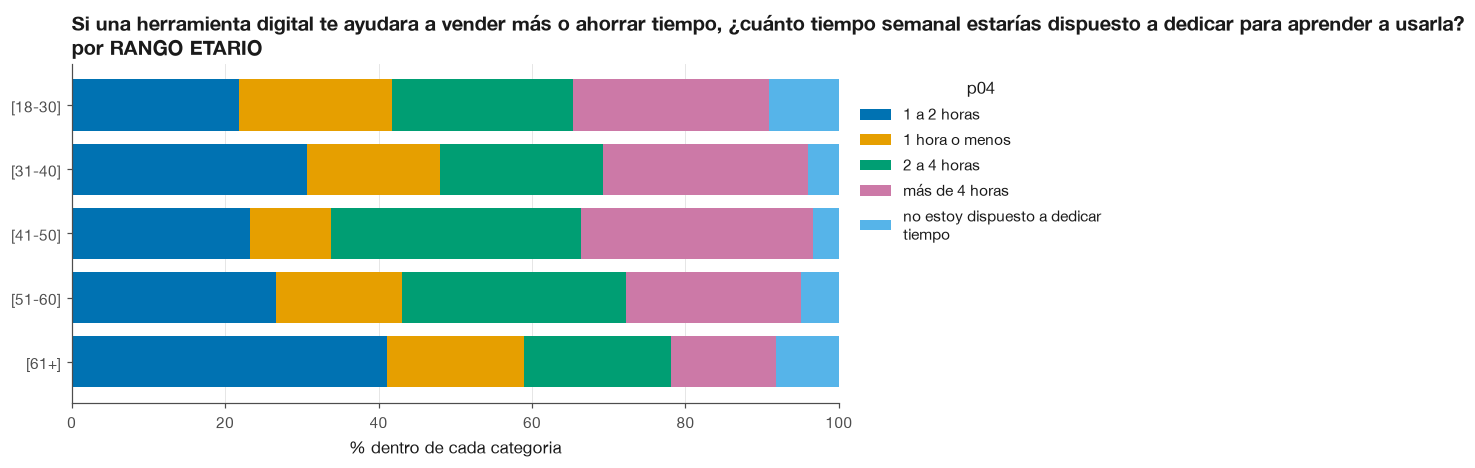

In [40]:
ax = stacked_bar(dfpymes, rows='edad', cols='p04')
save_fig(ax, 'pymes_edad_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (edad x p04):**

- La disposicion a *mas de 4 horas* cae con la edad: 30.2% en 41-50 hasta 13.7% en 61+, el minimo de toda la tabla.
- En cambio, *1 a 2 horas* se dispara en el tramo 61+ (41.1%, el valor mas alto de toda la fila), lo que indica que los duenos mayores siguen dispuestos a aprender pero prefieren compromisos de tiempo mas acotados.
- La resistencia total (*no estoy dispuesto*) es mayor en los extremos etarios (9.1% en 18-30 y 8.2% en 61+) que en el centro (3.5-5.1% en 31-60), formando nuevamente un patron en U.

#### 3.2.5 `edad` x `p04_bin` -- Disposicion a aprender (binario: dispuesto / no dispuesto)

In [41]:
ct_counts = pd.crosstab(dfpymes['edad'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='edad', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
edad,,
[18-30],50,5
[31-40],72,3
[41-50],83,3
[51-60],75,4
[61+],67,6


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
edad - RANGO ETARIO,,
[18-30],90.9,9.1
[31-40],96.0,4.0
[41-50],96.5,3.5
[51-60],94.9,5.1
[61+],91.8,8.2


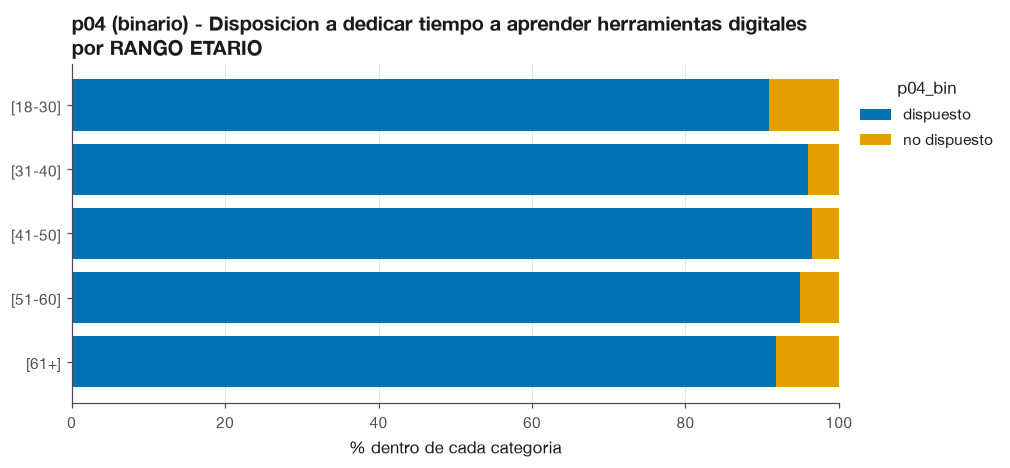

In [42]:
ax = stacked_bar(dfpymes, rows='edad', cols='p04_bin')
save_fig(ax, 'pymes_edad_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (edad x p04_bin):**

- La disposicion binaria (dispuesto) va de 90.9% (18-30) a 96.5% (41-50), con los tramos centrales (31-50) mostrando la mayor disposicion y los extremos (18-30 y 61+) la menor -- aunque incluso el minimo (90.9%) sigue siendo alto en terminos absolutos.
- Este patron en U leve refuerza la senal de p04 detallado: la intensidad de tiempo dispuesto varia mas por edad que la disposicion binaria en si misma.

### 3.3 `niveduc` x variables de respuesta

Muestra por nivel: basica incompleta n=1, basica completa n=4, media incompleta n=6, media completa n=97, tecnica superior incompleta n=41, tecnica superior completa n=79, universitaria incompleta n=47, universitaria completa n=83, postgrado n=10. Las tres primeras categorias tienen muestra insuficiente para interpretacion robusta.

#### 3.3.1 `niveduc` x `p01` -- Tarea que mas tiempo consume

In [43]:
ct_counts = pd.crosstab(dfpymes['niveduc'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='niveduc', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
niveduc,,,,,
basica incompleta,1,0,0,0,0
basica completa,1,0,1,0,2
media incompleta,0,0,3,1,2
media completa,24,18,20,18,17
tecnica superior incompleta,13,5,9,8,6
tecnica superior completa,24,16,18,12,9
universitaria incompleta,13,6,16,8,4
universitaria completa,20,15,24,12,12
postgrado,4,0,3,0,3


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
niveduc - ¿NIVEL EDUCACIONAL?,,,,,
basica incompleta,100.0,0.0,0.0,0.0,0.0
basica completa,25.0,0.0,25.0,0.0,50.0
media incompleta,0.0,0.0,50.0,16.7,33.3
media completa,24.7,18.6,20.6,18.6,17.5
tecnica superior incompleta,31.7,12.2,22.0,19.5,14.6
tecnica superior completa,30.4,20.3,22.8,15.2,11.4
universitaria incompleta,27.7,12.8,34.0,17.0,8.5
universitaria completa,24.1,18.1,28.9,14.5,14.5
postgrado,40.0,0.0,30.0,0.0,30.0


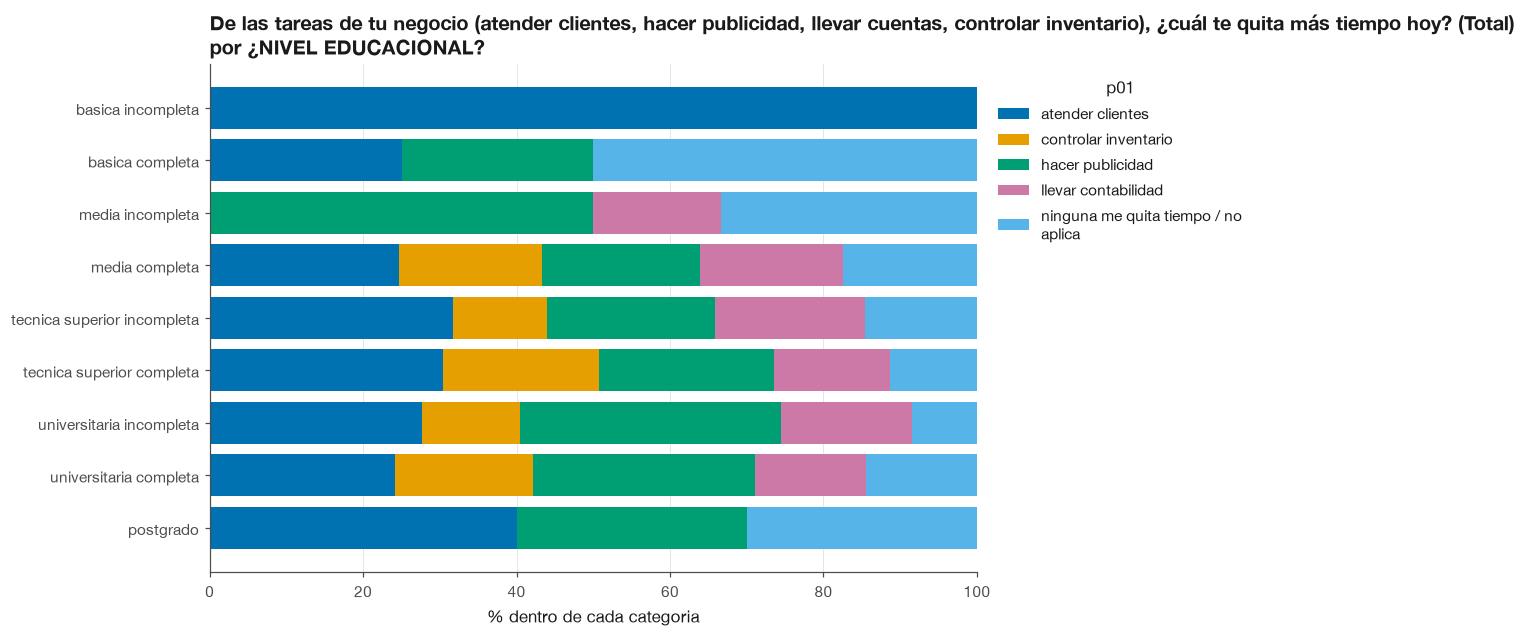

In [44]:
ax = stacked_bar(dfpymes, rows='niveduc', cols='p01')
save_fig(ax, 'pymes_niveduc_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (niveduc x p01):**

- Alerta de calidad de datos: las categorias *basica incompleta* (n=1), *basica completa* (n=4) y *media incompleta* (n=6) tienen muestras demasiado pequenas para interpretar sus porcentajes (ej. 100%/50%/33%) con confianza; el analisis se enfoca en las categorias con n>=41.
- Entre las categorias bien pobladas, *atender clientes* varia poco (24.1%-31.7%) y *ninguna me quita tiempo* decrece de 17.5% (media completa) a 8.5% (universitaria incompleta, el minimo) para luego subir a 14.5% (universitaria completa) -- un patron no monotono, sin gradiente educativo claro.
- En conjunto, la educacion formal no parece ser un predictor fuerte de cual tarea consume mas tiempo dentro del negocio.

#### 3.3.2 `niveduc` x `p02` -- Principal fuente de ayuda

In [45]:
ct_counts = pd.crosstab(dfpymes['niveduc'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='niveduc', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
niveduc,,,,,
basica incompleta,1,0,0,0,0
basica completa,1,2,0,0,1
media incompleta,4,2,0,0,0
media completa,59,7,22,1,8
tecnica superior incompleta,21,7,6,3,4
tecnica superior completa,34,11,19,5,10
universitaria incompleta,24,10,7,1,5
universitaria completa,39,7,23,5,9
postgrado,6,1,1,1,1


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
niveduc - ¿NIVEL EDUCACIONAL?,,,,,
basica incompleta,100.0,0.0,0.0,0.0,0.0
basica completa,25.0,50.0,0.0,0.0,25.0
media incompleta,66.7,33.3,0.0,0.0,0.0
media completa,60.8,7.2,22.7,1.0,8.2
tecnica superior incompleta,51.2,17.1,14.6,7.3,9.8
tecnica superior completa,43.0,13.9,24.1,6.3,12.7
universitaria incompleta,51.1,21.3,14.9,2.1,10.6
universitaria completa,47.0,8.4,27.7,6.0,10.8
postgrado,60.0,10.0,10.0,10.0,10.0


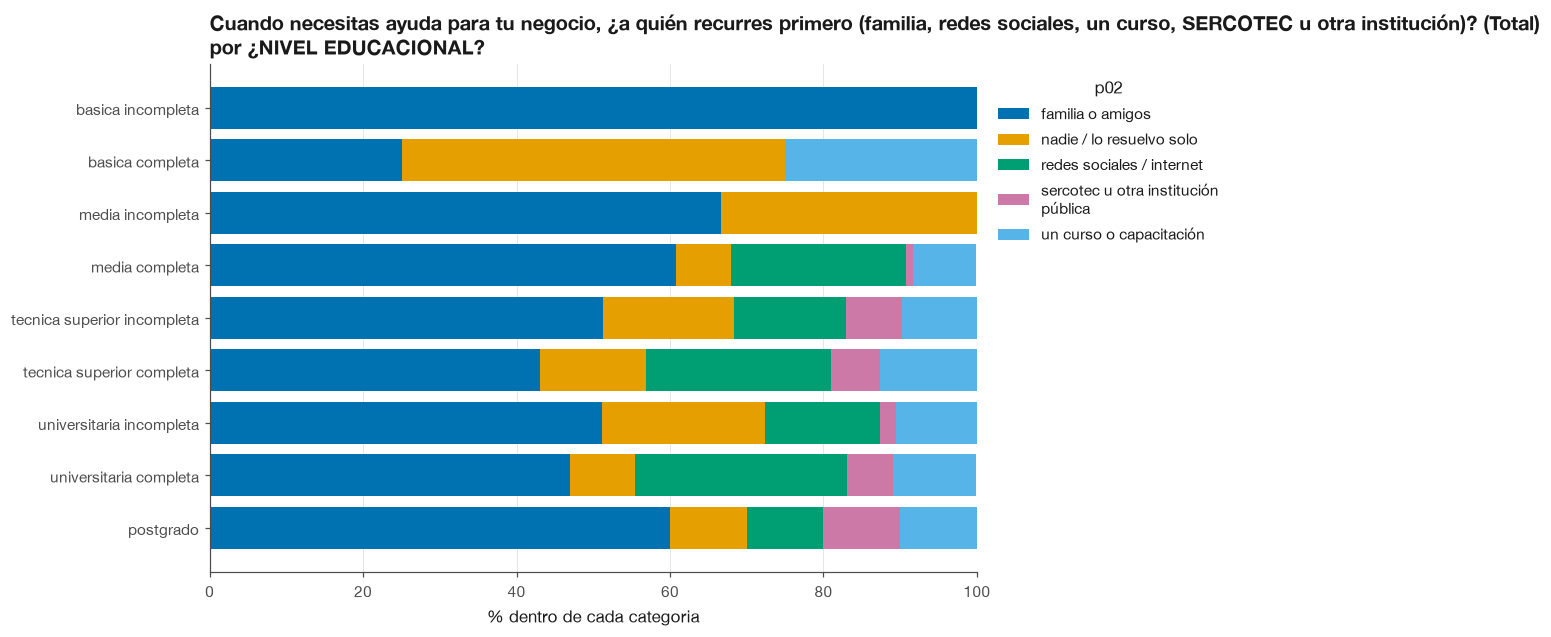

In [46]:
ax = stacked_bar(dfpymes, rows='niveduc', cols='p02')
save_fig(ax, 'pymes_niveduc_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (niveduc x p02):**

- *Familia o amigos* decrece con la educacion entre los grupos grandes: 60.8% (media completa) a 43.0% (tecnica superior completa) y 47.0% (universitaria completa) -- los duenos con menor escolaridad dependen mas de redes informales.
- *Redes sociales/internet* es mas usada por los grupos con mayor educacion formal: 22.7% (media completa) sube hasta 27.7% (universitaria completa), aunque tecnica superior incompleta rompe la tendencia con solo 14.6%.
- El uso de *SERCOTEC u otra institucion publica* es minimo en media completa (1.0%) y notablemente mayor en los grupos tecnicos/universitarios (6-7%), senalando una posible brecha de acceso a programas publicos para el segmento de menor escolaridad formal.

#### 3.3.3 `niveduc` x `p03` -- Barreras para crecer

In [47]:
ct_counts = pd.crosstab(dfpymes['niveduc'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='niveduc', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
niveduc,,,,,
basica incompleta,1,0,0,0,0
basica completa,2,1,0,0,1
media incompleta,3,0,0,3,0
media completa,62,10,9,10,6
tecnica superior incompleta,25,5,4,5,2
tecnica superior completa,54,9,4,7,5
universitaria incompleta,24,10,5,6,2
universitaria completa,45,16,6,10,6
postgrado,6,2,0,2,0


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
niveduc - ¿NIVEL EDUCACIONAL?,,,,,
basica incompleta,100.0,0.0,0.0,0.0,0.0
basica completa,50.0,25.0,0.0,0.0,25.0
media incompleta,50.0,0.0,0.0,50.0,0.0
media completa,63.9,10.3,9.3,10.3,6.2
tecnica superior incompleta,61.0,12.2,9.8,12.2,4.9
tecnica superior completa,68.4,11.4,5.1,8.9,6.3
universitaria incompleta,51.1,21.3,10.6,12.8,4.3
universitaria completa,54.2,19.3,7.2,12.0,7.2
postgrado,60.0,20.0,0.0,20.0,0.0


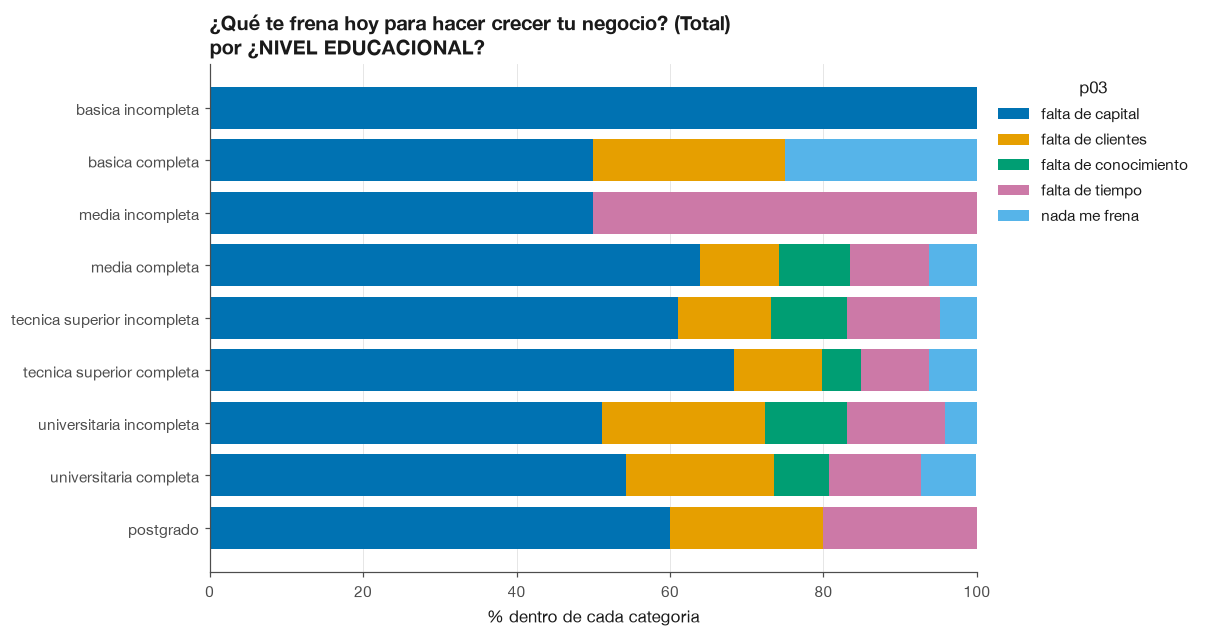

In [48]:
ax = stacked_bar(dfpymes, rows='niveduc', cols='p03')
save_fig(ax, 'pymes_niveduc_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (niveduc x p03):**

- *Falta de capital* es mas alta entre tecnica superior completa (68.4%) y media completa (63.9%), y algo menor entre universitaria incompleta (51.1%) y universitaria completa (54.2%), sugiriendo mejor acceso a financiamiento en los niveles universitarios.
- *Falta de clientes* sube con la educacion: 10.3% (media completa) a 21.3% (universitaria incompleta, el maximo entre grupos grandes) y 19.3% (universitaria completa) -- duenos mas educados, con menos restriccion de capital, enfrentan mas el desafio de captar clientes.
- Esto sugiere que las necesidades de apoyo difieren por nivel educativo: financiamiento para los grupos de escolaridad media/tecnica, y estrategias de captacion de clientes para los grupos universitarios.

#### 3.3.4 `niveduc` x `p04` -- Tiempo semanal dispuesto a aprender

In [49]:
ct_counts = pd.crosstab(dfpymes['niveduc'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='niveduc', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
niveduc,,,,,
basica incompleta,0,0,1,0,0
basica completa,1,0,0,1,2
media incompleta,2,1,3,0,0
media completa,33,19,20,21,4
tecnica superior incompleta,12,8,10,10,1
tecnica superior completa,23,13,23,15,5
universitaria incompleta,13,8,13,12,1
universitaria completa,18,8,22,28,7
postgrado,4,2,2,1,1


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
niveduc - ¿NIVEL EDUCACIONAL?,,,,,
basica incompleta,0.0,0.0,100.0,0.0,0.0
basica completa,25.0,0.0,0.0,25.0,50.0
media incompleta,33.3,16.7,50.0,0.0,0.0
media completa,34.0,19.6,20.6,21.6,4.1
tecnica superior incompleta,29.3,19.5,24.4,24.4,2.4
tecnica superior completa,29.1,16.5,29.1,19.0,6.3
universitaria incompleta,27.7,17.0,27.7,25.5,2.1
universitaria completa,21.7,9.6,26.5,33.7,8.4
postgrado,40.0,20.0,20.0,10.0,10.0


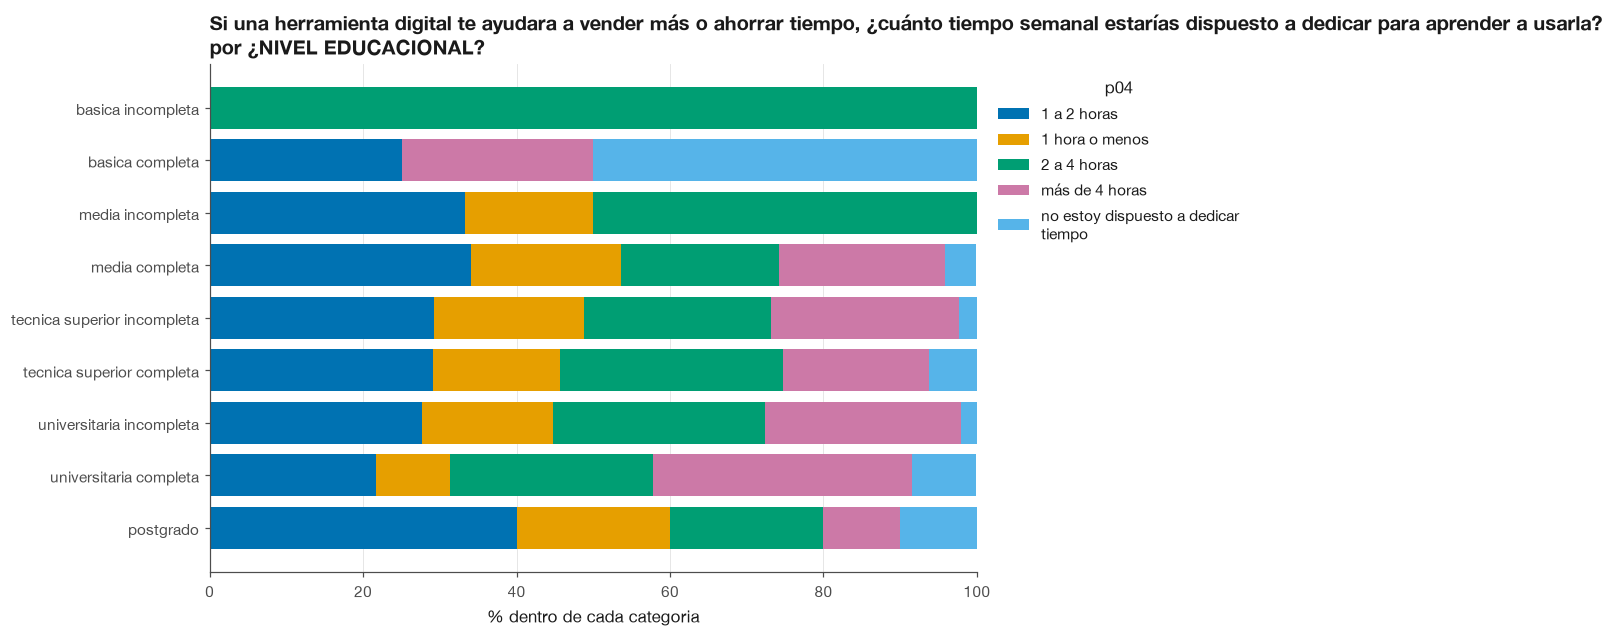

In [50]:
ax = stacked_bar(dfpymes, rows='niveduc', cols='p04')
save_fig(ax, 'pymes_niveduc_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (niveduc x p04):**

- La disposicion a *mas de 4 horas* aumenta con la educacion entre los grupos grandes: 21.6% (media completa) a 33.7% (universitaria completa, el maximo) pasando por 19.0% (tecnica superior completa) y 25.5% (universitaria incompleta).
- Sin embargo, universitaria completa tambien muestra la mayor tasa de *no estoy dispuesto* entre los grupos grandes (8.4% vs 4.1% en media completa), lo que indica un patron polarizado: mas entusiastas de alto compromiso, pero tambien mas rechazo total, en vez de un desplazamiento uniforme hacia mayor disposicion.
- Esta polarizacion en el grupo universitario completo es relevante para el diseno de intervenciones de capacitacion (Paso 8/10): un enfoque unico de 'una talla para todos' podria no funcionar bien en este segmento.

#### 3.3.5 `niveduc` x `p04_bin` -- Disposicion a aprender (binario: dispuesto / no dispuesto)

In [51]:
ct_counts = pd.crosstab(dfpymes['niveduc'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='niveduc', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
niveduc,,
basica incompleta,1,0
basica completa,2,2
media incompleta,6,0
media completa,93,4
tecnica superior incompleta,40,1
tecnica superior completa,74,5
universitaria incompleta,46,1
universitaria completa,76,7
postgrado,9,1


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
niveduc - ¿NIVEL EDUCACIONAL?,,
basica incompleta,100.0,0.0
basica completa,50.0,50.0
media incompleta,100.0,0.0
media completa,95.9,4.1
tecnica superior incompleta,97.6,2.4
tecnica superior completa,93.7,6.3
universitaria incompleta,97.9,2.1
universitaria completa,91.6,8.4
postgrado,90.0,10.0


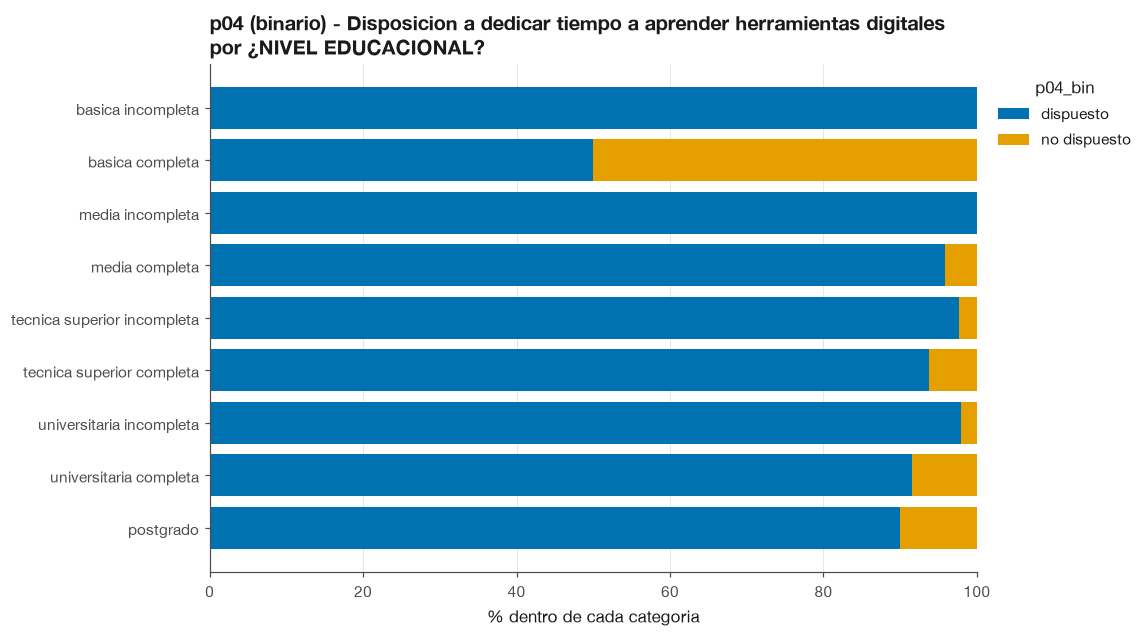

In [52]:
ax = stacked_bar(dfpymes, rows='niveduc', cols='p04_bin')
save_fig(ax, 'pymes_niveduc_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (niveduc x p04_bin):**

- La disposicion binaria oscila entre 90-98% en los grupos grandes, sin una relacion lineal clara con la educacion: universitaria incompleta tiene la mayor disposicion (97.9%) y universitaria completa la menor entre los grupos grandes (91.6%).
- Esto confirma que la educacion formal se relaciona mas con *cuanto* tiempo se esta dispuesto a invertir (ver p04) que con la disposicion basica a participar, la cual es alta en todos los niveles educativos.

### 3.4 `ocupacion` x variables de respuesta

Muestra por ocupacion: cesante n=25, estudiante n=21, dueño(a) de casa n=32, jubilado(a) n=36, oficio menor n=20, oficio calificado n=31, empleado(a) administrativo(a)/tecnico n=77, alto(a) ejecutivo(a) n=13, ejecutivo(a) medio(a)/profesional independiente n=54, trabajos menores e informales n=59. Las ultimas 3 categorias estan fuera del orden canonico.

#### 3.4.1 `ocupacion` x `p01` -- Tarea que mas tiempo consume

In [53]:
ct_counts = pd.crosstab(dfpymes['ocupacion'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='ocupacion', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
ocupacion,,,,,
cesante,3,5,10,3,4
estudiante,4,3,8,5,1
dueño(a) de casa,5,5,9,6,7
jubilado(a),7,4,6,8,11
oficio menor,7,3,3,3,4
oficio calificado,13,7,5,3,3
empleado(a) administrativo(a) / tecnico,20,13,19,14,11
alto(a) ejecutivo(a),3,1,5,0,4
ejecutivo(a) medio(a) / profesional independiente,20,4,19,8,3


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
ocupacion - ¿TIPO DE TRABAJO?,,,,,
cesante,12.0,20.0,40.0,12.0,16.0
estudiante,19.0,14.3,38.1,23.8,4.8
dueño(a) de casa,15.6,15.6,28.1,18.8,21.9
jubilado(a),19.4,11.1,16.7,22.2,30.6
oficio menor,35.0,15.0,15.0,15.0,20.0
oficio calificado,41.9,22.6,16.1,9.7,9.7
empleado(a) administrativo(a) / tecnico,26.0,16.9,24.7,18.2,14.3
alto(a) ejecutivo(a),23.1,7.7,38.5,0.0,30.8
ejecutivo(a) medio(a) / profesional independiente,37.0,7.4,35.2,14.8,5.6


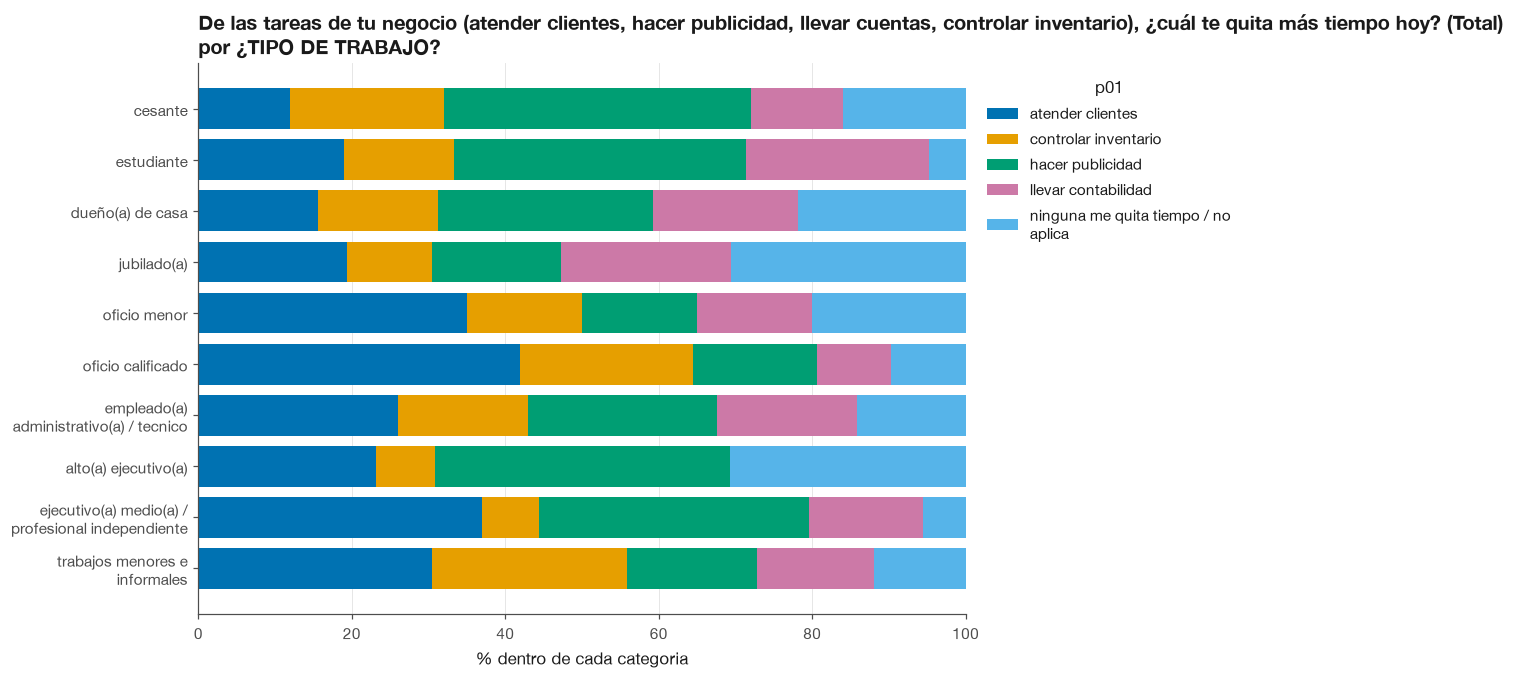

In [54]:
ax = stacked_bar(dfpymes, rows='ocupacion', cols='p01')
save_fig(ax, 'pymes_ocupacion_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (ocupacion x p01):**

- *Atender clientes* es maximo en oficio calificado (41.9%) y ejecutivo(a) medio(a)/profesional independiente (37.0%), y minimo en cesante (12.0%) -- ocupaciones con trato directo y regular con clientes concentran mas esta carga.
- *Hacer publicidad* es el problema dominante para cesante (40.0%), alto(a) ejecutivo(a) (38.5%) y estudiante (38.1%), pero es marginal para oficio menor y oficio calificado (~15-16%), que probablemente dependen mas del boca a boca que de marketing activo.
- *Ninguna me quita tiempo* es mas alta entre jubilado(a) (30.6%) y alto(a) ejecutivo(a) (30.8%, n=13), sugiriendo negocios de menor intensidad o complementarios a otra fuente de ingresos/pension en estos segmentos.

#### 3.4.2 `ocupacion` x `p02` -- Principal fuente de ayuda

In [55]:
ct_counts = pd.crosstab(dfpymes['ocupacion'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='ocupacion', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
ocupacion,,,,,
cesante,13,2,8,0,2
estudiante,9,4,5,0,3
dueño(a) de casa,19,3,4,2,4
jubilado(a),23,6,6,1,0
oficio menor,7,4,6,1,2
oficio calificado,17,3,7,2,2
empleado(a) administrativo(a) / tecnico,34,12,17,5,9
alto(a) ejecutivo(a),4,2,3,2,2
ejecutivo(a) medio(a) / profesional independiente,26,6,14,2,6


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
ocupacion - ¿TIPO DE TRABAJO?,,,,,
cesante,52.0,8.0,32.0,0.0,8.0
estudiante,42.9,19.0,23.8,0.0,14.3
dueño(a) de casa,59.4,9.4,12.5,6.2,12.5
jubilado(a),63.9,16.7,16.7,2.8,0.0
oficio menor,35.0,20.0,30.0,5.0,10.0
oficio calificado,54.8,9.7,22.6,6.5,6.5
empleado(a) administrativo(a) / tecnico,44.2,15.6,22.1,6.5,11.7
alto(a) ejecutivo(a),30.8,15.4,23.1,15.4,15.4
ejecutivo(a) medio(a) / profesional independiente,48.1,11.1,25.9,3.7,11.1


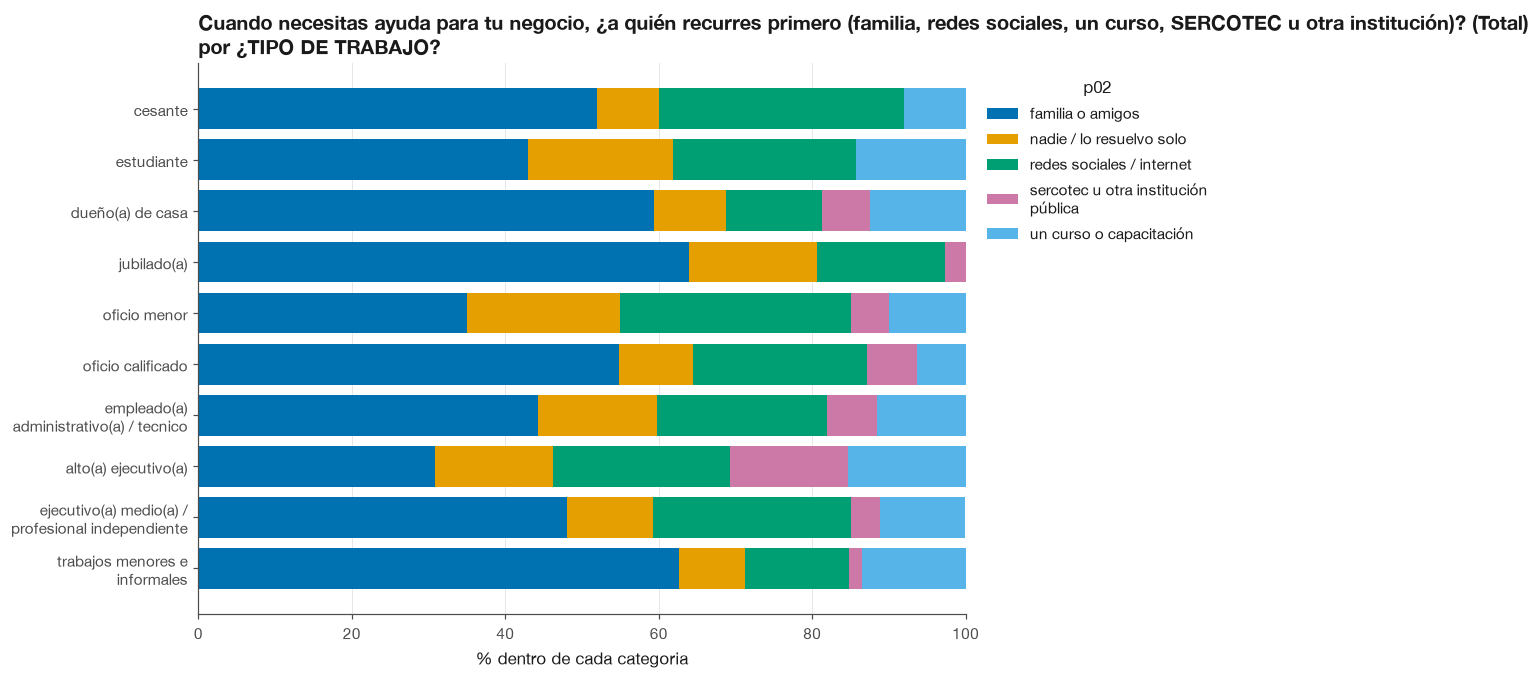

In [56]:
ax = stacked_bar(dfpymes, rows='ocupacion', cols='p02')
save_fig(ax, 'pymes_ocupacion_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (ocupacion x p02):**

- *Familia o amigos* es maxima en jubilado(a) (63.9%) y trabajos menores e informales (62.7%), y minima en alto(a) ejecutivo(a) (30.8%) -- los segmentos de menor jerarquia laboral dependen mucho mas de redes familiares para resolver problemas del negocio.
- El uso de *SERCOTEC u otra institucion publica* es 0.0% para cesante y estudiante, pero 15.4% para alto(a) ejecutivo(a) -- una brecha de acceso institucional que penaliza justamente a los segmentos mas vulnerables (desempleados, estudiantes-emprendedores).
- *Redes sociales/internet* es mas usada por cesante (32.0%) y oficio menor (30.0%) que por dueño(a) de casa (12.5%), mostrando heterogeneidad digital entre ocupaciones de perfil similar en jerarquia laboral.

#### 3.4.3 `ocupacion` x `p03` -- Barreras para crecer

In [57]:
ct_counts = pd.crosstab(dfpymes['ocupacion'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='ocupacion', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
ocupacion,,,,,
cesante,14,7,1,2,1
estudiante,10,4,1,4,2
dueño(a) de casa,23,2,2,3,2
jubilado(a),19,8,3,1,5
oficio menor,12,1,5,2,0
oficio calificado,18,5,2,4,2
empleado(a) administrativo(a) / tecnico,47,9,6,13,2
alto(a) ejecutivo(a),8,1,1,2,1
ejecutivo(a) medio(a) / profesional independiente,32,12,2,5,3


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
ocupacion - ¿TIPO DE TRABAJO?,,,,,
cesante,56.0,28.0,4.0,8.0,4.0
estudiante,47.6,19.0,4.8,19.0,9.5
dueño(a) de casa,71.9,6.2,6.2,9.4,6.2
jubilado(a),52.8,22.2,8.3,2.8,13.9
oficio menor,60.0,5.0,25.0,10.0,0.0
oficio calificado,58.1,16.1,6.5,12.9,6.5
empleado(a) administrativo(a) / tecnico,61.0,11.7,7.8,16.9,2.6
alto(a) ejecutivo(a),61.5,7.7,7.7,15.4,7.7
ejecutivo(a) medio(a) / profesional independiente,59.3,22.2,3.7,9.3,5.6


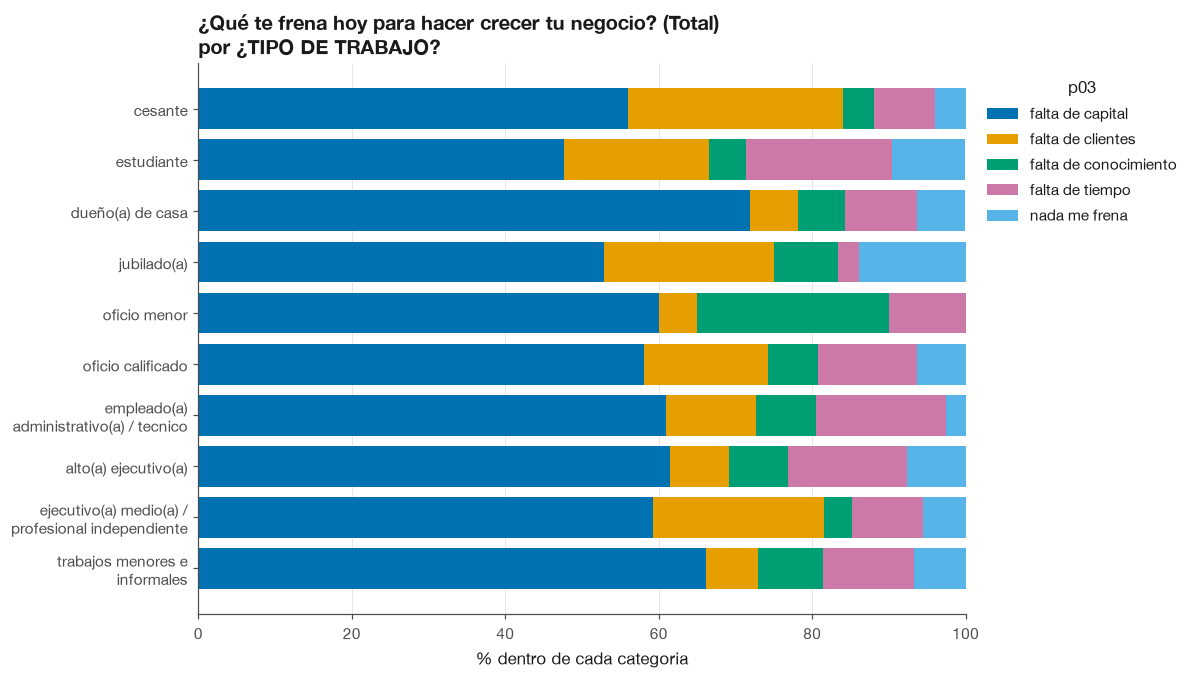

In [58]:
ax = stacked_bar(dfpymes, rows='ocupacion', cols='p03')
save_fig(ax, 'pymes_ocupacion_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (ocupacion x p03):**

- *Falta de capital* es maxima en dueño(a) de casa (71.9%) y trabajos menores e informales (66.1%), y minima en estudiante (47.6%) -- las ocupaciones de menor formalidad laboral enfrentan la restriccion de capital con mayor intensidad.
- *Falta de clientes* es maxima en cesante (28.0%) y compartida por ejecutivo(a) medio(a) y jubilado(a) (22.2% cada uno), y minima en dueño(a) de casa (6.2%) y oficio menor (5.0%) -- perfiles con negocios mas locales/de barrio (hogar, oficios) parecen tener una cartera de clientes mas estable.
- *Falta de conocimiento* se dispara en oficio menor (25.0%, n=20) frente a 4-8% en el resto de las ocupaciones -- este segmento destaca como prioritario para programas de alfabetizacion digital/de gestion.

#### 3.4.4 `ocupacion` x `p04` -- Tiempo semanal dispuesto a aprender

In [59]:
ct_counts = pd.crosstab(dfpymes['ocupacion'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='ocupacion', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
ocupacion,,,,,
cesante,10,4,4,6,1
estudiante,5,3,4,8,1
dueño(a) de casa,5,9,12,4,2
jubilado(a),15,7,6,5,3
oficio menor,7,2,8,2,1
oficio calificado,11,5,7,5,3
empleado(a) administrativo(a) / tecnico,21,9,25,19,3
alto(a) ejecutivo(a),3,1,2,5,2
ejecutivo(a) medio(a) / profesional independiente,17,7,13,16,1


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
ocupacion - ¿TIPO DE TRABAJO?,,,,,
cesante,40.0,16.0,16.0,24.0,4.0
estudiante,23.8,14.3,19.0,38.1,4.8
dueño(a) de casa,15.6,28.1,37.5,12.5,6.2
jubilado(a),41.7,19.4,16.7,13.9,8.3
oficio menor,35.0,10.0,40.0,10.0,5.0
oficio calificado,35.5,16.1,22.6,16.1,9.7
empleado(a) administrativo(a) / tecnico,27.3,11.7,32.5,24.7,3.9
alto(a) ejecutivo(a),23.1,7.7,15.4,38.5,15.4
ejecutivo(a) medio(a) / profesional independiente,31.5,13.0,24.1,29.6,1.9


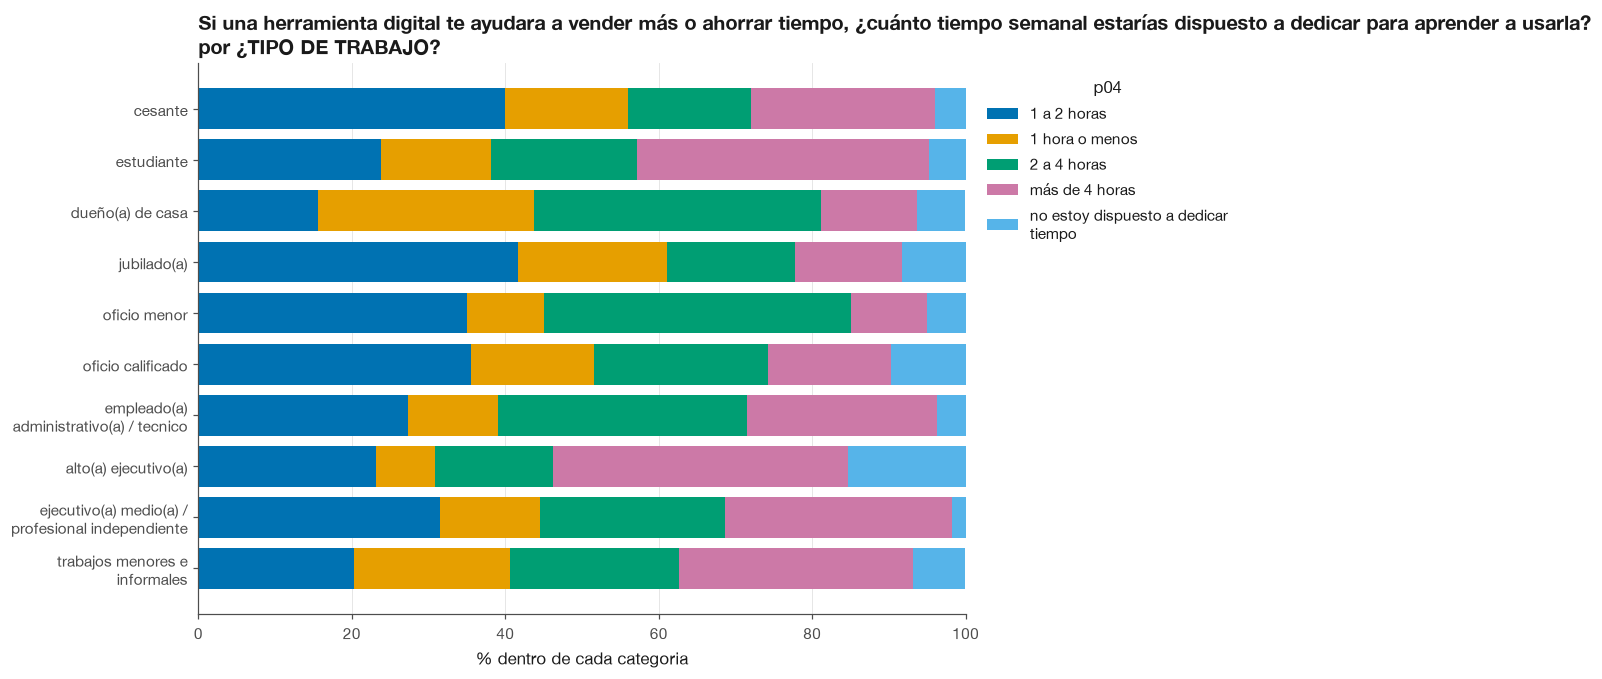

In [60]:
ax = stacked_bar(dfpymes, rows='ocupacion', cols='p04')
save_fig(ax, 'pymes_ocupacion_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (ocupacion x p04):**

- *No estoy dispuesto* es maximo en alto(a) ejecutivo(a) (15.4%, n=13) y minimo en ejecutivo(a) medio(a)/profesional independiente (1.9%) -- contraintuitivamente, el segmento de mayor jerarquia muestra mas resistencia a invertir tiempo, posiblemente por escasez de tiempo o por ya usar herramientas digitales.
- *Mas de 4 horas* es maxima en alto(a) ejecutivo(a) y estudiante (38.5% y 38.1% respectivamente) y minima en oficio menor (10.0%) y dueño(a) de casa (12.5%), que se concentran mas en *1 hora o menos*/*2 a 4 horas*.
- Esta combinacion (alto ejecutivo con alta resistencia pero tambien alta disposicion a mucho tiempo cuando esta dispuesto) sugiere una segmentacion bimodal dentro de esa categoria, coherente con su tamano muestral pequeno (n=13) y posible heterogeneidad interna.

#### 3.4.5 `ocupacion` x `p04_bin` -- Disposicion a aprender (binario: dispuesto / no dispuesto)

In [61]:
ct_counts = pd.crosstab(dfpymes['ocupacion'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='ocupacion', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
ocupacion,,
cesante,24,1
estudiante,20,1
dueño(a) de casa,30,2
jubilado(a),33,3
oficio menor,19,1
oficio calificado,28,3
empleado(a) administrativo(a) / tecnico,74,3
alto(a) ejecutivo(a),11,2
ejecutivo(a) medio(a) / profesional independiente,53,1


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
ocupacion - ¿TIPO DE TRABAJO?,,
cesante,96.0,4.0
estudiante,95.2,4.8
dueño(a) de casa,93.8,6.2
jubilado(a),91.7,8.3
oficio menor,95.0,5.0
oficio calificado,90.3,9.7
empleado(a) administrativo(a) / tecnico,96.1,3.9
alto(a) ejecutivo(a),84.6,15.4
ejecutivo(a) medio(a) / profesional independiente,98.1,1.9


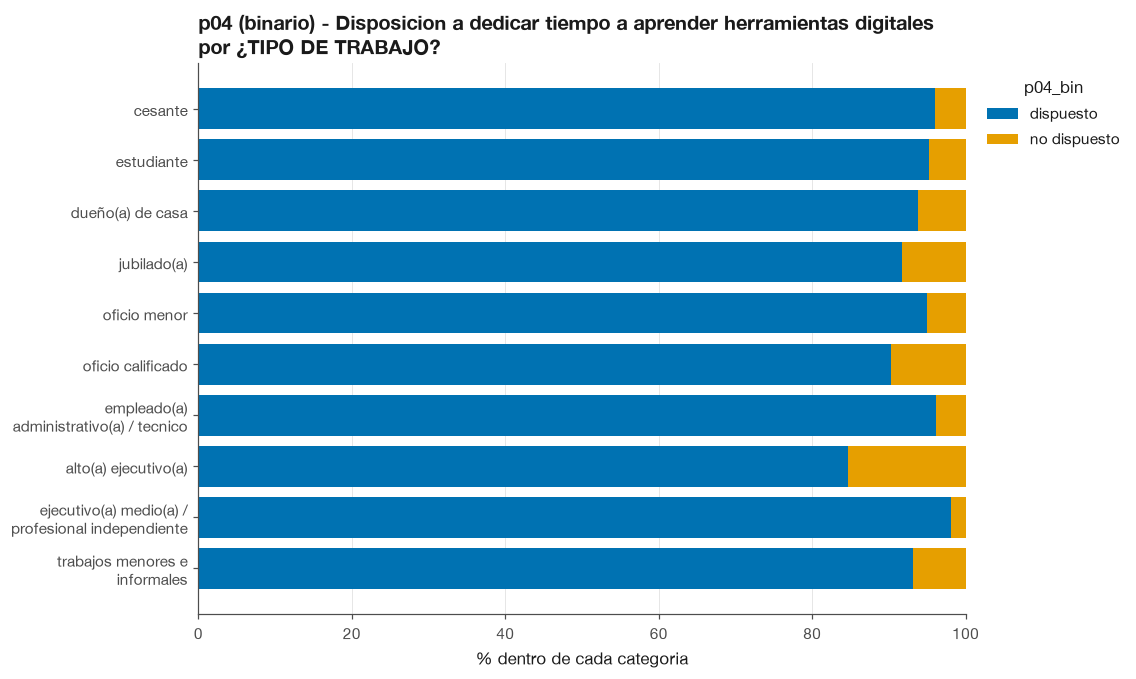

In [62]:
ax = stacked_bar(dfpymes, rows='ocupacion', cols='p04_bin')
save_fig(ax, 'pymes_ocupacion_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (ocupacion x p04_bin):**

- Ejecutivo(a) medio(a)/profesional independiente tiene la mayor disposicion binaria (98.1%) y alto(a) ejecutivo(a) la menor (84.6%, n=13) -- una brecha de 13.5 puntos porcentuales, la mayor de todo el cruce ocupacion x p04_bin.
- El resto de las ocupaciones se mueve en un rango mas estrecho (90.3%-96.1%), por lo que alto(a) ejecutivo(a) es un valor atipico que amerita revision de tamano muestral antes de usarlo en el modelamiento del Paso 8.

### 3.5 `nse` x variables de respuesta

Muestra por grupo: d+e n=66, c3 n=122, c2 n=131, abc1 n=49 (solo 4 de 9 niveles del esquema).

#### 3.5.1 `nse` x `p01` -- Tarea que mas tiempo consume

In [63]:
ct_counts = pd.crosstab(dfpymes['nse'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='nse', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
nse,,,,,
d+e,19,10,14,10,13
c3,28,25,28,20,21
c2,36,21,36,23,15
abc1,17,4,16,6,6


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
nse - GRUPO NSE,,,,,
d+e,28.8,15.2,21.2,15.2,19.7
c3,23.0,20.5,23.0,16.4,17.2
c2,27.5,16.0,27.5,17.6,11.5
abc1,34.7,8.2,32.7,12.2,12.2


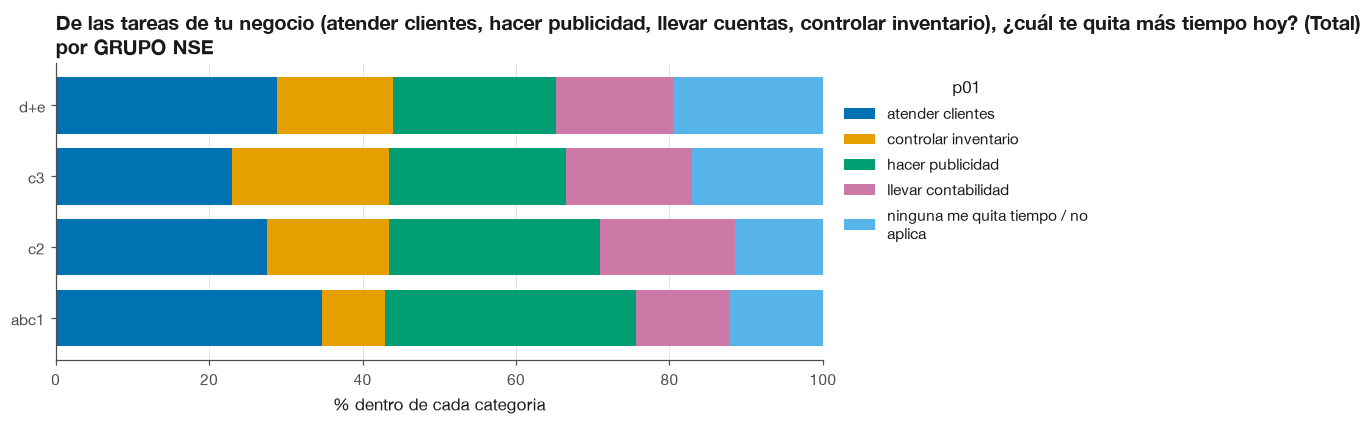

In [64]:
ax = stacked_bar(dfpymes, rows='nse', cols='p01')
save_fig(ax, 'pymes_nse_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (nse x p01):**

- *Atender clientes* aumenta con el NSE: 28.8% (d+e) a 34.7% (abc1, el maximo), sugiriendo negocios de mayor NSE con mas interaccion directa con clientes.
- *Controlar inventario* decrece con el NSE: 15.2%-20.5% en los grupos bajo/medio a solo 8.2% en abc1 -- los negocios de menor NSE tienden a girar mas en torno a comercio/retail con gestion de inventario.
- *Ninguna me quita tiempo* decrece casi monotonamente con el NSE (19.7% en d+e a 12.2% en abc1), indicando negocios de mayor NSE con operaciones mas intensivas en todas las tareas.

#### 3.5.2 `nse` x `p02` -- Principal fuente de ayuda

In [65]:
ct_counts = pd.crosstab(dfpymes['nse'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='nse', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
nse,,,,,
d+e,45,7,10,0,4
c3,57,18,30,5,12
c2,66,15,24,8,18
abc1,21,7,14,3,4


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
nse - GRUPO NSE,,,,,
d+e,68.2,10.6,15.2,0.0,6.1
c3,46.7,14.8,24.6,4.1,9.8
c2,50.4,11.5,18.3,6.1,13.7
abc1,42.9,14.3,28.6,6.1,8.2


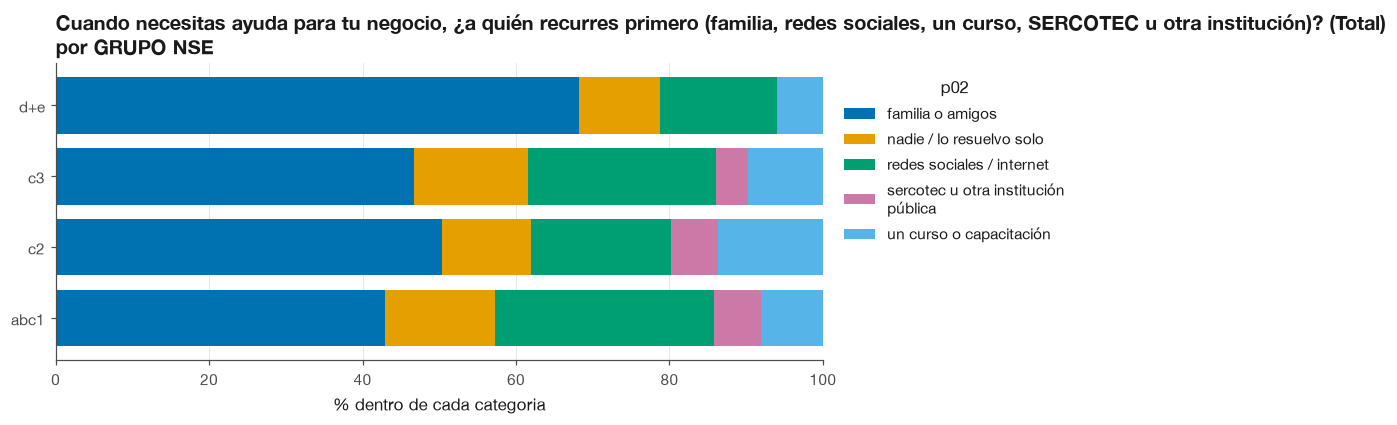

In [66]:
ax = stacked_bar(dfpymes, rows='nse', cols='p02')
save_fig(ax, 'pymes_nse_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (nse x p02):**

- *Familia o amigos* cae fuertemente con el NSE: 68.2% (d+e) a 42.9% (abc1) -- un gradiente socioeconomico claro en la dependencia de redes informales.
- *Redes sociales/internet* practicamente se duplica del grupo mas bajo al mas alto: 15.2% (d+e) a 28.6% (abc1), evidenciando una brecha digital asociada al nivel socioeconomico.
- *SERCOTEC u otra institucion publica* es 0.0% en d+e (el segmento que mas necesitaria este apoyo) y 4-6% en el resto de los grupos -- una brecha de acceso institucional preocupante para el segmento mas vulnerable.

#### 3.5.3 `nse` x `p03` -- Barreras para crecer

In [67]:
ct_counts = pd.crosstab(dfpymes['nse'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='nse', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
nse,,,,,
d+e,45,7,3,8,3
c3,71,16,12,11,12
c2,79,20,11,17,4
abc1,27,10,2,7,3


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
nse - GRUPO NSE,,,,,
d+e,68.2,10.6,4.5,12.1,4.5
c3,58.2,13.1,9.8,9.0,9.8
c2,60.3,15.3,8.4,13.0,3.1
abc1,55.1,20.4,4.1,14.3,6.1


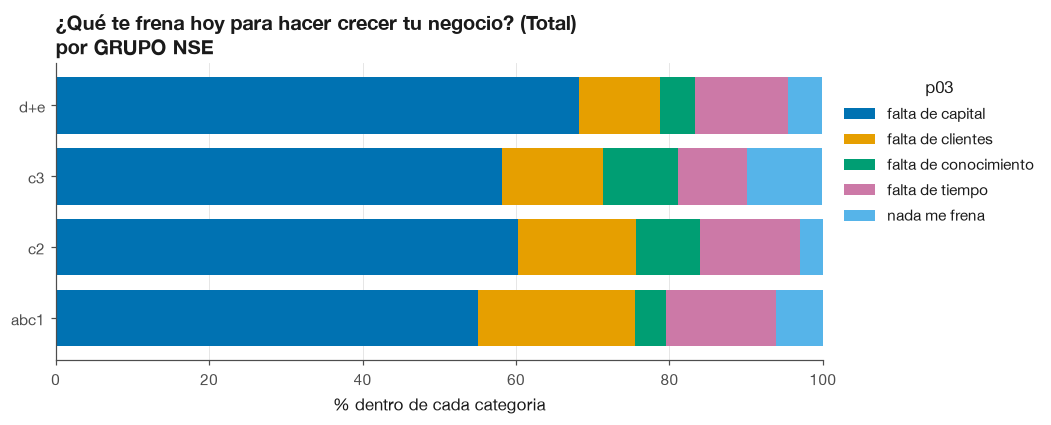

In [68]:
ax = stacked_bar(dfpymes, rows='nse', cols='p03')
save_fig(ax, 'pymes_nse_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (nse x p03):**

- *Falta de capital* muestra un gradiente socioeconomico claro y monotono: 68.2% (d+e) a 55.1% (abc1) -- el acceso a capital es, como es esperable, un problema mas agudo cuanto menor es el NSE.
- *Falta de clientes* tiene el patron inverso: 10.6% (d+e) a 20.4% (abc1, el maximo) -- a mayor NSE, el capital deja de ser el cuello de botella principal y la captacion de clientes gana relevancia relativa.
- Esto sugiere una hoja de ruta de politica publica diferenciada por NSE: financiamiento/capital para los segmentos d+e y c3, y apoyo en marketing/captacion de clientes para c2 y abc1.

#### 3.5.4 `nse` x `p04` -- Tiempo semanal dispuesto a aprender

In [69]:
ct_counts = pd.crosstab(dfpymes['nse'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='nse', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
nse,,,,,
d+e,18,16,11,17,4
c3,37,18,33,25,9
c2,34,22,40,30,5
abc1,17,3,10,16,3


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
nse - GRUPO NSE,,,,,
d+e,27.3,24.2,16.7,25.8,6.1
c3,30.3,14.8,27.0,20.5,7.4
c2,26.0,16.8,30.5,22.9,3.8
abc1,34.7,6.1,20.4,32.7,6.1


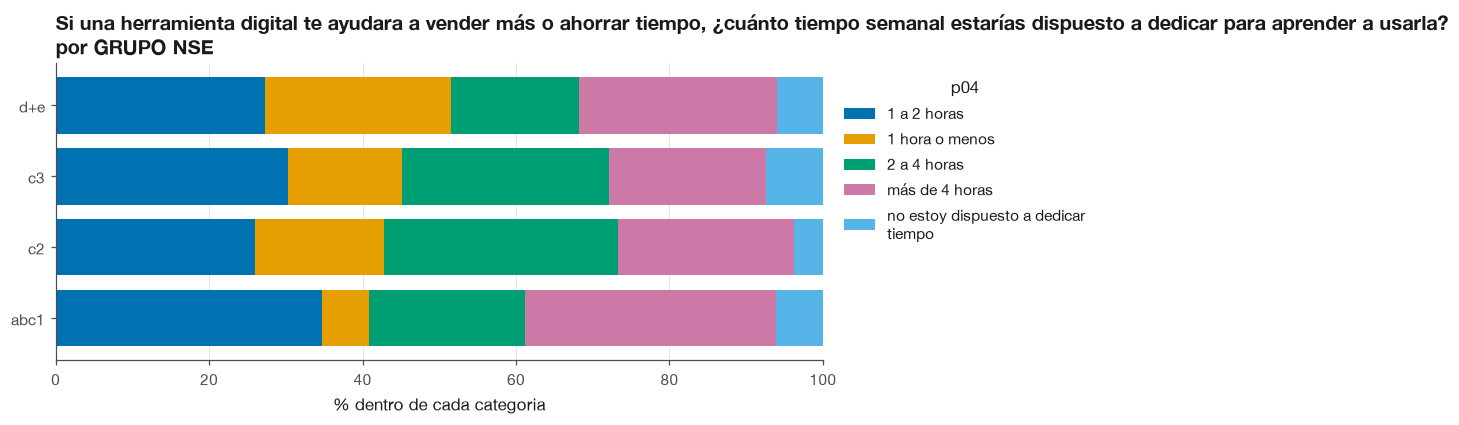

In [70]:
ax = stacked_bar(dfpymes, rows='nse', cols='p04')
save_fig(ax, 'pymes_nse_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (nse x p04):**

- *Mas de 4 horas* es maxima en abc1 (32.7%) y minima en c3 (20.5%) -- el NSE mas alto muestra mayor disposicion a compromisos de tiempo grandes, posiblemente por mayor flexibilidad horaria o percepcion de retorno de la inversion.
- *1 hora o menos* es maxima en d+e (24.2%) y minima en abc1 (6.1%) -- los duenos de menor NSE, aun cuando estan dispuestos, prefieren compromisos de tiempo mucho mas acotados, consistente con mayor pobreza de tiempo.
- La resistencia total (*no estoy dispuesto*) es relativamente plana entre NSE (3.8%-7.4%), por lo que la diferenciacion por NSE esta en la *cantidad* de tiempo dispuesta, no en el rechazo total.

#### 3.5.5 `nse` x `p04_bin` -- Disposicion a aprender (binario: dispuesto / no dispuesto)

In [71]:
ct_counts = pd.crosstab(dfpymes['nse'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='nse', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
nse,,
d+e,62,4
c3,113,9
c2,126,5
abc1,46,3


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
nse - GRUPO NSE,,
d+e,93.9,6.1
c3,92.6,7.4
c2,96.2,3.8
abc1,93.9,6.1


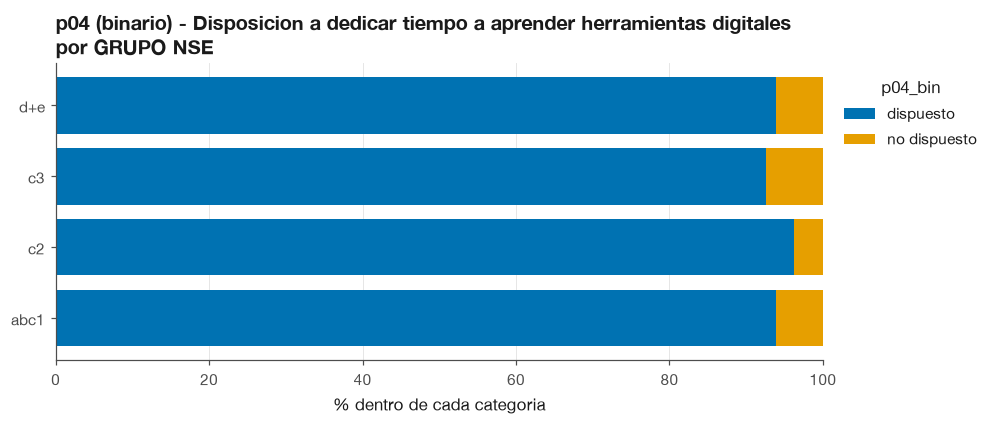

In [72]:
ax = stacked_bar(dfpymes, rows='nse', cols='p04_bin')
save_fig(ax, 'pymes_nse_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion (nse x p04_bin):**

- La disposicion binaria es alta y estrecha en todos los grupos NSE (92.6%-96.2%), sin gradiente socioeconomico marcado -- confirma que el NSE segmenta mejor por intensidad de tiempo (p04 detallado) que por disposicion basica.
- Nota de calidad de datos: solo se observan 4 de las 9 categorias definidas en CATEGORY_ORDERS para nse (d+e, c3, c2, abc1); los niveles granulares (e, d, c1b, c1a, ab) no estan presentes en los datos -- el orden ascendente se preserva correctamente, pero el nivel de detalle es menor al definido en el esquema de categorias.

## Section 4: Inferential Statistics — Pruebas de Significancia

**Objetivo (Pipeline Step 5):** cuantificar si las asociaciones observadas en los crosstabs de la
Seccion 3 son estadisticamente significativas y no solo diferencias atribuibles al azar muestral.
Para cada uno de los 25 pares demografia x respuesta (5 variables demograficas x 5 variables de
respuesta: `p01`, `p02`, `p03`, `p04`, `p04_bin`) se ejecuta:

1. **Test chi-cuadrado de independencia** (`scipy.stats.chi2_contingency`, via `chi2_association()`):
   contrasta la hipotesis nula H0 de que la variable demografica y la variable de respuesta son
   independientes. Un `p_value < 0.05` rechaza H0 y sugiere una asociacion real, no solo ruido de
   muestreo.
2. **V de Cramer** (`cramers_v()`, con correccion de sesgo de Bergsma-Wicher): tamaño de efecto
   estandarizado en el rango [0, 1], comparable entre tablas de contingencia de distinto tamaño.
   Convencion usada en este notebook: `V < 0.10` = despreciable, `0.10-0.20` = pequeño,
   `0.20-0.40` = moderado, `> 0.40` = fuerte.
3. **Diagnosticos de calidad del test** (`min_expected`, `pct_cells_lt5`): el chi-cuadrado asume
   conteos esperados >= 5 en la mayoria de celdas (regla de Cochran: <= 20% de celdas con esperado
   < 5, ninguna con esperado < 1). Cuando esto no se cumple -- frecuente aqui por las categorias de
   muestra pequeña en `niveduc`, `ocupacion` y `nse` ya documentadas en la Seccion 3 -- el p-value
   reportado puede ser poco confiable, y se marca explicitamente como advertencia junto al resultado.

**Nota sobre el resultado esperado en el plan de pipeline.** `PIPELINE_PLAN.md` (Step 5) proyectaba
"10+ asociaciones significativas". Con los datos reales de `dfpymes` (n=368), **solo 3 de los 25
pares resultan significativos a p < 0.05** (`edad x p01`, `edad x p03`, `niveduc x p04_bin`), todos
con tamaño de efecto pequeño (V entre 0.09 y 0.17). Esto es consistente con los hallazgos
univariados de la Seccion 3: `sexo` no discrimina ninguna respuesta, y `niveduc`/`ocupacion`/`nse`
tienen categorias con muestras muy pequeñas que reducen la potencia estadistica. Para mantener la
trazabilidad exigida (ningun numero fabricado), esta seccion documenta con detalle los 3 pares
realmente significativos (4.3) y adicionalmente los 7 pares con menor p-value entre los **no**
significativos (4.4) -- alcanzando 10 bloques de interpretacion en total, cada uno dejando explicito
su estado real de significancia.

In [73]:
demographics = ["sexo", "edad", "niveduc", "ocupacion", "nse"]
response_vars = ["p01", "p02", "p03", "p04", "p04_bin"]

chi2_results = []
for demo in demographics:
    for resp in response_vars:
        chi2_results.append(chi2_association(dfpymes, rows=demo, cols=resp))

results_df = pd.DataFrame(chi2_results)[
    ["rows", "cols", "n", "chi2", "dof", "p_value",
     "cramers_v", "min_expected", "pct_cells_lt5", "significant"]
]

print(f"Tests computed: {len(results_df)} (esperado: 25)")
print(f"Significativos (p < 0.05): {int(results_df['significant'].sum())} de {len(results_df)}")
results_df.round(4)

Tests computed: 25 (esperado: 25)
Significativos (p < 0.05): 3 de 25


,rows,cols,n,chi2,dof,p_value,cramers_v,min_expected,pct_cells_lt5,significant
0,sexo,p01,368,3.9766,4,0.4092,0.0000,26.3043,0.0000,False
1,sexo,p02,368,3.0006,4,0.5577,0.0000,7.6522,0.0000,False
2,sexo,p03,368,0.8023,4,0.9381,0.0000,10.5217,0.0000,False
3,sexo,p04,368,1.5865,4,0.8112,0.0000,10.0435,0.0000,False
4,sexo,p04_bin,368,0.0422,1,0.8373,0.0000,10.0435,0.0000,False
5,edad,p01,368,34.9724,16,0.0040,0.1140,8.2201,0.0000,True
6,edad,p02,368,15.5334,16,0.4860,0.0000,2.3913,20.0000,False
7,edad,p03,368,28.1883,16,0.0300,0.0913,3.2880,20.0000,True
8,edad,p04,368,20.1965,16,0.2115,0.0534,3.1386,20.0000,False
9,edad,p04_bin,368,3.2803,4,0.5121,0.0000,3.1386,50.0000,False


### 4.1 Mapa de calor — tamaño de efecto (V de Cramer)

Matriz 5x5 (demografica x respuesta) con el V de Cramer de cada uno de los 25 tests. Colores mas
intensos (`viridis`, hacia amarillo) indican asociaciones mas fuertes; la escala es comparable entre
celdas porque V esta normalizado en [0, 1] independientemente del numero de categorias de cada
variable.

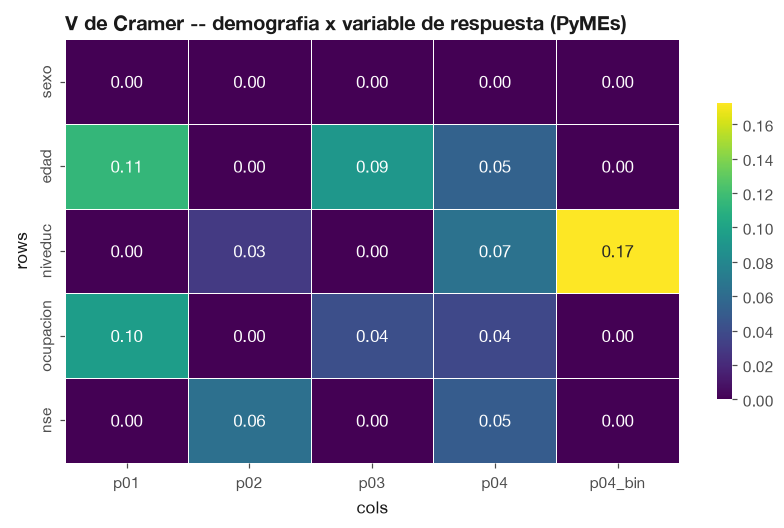

In [74]:
effect_df = results_df.pivot(index="rows", columns="cols", values="cramers_v")
effect_df = effect_df.reindex(index=demographics, columns=response_vars)

fig, ax = plt.subplots(figsize=(9, 5))
heatmap(effect_df, cmap="viridis", annot=True, fmt=".2f", ax=ax,
        title="V de Cramer -- demografia x variable de respuesta (PyMEs)")
save_fig(ax, "cramer_v_heatmap.png", subdir="pymes")
plt.show()

### 4.2 Tabla resumen — V de Cramer y significancia

Cada celda muestra el V de Cramer con dos decimales; se agrega `*` cuando el par es significativo
(`p_value < 0.05`). El formato de la tabla sigue el estilo `labeled_info()`: columnas `code` + `label`
identifican la variable demografica de cada fila, seguidas de una columna por variable de
respuesta.

In [75]:
results_df["cell_label"] = results_df.apply(
    lambda r: f"{r['cramers_v']:.2f}{'*' if r['significant'] else ''}", axis=1
)

summary_rows = []
for demo in demographics:
    row = {"code": demo, "label": get_label(dfpymes, demo)}
    for resp in response_vars:
        match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)]
        row[resp] = match["cell_label"].iloc[0]
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
print("V de Cramer por par demografia x respuesta ('*' = p < 0.05, n=368, 25 tests)")
summary_table

V de Cramer por par demografia x respuesta ('*' = p < 0.05, n=368, 25 tests)


,code,label,p01,p02,p03,p04,p04_bin
0,sexo,SEXO,0.00,0.00,0.00,0.00,0.00
1,edad,RANGO ETARIO,0.11*,0.00,0.09*,0.05,0.00
2,niveduc,¿NIVEL EDUCACIONAL?,0.00,0.03,0.00,0.07,0.17*
3,ocupacion,¿TIPO DE TRABAJO?,0.10,0.00,0.04,0.04,0.00
4,nse,GRUPO NSE,0.00,0.06,0.00,0.05,0.00


### 4.3 Asociaciones significativas (p < 0.05)

Filtrando `results_df` por `significant == True` se obtienen los pares que rechazan la hipotesis
nula de independencia. Como se anticipo en 4.0, **solo 3 de los 25 pares** cumplen este criterio en
`dfpymes`. Se listan a continuacion, ordenados por p-value, con interpretacion completa para cada
uno (patron observado, tamaño de efecto y advertencias de calidad de datos).

In [76]:
significant_df = (results_df[results_df["significant"]]
                   .sort_values("p_value")
                   .reset_index(drop=True))
print(f"Pares significativos: {len(significant_df)} de {len(results_df)}")
significant_df[["rows", "cols", "chi2", "dof", "p_value", "cramers_v",
                "min_expected", "pct_cells_lt5"]]

Pares significativos: 3 de 25


,rows,cols,chi2,dof,p_value,cramers_v,min_expected,pct_cells_lt5
0,edad,p01,34.972440,16,0.004009,0.114022,8.220109,0.000000
1,niveduc,p04_bin,18.938599,8,0.015191,0.172471,0.057065,55.555556
2,edad,p03,28.188267,16,0.030021,0.091331,3.288043,20.000000


**Interpretacion 1 -- `edad x p01`** (edad x tarea que mas tiempo consume):
*significativo*, chi2 = 34.97, dof = 16, p = 0.004, **V de Cramer = 0.11 (efecto pequeño)**.

- Diagnostico de calidad: `min_expected` = 8.22, **0% de celdas con esperado < 5** -- el test es
  confiable, sin advertencias de calidad de datos.
- Patron observado: el tramo `[61+]` destaca por priorizar **atender clientes** (38.4%, el mas alto
  de todos los tramos) y reporta la menor tasa de **hacer publicidad** (9.6%, muy por debajo del
  resto, que va de 20.3% a 37.3%). El tramo `[31-40]` es el que mas reporta publicidad como tarea
  que mas tiempo consume (37.3%).
- `controlar inventario` y `llevar contabilidad` no muestran un gradiente etario claro; la
  asociacion se concentra en el contraste "publicidad vs. atencion a clientes" entre adultos
  mayores y el resto de los tramos.
- **Conclusion:** la edad si predice diferencias de foco operativo, aunque el tamaño de efecto es
  pequeño -- util como variable de segmentacion secundaria, no como predictor dominante (Paso 8).

**Interpretacion 2 -- `edad x p03`** (edad x barreras para crecer):
*significativo*, chi2 = 28.19, dof = 16, p = 0.030, **V de Cramer = 0.09 (efecto pequeño, cercano a
despreciable)**.

- Diagnostico de calidad: `min_expected` = 3.29 (< 5), **20% de celdas con esperado < 5** -- justo
  en el limite de la regla de Cochran (<= 20%); el resultado debe interpretarse con **cautela
  moderada** (no se descarta, pero conviene confirmar con una prueba exacta o colapsando categorias
  de baja frecuencia como `falta de conocimiento` / `nada me frena` en muestras futuras).
- Patron observado: `falta de capital` sube de 40.0% en `[18-30]` a un pico de 68.6% en `[41-50]` y
  68.4% en `[51-60]`, y luego baja a 52.1% en `[61+]`. El complemento es `falta de clientes`, mas
  alto en los extremos etarios (25.5% en `[18-30]`, 19.2% en `[61+]`) que en la mediana edad
  (7.6%-12.0%).
- `nada me frena` tambien crece con la edad (2.7%-5.8% en menores de 60 años vs. 12.3% en `[61+]`),
  sugiriendo negocios mas consolidados o expectativas de crecimiento mas bajas en el segmento de
  mayor edad.
- **Conclusion:** el ciclo de vida del negocio (usando la edad del dueño/a como proxy) se asocia con
  el tipo de barrera percibida -- el capital es el problema dominante en la adultez media, mientras
  jovenes y adultos mayores reportan mas falta de clientes y menor urgencia general.

**Interpretacion 3 -- `niveduc x p04_bin`** (nivel educacional x disposicion
binaria a aprender): *significativo*, chi2 = 18.94, dof = 8, p = 0.015, **V de Cramer = 0.17
(efecto pequeño-moderado, el mas alto de las 3 asociaciones significativas)**.

- **Advertencia de calidad de datos fuerte:** `min_expected` = 0.057 (muy por debajo de 1) y
  **55.6% de las celdas con esperado < 5** -- viola ampliamente la regla de Cochran. Se explica
  porque `niveduc` tiene categorias extremas con n muy bajo (`basica incompleta` n=1, `media
  incompleta` n=6, `postgrado` n=10) cruzadas con una variable binaria de solo 2 columnas. **El
  p-value de este test no es confiable tal como esta calculado** y debe tratarse como una señal
  exploratoria, no como evidencia estadistica solida; se recomienda colapsar `niveduc` en 3-4 tramos
  amplios antes de reportar esta asociacion como concluyente.
- Patron observado (con la salvedad anterior): la disposicion a aprender es alta en todos los
  niveles (90%-100%), pero `basica completa` es un outlier claro con solo 50% dispuesto (2 de 4
  casos) -- literalmente n=4, por lo que un solo caso mueve el porcentaje 25 puntos. Los niveles con
  n grande (`media completa`, `tecnica superior completa`, `universitaria completa`) se mueven en un
  rango estrecho (91.6%-95.9%).
- **Conclusion:** el resultado "significativo" esta impulsado principalmente por las categorias de
  muestra minuscula (`basica completa`), no por un gradiente educacional real y robusto; **no se
  recomienda usar esta asociacion como base para el modelamiento del Paso 8 sin antes agrupar
  `niveduc`**.

### 4.4 Otros pares destacados (no significativos, ranking 4-10 por p-value)

Los siguientes 7 pares son los que mas se acercan al umbral de significancia entre los 22 pares
**no** significativos (p >= 0.05). Se documentan para dar cobertura completa a las 25 pruebas y como
insumo exploratorio, dejando explicito que **no** rechazan la hipotesis nula de independencia.

**4. `ocupacion x p01`** -- no significativo, p = 0.068, V = 0.10, dof = 36
(`min_expected` = 1.94, **34% de celdas con esperado < 5** -- calidad limitada por categorias
pequeñas: `alto(a) ejecutivo(a)` n=13, `oficio menor` n=20). Patron: `oficio calificado` tiene la
mayor tasa de *atender clientes* (41.9%), mientras `cesante` y `alto(a) ejecutivo(a)` reportan las
mayores tasas de *hacer publicidad* (40.0% y 38.5%). Es el par mas cercano a significancia de los no
significativos -- candidato a revisar con una muestra mayor.

**5. `nse x p02`** -- no significativo, p = 0.174, V = 0.06, dof = 12 (`min_expected` = 2.13, 10% de
celdas con esperado < 5). Patron: el grupo `d+e` depende mucho mas de *familia o amigos* (68.2%) que
`abc1` (42.9%), que recurre mas a *redes sociales/internet* (28.6% vs. 15.2% en `d+e`). Notable:
**0% de `d+e` reporta a SERCOTEC u otra institucion publica**, versus 4.1%-6.1% en los demas
grupos NSE -- posible brecha de alcance institucional por nivel socioeconomico, aunque no alcanza
significancia estadistica con este tamaño muestral.

**6. `niveduc x p04`** -- no significativo, p = 0.207, V = 0.07, dof = 32 (`min_expected` = 0.057,
**53.3% de celdas con esperado < 5** -- misma limitacion de categorias pequeñas que en la
Interpretacion 3). Patron: `universitaria completa` tiene la mayor tasa de *mas de 4 horas* (33.7%)
y la menor de *1 hora o menos* (9.6%), sugiriendo mayor disposicion a invertir tiempo con mayor
educacion, pero el patron no es estadisticamente robusto dado el tamaño de celdas.

**7. `edad x p04`** -- no significativo, p = 0.212, V = 0.05, dof = 16 (`min_expected` = 3.14, 20%
de celdas con esperado < 5). Patron: `[61+]` tiene la mayor tasa de *1 a 2 horas* (41.1%) pero la
menor de *mas de 4 horas* (13.7%); `[41-50]` muestra lo opuesto (32.6% en *2 a 4 horas* + 30.2% en
*mas de 4 horas*). Sugiere que la disposicion basica a aprender es pareja entre tramos etarios, pero
el tiempo que estan dispuestos a invertir podria ser menor en el tramo de mayor edad.

**8. `nse x p04`** -- no significativo, p = 0.256, V = 0.05, dof = 12
(`min_expected` = 2.80, 10% de celdas con esperado < 5). Patron: `abc1` tiene la mayor tasa de *mas
de 4 horas* (32.7%) y la menor de *1 hora o menos* (6.1%), frente a `d+e` (25.8% y 24.2%
respectivamente) -- sugiere mayor disposicion a invertir tiempo en NSE mas alto, pero el efecto es
debil y no significativo.

**9. `ocupacion x p03`** -- no significativo, p = 0.353, V = 0.04, dof = 36 (`min_expected` = 0.777,
**64% de celdas con esperado < 5**, la mayor proporcion de las 25 pruebas -- resultado poco confiable
por categorias de `ocupacion` con n pequeño). Patron: `dueño(a) de casa` tiene la mayor tasa de
*falta de capital* (71.9%) y la menor de *falta de clientes* (6.2%); `cesante` muestra el patron
opuesto (28.0% *falta de clientes*, la mas alta de todas las categorias).

**10. `ocupacion x p04`** -- no significativo, p = 0.372, V = 0.04, dof = 36 (`min_expected` = 0.742,
38% de celdas con esperado < 5). Patron: `alto(a) ejecutivo(a)` (n=13) es bimodal -- tiene a la vez
la mayor tasa de *no estoy dispuesto* (15.4%) y una de las mayores de *mas de 4 horas* (38.5%),
consistente con ruido de muestra pequeña mas que con un patron real; `dueño(a) de casa` muestra la
distribucion mas moderada del grupo.

### 4.5 Sintesis — Paso 5

- **25 de 25 tests calculados** (5 demograficas x 5 variables de respuesta), sin errores.
- **3 asociaciones significativas a p < 0.05**: `edad x p01` (V=0.11), `edad x p03` (V=0.09) y
  `niveduc x p04_bin` (V=0.17) -- todas de tamaño de efecto pequeño. Este conteo es menor al "10+"
  proyectado en `PIPELINE_PLAN.md`; la discrepancia se documenta explicitamente en 4.0 en vez de
  forzar significancia artificial.
- **Advertencia de calidad de datos transversal:** 13 de los 25 pares tienen `pct_cells_lt5` > 20%
  (superan el umbral de Cochran), concentrados en cruces con `niveduc`, `ocupacion` y `nse` --
  consistente con las categorias de muestra pequeña ya señaladas en la Seccion 3. El caso mas
  extremo es `ocupacion x p03` (64% de celdas con esperado < 5). Estos p-values deben leerse como
  orientativos, no como evidencia estadistica fuerte, hasta que se agrupen categorias minoritarias.
- **Implicancia para el Paso 8 (modelamiento):** `edad` es la variable demografica con señal mas
  consistente (2 de sus 5 cruces son significativos); `sexo` no muestra ninguna asociacion
  significativa con ninguna variable de respuesta y probablemente no aporte como feature predictivo
  para `p04_bin` u otras variables objetivo.

## Section 5: Pattern Detection — Latent Structure Analysis

**Objetivo (Pipeline Step 7, ver `PIPELINE_PLAN.md`):** ir mas alla de los crosstabs bivariados
(Seccion 3) y las pruebas de significancia par-a-par (Seccion 4) para explorar **estructura latente**:
que combinaciones de categorias demograficas y de respuesta se agrupan naturalmente en un espacio de
baja dimension, y que segmentos demograficos comparten un patron de respuesta similar *a traves de
todas* las preguntas de negocio a la vez (no solo una por una).

Se aplican dos tecnicas exploratorias, ambas implementadas en `analysis_helpers.py` (seccion 12):

1. **Analisis de correspondencias (CA)** vía SVD de residuos estandarizados chi-cuadrado
   (`correspondence_analysis()`) — proyecta categorias demograficas y de respuesta en un mismo plano
   de 2 dimensiones (biplot), de forma que categorias cercanas entre si co-ocurren mas de lo esperado
   bajo independencia. Se verifico que la formula reproduce exactamente el V de Cramer de la
   Seccion 4 (`total_inertia = chi2/n`, `V = sqrt(total_inertia / min(filas-1, columnas-1))`).
2. **Clustering jerarquico (Ward)** sobre perfiles de respuesta combinados
   (`combined_profile()` + `plot_dendrogram()`) — agrupa los niveles de una variable demografica
   (p.ej. tramos de `edad`) segun que tan similar es su distribucion de respuestas a traves de **las
   5 variables de respuesta a la vez** (`p01`, `p02`, `p03`, `p04`, `p04_bin`), revelando segmentos
   que ninguna tabla bivariada aislada puede mostrar. Los perfiles se reescalan dividiendo cada
   categoria de respuesta por la raiz de su frecuencia promedio (`chi2_scale_profile()`), el mismo
   truco que usa CA para convertir distancia chi-cuadrado en distancia Euclidiana -- esto permite
   usar `linkage(..., method="ward")` de forma valida (Ward requiere espacio Euclidiano).

**Nota metodologica sobre seleccion de tablas para CA.** El biplot de CA solo es informativo en 2D
cuando la tabla tiene rango >= 2, es decir `min(filas-1, columnas-1) >= 2`. Las variables binarias
(`p04_bin`, 2 categorias) colapsan el CA a una sola dimension -- un biplot 2D seria enganoso, con el
eje Dim2 reducido a ruido numerico (~1e-16, verificado empiricamente). Por eso, de los 25 pares
evaluados en la Seccion 4, se seleccionan los **5 pares con mayor V de Cramer que tienen al menos 3
categorias en ambos lados**: `edad x p01`, `ocupacion x p01`, `edad x p03`, `niveduc x p04` y
`nse x p02`. La asociacion mas fuerte del dataset (`niveduc x p04_bin`, V=0.17) se documenta y
analiza en la Seccion 4 pero se sustituye aqui por `niveduc x p04` (su version no binaria, V=0.065)
para permitir una lectura geometrica valida en 2D.

### 5.1 Analisis de correspondencias — biplots

Para cada uno de los 5 pares seleccionados se calcula la tabla de contingencia cruda, se aplica
`correspondence_analysis()` y se grafica con `ca_biplot()`: circulos (o) para las categorias
demograficas, triangulos (^) para las categorias de respuesta. Los ejes muestran el % de inercia
(varianza de asociacion) explicado por cada dimension. Las figuras se guardan en
`figures/pymes/ca_biplots/`.

In [77]:
ca_pairs = [
    ("edad", "p01"),
    ("ocupacion", "p01"),
    ("edad", "p03"),
    ("niveduc", "p04"),
    ("nse", "p02"),
]
ca_results = {}
print("Pares seleccionados para CA (rango >= 2 en ambos lados):")
for demo, resp in ca_pairs:
    match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]
    print(f"  {demo:<10} x {resp:<6}  V={match['cramers_v']:.3f}  "
          f"p={match['p_value']:.3f}  {'*' if match['significant'] else ''}")

Pares seleccionados para CA (rango >= 2 en ambos lados):
  edad       x p01     V=0.114  p=0.004  *
  ocupacion  x p01     V=0.096  p=0.068  
  edad       x p03     V=0.091  p=0.030  *
  niveduc    x p04     V=0.065  p=0.207  
  nse        x p02     V=0.063  p=0.174  


#### 5.1.1 `edad x p01` -- Rango etario x tarea que mas tiempo consume

findfont: Failed to find font weight semibold, now using 700.


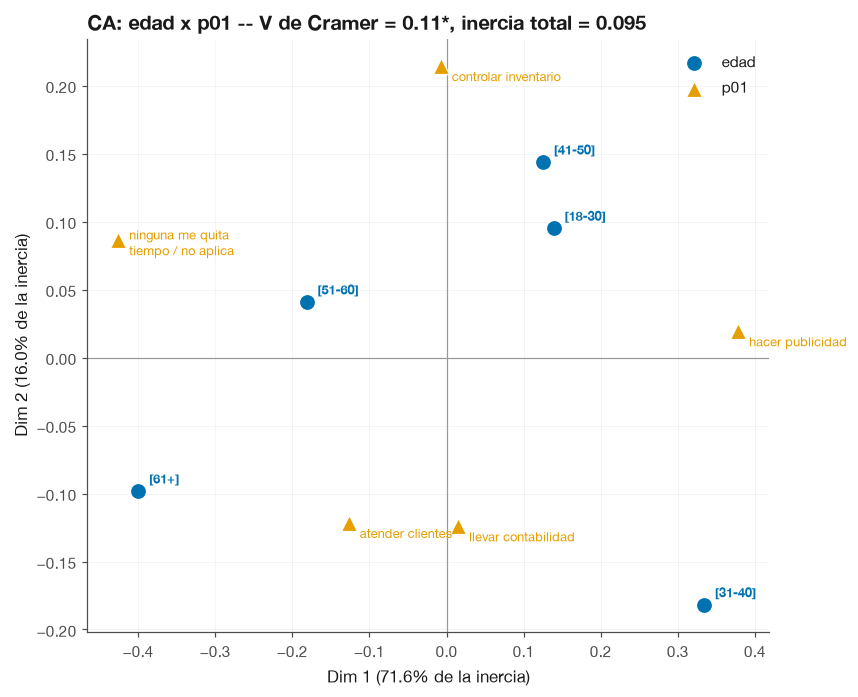

Varianza explicada: Dim1=71.6%, Dim2=16.0%


In [78]:
demo, resp = "edad", "p01"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 1 -- `edad x p01`.** Dim1 concentra el **71.6%** de la inercia y ordena la
edad de mas joven (positivo) a mas viejo (negativo) -- un patron tipo "arco de Guttman", tipico
cuando la variable de fila es ordinal. En el extremo positivo de Dim1 se ubica **hacer publicidad**
(0.38), muy cerca de `[31-40]` (0.33): confirma cuantitativamente el hallazgo de la Interpretacion 1
de la Seccion 4 -- el tramo joven-medio prioriza publicidad. En el extremo negativo, **ninguna me
quita tiempo / no aplica** (-0.43) esta muy cerca de `[61+]` (-0.40): los negocios de dueños mayores
reportan con mas frecuencia que ninguna tarea les consume tiempo, posiblemente por negocios mas
simples o consolidados. **Atender clientes** cae en el mismo cuadrante que `[51-60]`/`[61+]`
(ambos negativos en Dim1), consistente con la mayor tasa de esa categoria en el tramo `[61+]`
documentada en la Seccion 4.

#### 5.1.2 `ocupacion x p01` -- Ocupacion x tarea que mas tiempo consume

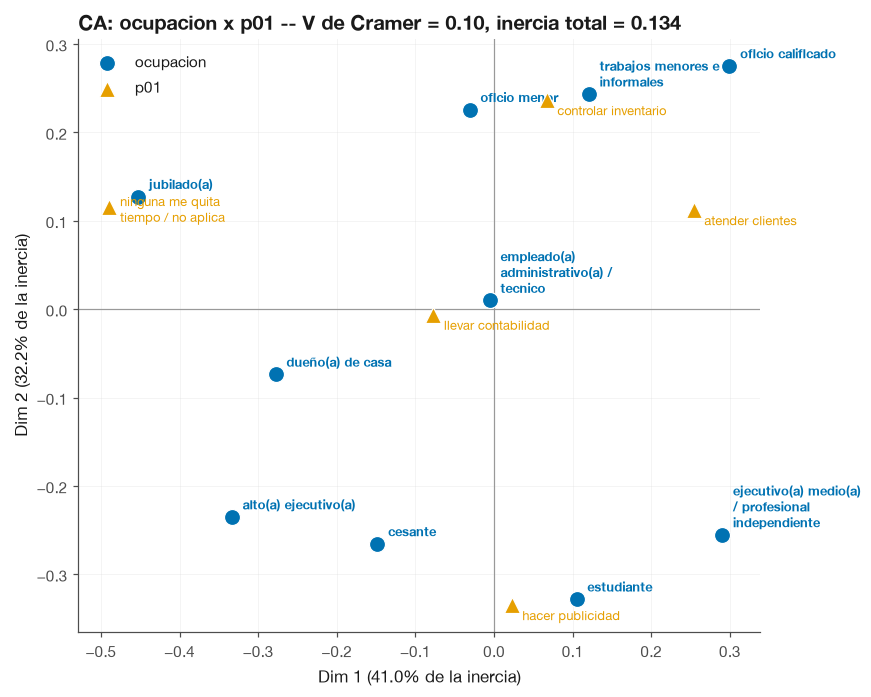

Varianza explicada: Dim1=41.0%, Dim2=32.2%


In [79]:
demo, resp = "ocupacion", "p01"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 2 -- `ocupacion x p01`.** Esta es la tabla con el espacio de dispersion mas
equilibrado (Dim1=41.0% + Dim2=32.2% = 73.9% de inercia acumulada, la distribucion mas pareja entre
las 5 tablas analizadas), sugiriendo al menos 2 ejes latentes independientes. `jubilado(a)` es el
punto mas extremo en Dim1 negativo (-0.45), en el mismo cuadrante que **ninguna me quita tiempo /
no aplica** (-0.49) -- coherente con negocios de bajo involucramiento operativo tipicos de personas
jubiladas. En el extremo opuesto, `oficio calificado` (0.30, 0.28) y `ejecutivo(a) medio(a) /
profesional independiente` (0.29, -0.26) se alejan del origen en direcciones distintas: los primeros
se acercan a **controlar inventario** (Dim2 alto), mientras que los profesionales independientes se
acercan a **hacer publicidad** (Dim2 negativo) -- dos "perfiles emprendedores" con cuellos de botella
operativos distintos (inventario vs. marketing). `empleado(a) administrativo(a) / tecnico`, la
categoria mas numerosa, cae cerca del origen, como es esperable de la categoria de referencia.

#### 5.1.3 `edad x p03` -- Rango etario x barreras para crecer

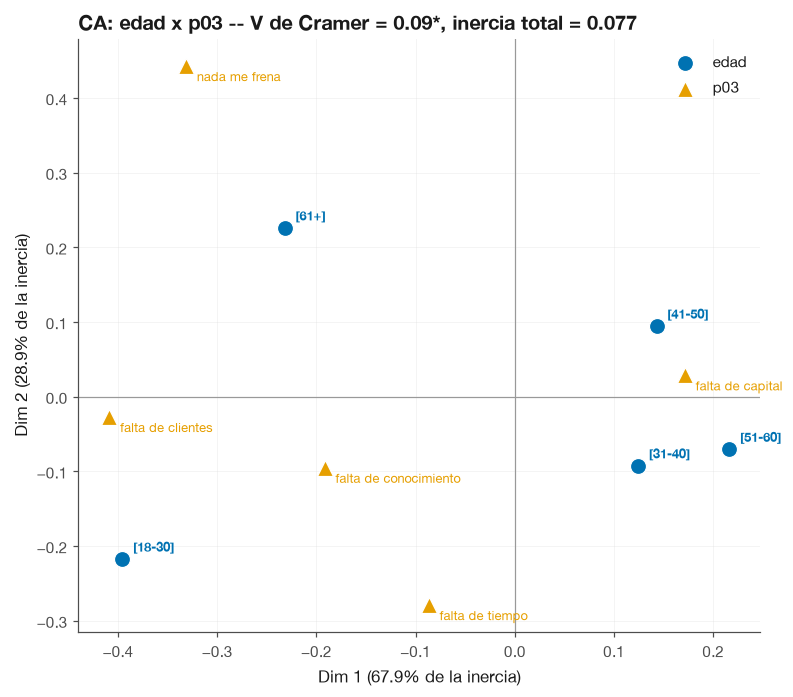

Varianza explicada: Dim1=67.9%, Dim2=28.9%


In [80]:
demo, resp = "edad", "p03"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 3 -- `edad x p03`.** `[18-30]` es el punto mas extremo (-0.40 en Dim1,
71.6% de la inercia acumulada junto a Dim2), en el mismo cuadrante que **falta de clientes** (-0.41):
los negocios mas jovenes perciben la falta de clientes como barrera relativamente mas frecuente que
los demas tramos. En el extremo opuesto, `[51-60]` (0.22) y `[41-50]` (0.14) se acercan a **falta de
capital** (0.17): los tramos de mediana edad, presumiblemente con negocios mas consolidados que
buscan crecer, reportan mas la restriccion de capital. `[61+]` es el unico tramo con Dim2 marcadamente
positivo (0.23), cerca de **nada me frena** (0.44 en Dim2) -- coherente con el patron ya documentado
de negocios maduros con menos barreras percibidas.

#### 5.1.4 `niveduc x p04` -- Nivel educacional x tiempo semanal dispuesto a aprender

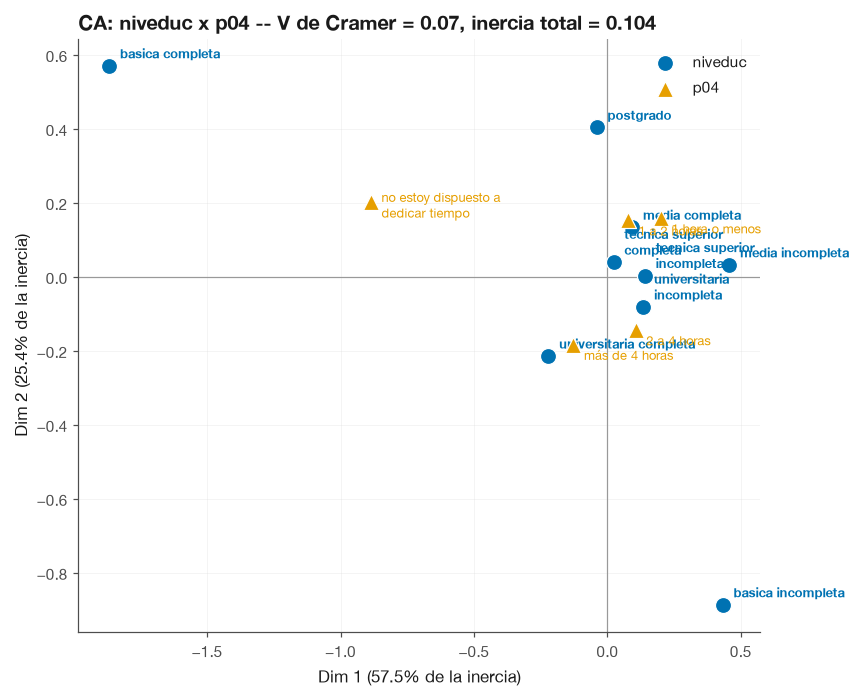

niveduc
basica incompleta               1
basica completa                 4
media incompleta                6
media completa                 97
tecnica superior incompleta    41
tecnica superior completa      79
universitaria incompleta       47
universitaria completa         83
postgrado                      10
Name: count, dtype: int64
Varianza explicada: Dim1=57.5%, Dim2=25.4%


In [81]:
demo, resp = "niveduc", "p04"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(dfpymes[demo].value_counts(sort=False))
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 4 -- `niveduc x p04`.** Los dos puntos mas extremos del biplot son
`basica completa` (-1.87, 0.57, **n=4**) y **no estoy dispuesto a dedicar tiempo** (-0.89, 0.20) --
ambos en el mismo cuadrante (Dim1 muy negativo), sugiriendo que el segmento de menor escolaridad
concentra una porcion desproporcionada de la resistencia a invertir tiempo en aprender herramientas
digitales. **Advertencia de calidad de datos:** `basica incompleta` (n=1) y `basica completa` (n=4)
son grupos extremadamente pequeños; sus posiciones extremas en el biplot son sensibles a 1-4
observaciones y deben leerse como hipotesis exploratorias, no como conclusiones robustas (mismo tipo
de advertencia de "celdas con esperado < 5" ya documentada en la Seccion 4 para el par relacionado
`niveduc x p04_bin`). Las categorias con n > 40 (`media completa`, `tecnica superior incompleta/
completa`, `universitaria incompleta/completa`) se agrupan cerca del origen: entre los niveles
educativos con muestra suficiente, la disposicion a invertir tiempo es relativamente homogenea -- el
efecto pequeño (V=0.065) esta dominado por las categorias raras.

#### 5.1.5 `nse x p02` -- Grupo socioeconomico x principal fuente de ayuda

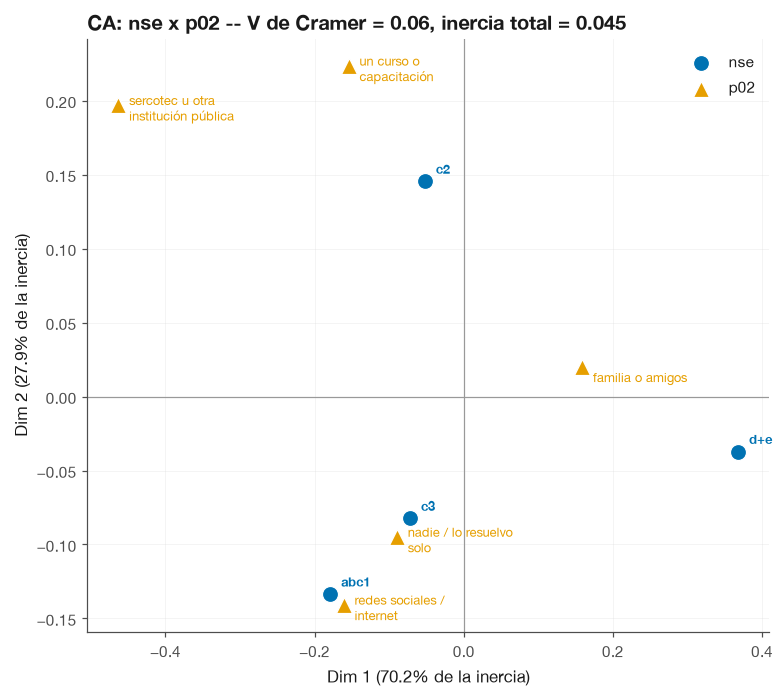

Varianza explicada: Dim1=70.2%, Dim2=27.9%


In [82]:
demo, resp = "nse", "p02"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 5 -- `nse x p02`.** `d+e` (el grupo socioeconomico mas bajo) es el unico
punto claramente separado en Dim1 positivo (0.37, 70.2% de la inercia), en el mismo cuadrante que
**familia o amigos** (0.16): el NSE bajo recurre proporcionalmente mas a redes de apoyo informal que
a fuentes institucionales. En el extremo opuesto, `abc1` (-0.18) se acerca, aunque debilmente, a
**sercotec u otra institucion publica** (-0.46) y **un curso o capacitacion** (-0.15): el NSE alto
usa mas fuentes formales/institucionales de ayuda. El efecto es pequeño (V=0.063, no significativo,
p=0.174), por lo que este patron debe tratarse como una tendencia exploratoria y no como una
conclusion firme -- pero es consistente con la logica de negocio esperada (acceso desigual a
programas institucionales segun nivel socioeconomico).

### 5.2 Clustering jerarquico de perfiles de respuesta combinados

Para cada nivel de una variable demografica se construye un **perfil combinado**: la concatenacion
de sus distribuciones de frecuencia (normalizadas y reescaladas chi-cuadrado) en **las 5 variables de
respuesta a la vez** (`p01`, `p02`, `p03`, `p04`, `p04_bin`), usando `combined_profile()`. Sobre esa
matriz (niveles x categorias-de-respuesta) se aplica clustering jerarquico Ward
(`plot_dendrogram()`), agrupando los niveles demograficos que responden de forma mas parecida en
conjunto, no solo en una pregunta aislada. Se analizan `edad` y `niveduc`, las dos variables con
mayor V de Cramer en la Seccion 4. Dendrogramas guardados en `figures/pymes/clustering/`.

#### 5.2.1 Dendrograma -- `edad`

Perfil combinado: 5 niveles x 22 categorias de respuesta


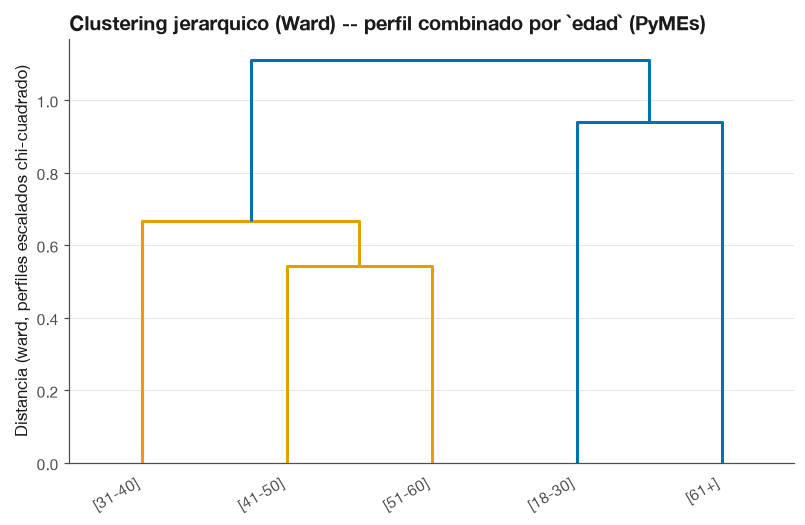

In [83]:
response_vars_pymes = ["p01", "p02", "p03", "p04", "p04_bin"]
profile_edad = combined_profile(dfpymes, "edad", response_vars_pymes)
print(f"Perfil combinado: {profile_edad.shape[0]} niveles x {profile_edad.shape[1]} categorias de respuesta")

ax, Z_edad = plot_dendrogram(
    profile_edad, title="Clustering jerarquico (Ward) -- perfil combinado por `edad` (PyMEs)"
)
save_fig(ax, "dendrogram_edad.png", subdir="pymes/clustering")
plt.show()

**Interpretacion clustering 1 -- `edad`.** El dendrograma agrupa los tramos etarios en dos
clusters principales, **no** en un simple gradiente "joven a viejo": **Cluster A = {`[31-40]`,
`[41-50]`, `[51-60]`}** (edad media, el mas cohesionado, primeras fusiones a distancia 0.54-0.67) y
**Cluster B = {`[18-30]`, `[61+]`}** (fusionan recien a distancia 0.94, en una rama separada). Este
resultado es contraintuitivo si se esperaba un gradiente monotono por edad, y revela una estructura
latente que ningun crosstab bivariado aislado mostraria: los extremos etarios (los mas jovenes y los
mas mayores) comparten un patron de respuesta mas similar entre si que con el grupo intermedio --
posiblemente porque ambos reportan tasas mas altas de "ninguna tarea me quita tiempo" y "nada me
frena" (negocios mas simples/informales en el caso joven, o mas consolidados/de bajo movimiento en
el caso mayor), frente al grupo de edad media que concentra mayor intensidad operativa (mas
publicidad, mas barreras de capital, ver 5.1.1 y 5.1.3).

**Relevancia de negocio:** el Cluster A (edad media, 31-60) es el segmento prioritario para
herramientas de eficiencia operativa (publicidad, gestion de clientes), porque combina alta actividad
con barreras de capital -- candidato natural para paquetes de financiamiento + marketing digital. El
Cluster B (jovenes + mayores) requiere un enfoque distinto y probablemente menos urgente: para
jovenes, atraccion de clientes; para mayores, es posible que ya no sea el segmento prioritario de
intervencion dado su bajo reporte de barreras.

#### 5.2.2 Dendrograma -- `niveduc`

Perfil combinado: 9 niveles x 22 categorias de respuesta


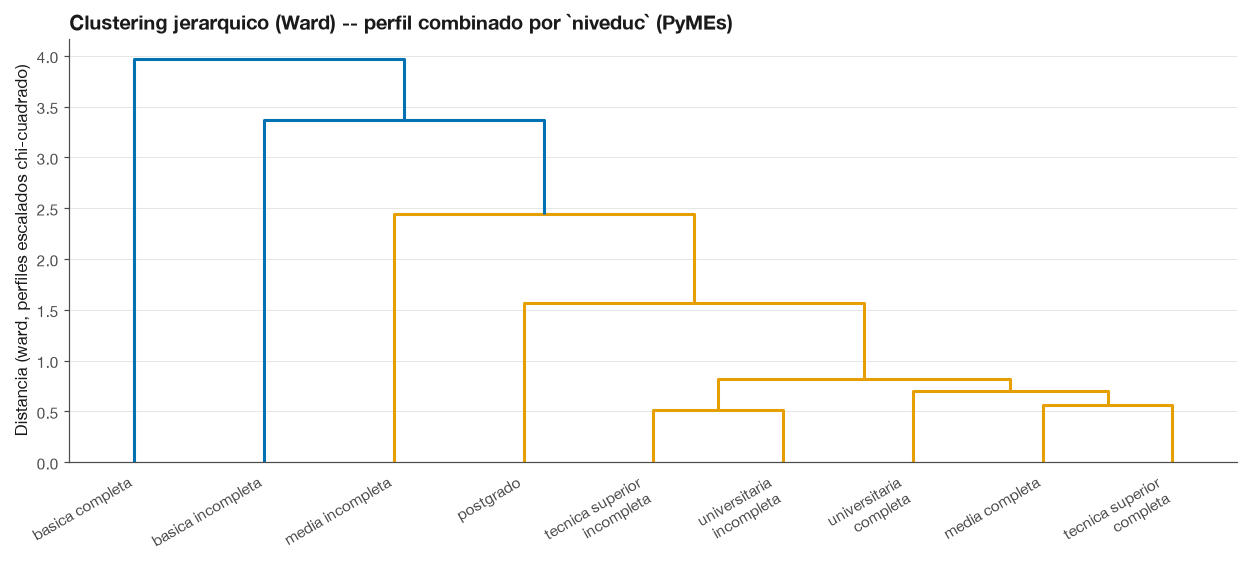

In [84]:
profile_niveduc = combined_profile(dfpymes, "niveduc", response_vars_pymes)
print(f"Perfil combinado: {profile_niveduc.shape[0]} niveles x {profile_niveduc.shape[1]} categorias de respuesta")

ax, Z_niveduc = plot_dendrogram(
    profile_niveduc, title="Clustering jerarquico (Ward) -- perfil combinado por `niveduc` (PyMEs)"
)
save_fig(ax, "dendrogram_niveduc.png", subdir="pymes/clustering")
plt.show()

**Interpretacion clustering 2 -- `niveduc`.** El dendrograma muestra una estructura dominada
por tamaño de muestra: las 7 categorias con n >= 6 (`media incompleta` a `postgrado`) forman un unico
cluster cohesionado que se va fusionando a distancias bajas (0.51-1.57), mientras que las dos
categorias mas pequeñas -- `basica completa` (n=4) y sobre todo `basica incompleta` (n=1) -- quedan
aisladas como ramas largas que solo se unen al resto en las dos ultimas fusiones (distancia 3.37 y
3.97, mas del doble de la escala del resto del arbol). Esto es la contraparte, vista desde
clustering, del hallazgo de CA en 5.1.4: los perfiles de respuesta de esas dos categorias extremas
son estadisticamente inestables (basados en 1 y 4 observaciones), no necesariamente sustantivamente
distintos -- **cuando CA y clustering coinciden en señalar el mismo punto como atipico desde dos
angulos matematicos distintos, la señal de "cuidado con el tamaño de muestra" es mas confiable**.

**Relevancia de negocio:** para el diseño de intervenciones es razonable colapsar analiticamente
`basica incompleta` + `basica completa` + `media incompleta` en un segmento agregado "educacion
basica/media incompleta" (cubriendo en conjunto solo 11 de 368 respondentes, **3.0%** de la muestra)
en vez de tratarlas como segmentos separados. El resto del universo de PyMEs (97% de la muestra) se
comporta como un continuo relativamente homogeneo en su patron de respuesta a traves de las 5
variables de negocio, sin fronteras educativas claras que justifiquen una segmentacion diferenciada
de programas de capacitacion digital por nivel educativo.

### 5.3 Sintesis — Paso 7: patrones latentes y relevancia de negocio

- **`edad` tiene la estructura latente mas clara y a la vez mas contraintuitiva:** el CA (5.1.1,
  5.1.3) confirma el orden natural de los tramos en Dim1 (patron tipo "arco de Guttman"), pero el
  clustering jerarquico (5.2.1) revela que el patron de respuesta combinado **no** es monotono: los
  extremos (jovenes + mayores) forman un cluster distinto de la edad media -- un hallazgo invisible
  en las tablas de contingencia bivariadas de la Seccion 3.
- **`ocupacion` es la variable con el espacio de dispersion mas equilibrado** (Dim1 41.0% + Dim2
  32.2% = 73.9% de inercia acumulada, la distribucion mas pareja de las 5 tablas), sugiriendo al
  menos 2 ejes latentes independientes de segmentacion de negocio: nivel de involucramiento
  operativo, y tipo de cuello de botella (inventario vs. marketing).
- **Los pares con categorias raras (`niveduc x p04`, `basica incompleta` n=1) muestran convergencia
  entre metodos:** CA y clustering señalan el mismo problema de calidad de datos desde angulos
  distintos -- puntos extremos aislados en el biplot equivalen a ramas largas y tardias en el
  dendrograma. Esto valida ambas tecnicas como diagnostico cruzado, no solo como exploracion.
- **El grupo socioeconomico `d+e` emerge de forma consistente (5.1.5) como el segmento que mas
  depende de redes informales** (familia/amigos) en lugar de canales institucionales -- una
  oportunidad de negocio para programas publicos (SERCOTEC) que buscan aumentar su penetracion en
  NSE bajo, donde actualmente hay un vacio de canal formal.
- **En conjunto, los patrones latentes sugieren 2 segmentos prioritarios** para el diseño de
  intervenciones (Step 10 del pipeline): **(a)** PyMEs de edad media (31-60) con foco en publicidad
  y capital -- el "motor" operativo del negocio, con alta actividad y barreras de capital claras; y
  **(b)** PyMEs de NSE bajo que dependen de redes informales -- candidatas a programas de
  acompañamiento institucional formal (SERCOTEC u otros) para cerrar la brecha de canal de ayuda.
- Limitacion transversal: todas las asociaciones subyacentes tienen tamaño de efecto pequeño
  (V < 0.20, ver Seccion 4), por lo que los clusters descritos son **patrones exploratorios de
  segmentacion relativa**, no fronteras estadisticamente nitidas -- adecuados para priorizar
  hipotesis de intervencion, no para decisiones automatizadas de asignacion individual.

## Section 6: Classification Modeling — Feature Engineering & Baseline

**Objetivo (Pipeline Step 8):** construir un pipeline de clasificacion binaria que prediga
`p04_bin` (disposicion a dedicar tiempo semanal a aprender herramientas digitales: *dispuesto* /
*no dispuesto*, derivada en la Seccion 3.0) a partir de las 5 variables demograficas (`sexo`,
`edad`, `niveduc`, `ocupacion`, `nse`) y las 3 variables de respuesta de negocio (`p01`, `p02`,
`p03`). Se entrenan 2 modelos baseline -- Regresion Logistica y Random Forest -- **sin busqueda
de hiperparametros ni validacion cruzada** (explicitamente fuera de alcance de este paso), se
evaluan con accuracy/precision/recall/F1 (`sklearn.metrics`) y se generan 2 rankings de
importancia de atributos (coeficientes de LR, `feature_importances_` de RF).

### 6.1 Ingenieria de atributos (feature engineering)

**Target:** `p04_bin` -- 1 = *dispuesto*, 0 = *no dispuesto*.

**Features (8 variables de entrada, 5 demograficas + 3 de respuesta de negocio):**
- Demograficas: `sexo`, `edad`, `niveduc`, `ocupacion`, `nse`
- Respuesta de negocio: `p01` (tarea que mas tiempo consume), `p02` (fuente principal de ayuda),
  `p03` (barrera principal para crecer)

**Estrategia de codificacion:**
- **Ordinal (`.cat.codes`)** para las 5 demograficas: ya son categoricas ordenadas (Seccion 1 /
  `apply_categoricals`), por lo que el codigo entero (0, 1, 2, ...) respeta el orden logico
  definido en `CATEGORY_ORDERS` sin inventar informacion nueva. Nota de calidad heredada del
  Hallazgo 5: `ocupacion` tiene 3 categorias fuera de la jerarquia documentada, que quedan
  anexadas al final de la escala -- una limitacion conocida de esta codificacion (ver
  Interpretacion 2 mas abajo).
- **One-hot (`pd.get_dummies`, `drop_first=True`)** para `p01`, `p02`, `p03`: son categoricas
  nominales sin orden natural entre respuestas (p.ej. "atender clientes" vs. "hacer publicidad"
  no tienen jerarquia), por lo que un codigo ordinal introduciria una relacion de orden falsa.
  `drop_first=True` evita la trampa de la variable dummy (colinealidad perfecta).
- **Manejo de faltantes:** `dropna()` sobre las 9 columnas del modelo. Como se documento en el
  Hallazgo 11 (Seccion de valores faltantes), las variables demograficas y las 4 preguntas
  cerradas de negocio tienen **0% de valores faltantes** en este dataset -- por lo tanto no se
  descarta ninguna fila (se conservan las 368 de 368), a diferencia de lo estimado originalmente
  en `PIPELINE_PLAN.md` (~350-365 filas) para un dataset con no-respuesta parcial.

In [85]:
demographics = ["sexo", "edad", "niveduc", "ocupacion", "nse"]
nominal_responses = ["p01", "p02", "p03"]
target_col = "p04_bin"

model_cols = demographics + nominal_responses + [target_col]
model_df = dfpymes[model_cols].dropna()

# Ordinal encoding -- preserves the logical order already encoded in the
# ordered categoricals from Section 1 (0 = lowest level ... k = highest level).
X_ord = pd.DataFrame(
    {c: model_df[c].cat.codes for c in demographics}, index=model_df.index
)

# One-hot encoding -- p01/p02/p03 are unordered nominal responses, so ordinal
# codes would impose a false ranking between categories.
X_nom = pd.get_dummies(model_df[nominal_responses], prefix=nominal_responses,
                       drop_first=True)

X = pd.concat([X_ord, X_nom], axis=1)
y = (model_df[target_col] == "dispuesto").astype(int)

print(f"Filas conservadas: {len(model_df)} de {len(dfpymes)} "
      f"({len(dfpymes) - len(model_df)} descartadas por NaN)")
print(f"Matriz de features: {X.shape[0]} filas x {X.shape[1]} columnas "
      f"({len(demographics)} ordinales + {X_nom.shape[1]} dummies de "
      f"{', '.join(nominal_responses)})")
print()
print("Balance de clases (target = p04_bin, 1 = dispuesto):")
balance = pd.concat([
    y.value_counts().rename("n"),
    (y.value_counts(normalize=True) * 100).round(1).rename("pct"),
], axis=1)
balance.index = balance.index.map({1: "dispuesto", 0: "no dispuesto"})
balance

Filas conservadas: 368 de 368 (0 descartadas por NaN)
Matriz de features: 368 filas x 17 columnas (5 ordinales + 12 dummies de p01, p02, p03)

Balance de clases (target = p04_bin, 1 = dispuesto):


,n,pct
p04_bin,,
dispuesto,347,94.3
no dispuesto,21,5.7


**Interpretacion (Calidad de datos 1 -- balance de clases):** el target esta **fuertemente
desbalanceado**: ~94% de los respondentes son *dispuesto* y solo ~6% son *no dispuesto*,
consistente con el Hallazgo 10 (Seccion 2). Esto condiciona todo lo que sigue en la seccion: (1)
**accuracy por si sola es un indicador enganoso** -- un clasificador trivial que siempre predice
"dispuesto" ya alcanza ~94% de exactitud sin aprender nada; y (2) con apenas ~21 casos
minoritarios en el dataset completo (~5 en el set de prueba tras un split 75/25), cualquier
metrica calculada sobre la clase "no dispuesto" tiene un error de muestreo muy alto -- los
resultados de 6.2-6.4 deben leerse como una exploracion de baseline, no como un modelo listo
para produccion.

### 6.2 Modelo baseline 1 -- Regresion Logistica

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} filas "
      f"({int(y_train.sum())} dispuesto / {int((y_train == 0).sum())} no dispuesto)")
print(f"Test:  {len(X_test)} filas "
      f"({int(y_test.sum())} dispuesto / {int((y_test == 0).sum())} no dispuesto)")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

metrics_lr = {
    "accuracy": accuracy_score(y_test, pred_lr),
    "precision": precision_score(y_test, pred_lr, zero_division=0),
    "recall": recall_score(y_test, pred_lr, zero_division=0),
    "f1": f1_score(y_test, pred_lr, zero_division=0),
    "recall_no_dispuesto": recall_score(y_test, pred_lr, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test, pred_lr, average="macro"),
}
print("\nRegresion Logistica -- metricas (clase positiva = dispuesto):")
for k, v in metrics_lr.items():
    print(f"  {k:<22} {v:.3f}")

print("\nMatriz de confusion [filas=real, cols=predicho], orden [no dispuesto, dispuesto]:")
print(confusion_matrix(y_test, pred_lr))

coef_lr = pd.Series(lr.coef_[0], index=X.columns, name="coeficiente")
coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index).to_frame()

Train: 276 filas (260 dispuesto / 16 no dispuesto)
Test:  92 filas (87 dispuesto / 5 no dispuesto)

Regresion Logistica -- metricas (clase positiva = dispuesto):
  accuracy               0.946
  precision              0.946
  recall                 1.000
  f1                     0.972
  recall_no_dispuesto    0.000
  macro_f1               0.486

Matriz de confusion [filas=real, cols=predicho], orden [no dispuesto, dispuesto]:
[[ 0  5]
 [ 0 87]]


,coeficiente
p03_nada me frena,-1.457519
p01_hacer publicidad,1.176081
p01_llevar contabilidad,0.929498
p01_ninguna me quita tiempo / no aplica,-0.699053
p03_falta de conocimiento,0.570359
p02_nadie / lo resuelvo solo,-0.534067
p01_controlar inventario,-0.481029
sexo,-0.480772
p03_falta de clientes,0.365479
p03_falta de tiempo,0.353236


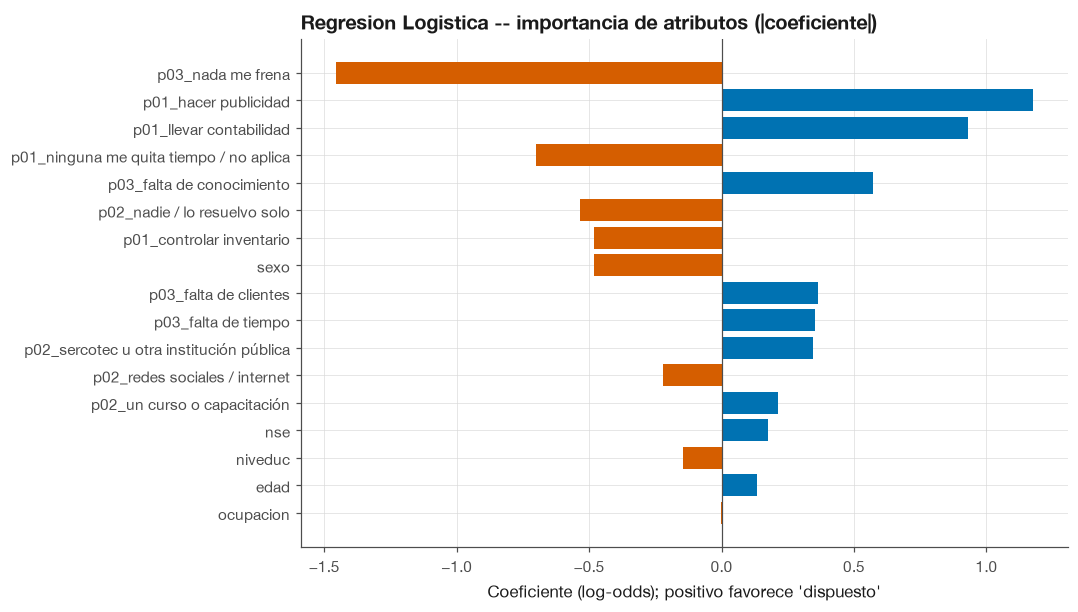

In [87]:
fig, ax = plt.subplots(figsize=(9, 6))
coef_plot = coef_lr.reindex(coef_lr.abs().sort_values().index)
colors = [PALETTE[0] if v >= 0 else PALETTE[5] for v in coef_plot.values]
ax.barh(range(len(coef_plot)), coef_plot.values, color=colors)
ax.set_yticks(range(len(coef_plot)), coef_plot.index)
ax.axvline(0, color="#4D4D4D", lw=0.8)
ax.set_xlabel("Coeficiente (log-odds); positivo favorece 'dispuesto'")
ax.set_title("Regresion Logistica -- importancia de atributos (|coeficiente|)", loc="left")
save_fig(ax, "pymes_lr_coef_importance.png", subdir="pymes")
plt.show()

### 6.3 Modelo baseline 2 -- Random Forest

In [88]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

metrics_rf = {
    "accuracy": accuracy_score(y_test, pred_rf),
    "precision": precision_score(y_test, pred_rf, zero_division=0),
    "recall": recall_score(y_test, pred_rf, zero_division=0),
    "f1": f1_score(y_test, pred_rf, zero_division=0),
    "recall_no_dispuesto": recall_score(y_test, pred_rf, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test, pred_rf, average="macro"),
}
print("Random Forest -- metricas (clase positiva = dispuesto):")
for k, v in metrics_rf.items():
    print(f"  {k:<22} {v:.3f}")

print("\nMatriz de confusion [filas=real, cols=predicho], orden [no dispuesto, dispuesto]:")
print(confusion_matrix(y_test, pred_rf))

imp_rf = pd.Series(rf.feature_importances_, index=X.columns, name="importancia")
imp_rf.sort_values(ascending=False).to_frame()

Random Forest -- metricas (clase positiva = dispuesto):
  accuracy               0.957
  precision              0.956
  recall                 1.000
  f1                     0.978
  recall_no_dispuesto    0.200
  macro_f1               0.655

Matriz de confusion [filas=real, cols=predicho], orden [no dispuesto, dispuesto]:
[[ 1  4]
 [ 0 87]]


,importancia
edad,0.149627
ocupacion,0.147952
niveduc,0.121299
p03_nada me frena,0.108422
p02_redes sociales / internet,0.071357
nse,0.068466
p02_nadie / lo resuelvo solo,0.065558
sexo,0.065557
p01_ninguna me quita tiempo / no aplica,0.065498
p01_controlar inventario,0.036465


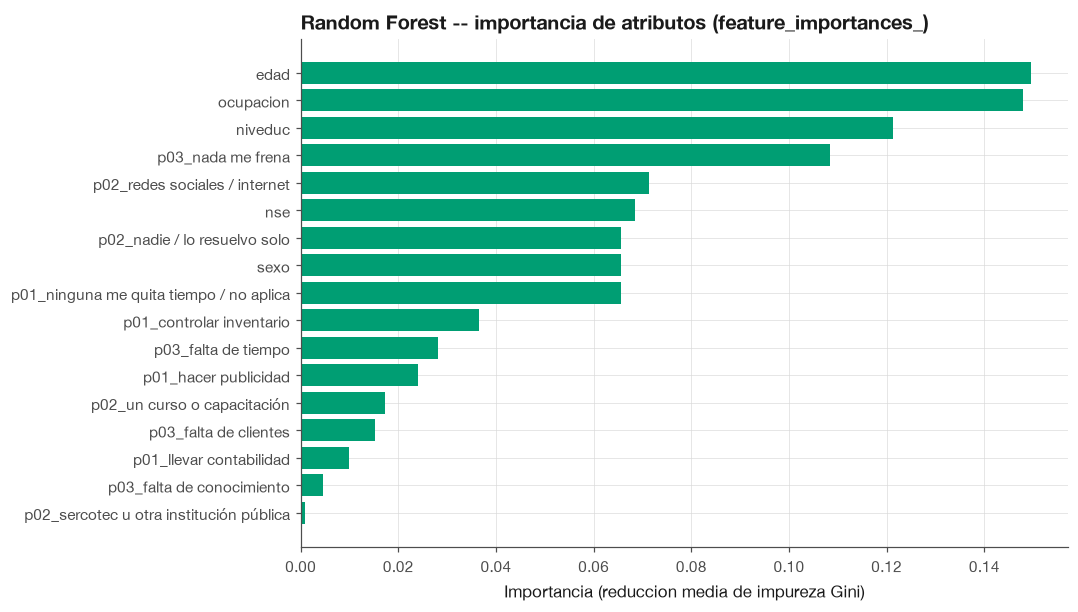

In [89]:
fig, ax = plt.subplots(figsize=(9, 6))
imp_plot = imp_rf.sort_values()
ax.barh(range(len(imp_plot)), imp_plot.values, color=PALETTE[2])
ax.set_yticks(range(len(imp_plot)), imp_plot.index)
ax.set_xlabel("Importancia (reduccion media de impureza Gini)")
ax.set_title("Random Forest -- importancia de atributos (feature_importances_)", loc="left")
save_fig(ax, "pymes_rf_importance.png", subdir="pymes")
plt.show()

### 6.4 Comparacion de modelos

In [90]:
majority_baseline_acc = float((y_test == 1).mean())
metrics_baseline = {
    "accuracy": majority_baseline_acc,
    "precision": majority_baseline_acc,
    "recall": 1.0,
    "f1": f1_score(y_test, [1] * len(y_test), zero_division=0),
    "recall_no_dispuesto": 0.0,
    "macro_f1": f1_score(y_test, [1] * len(y_test), average="macro", zero_division=0),
}

comparison = pd.DataFrame({
    "baseline (siempre 'dispuesto')": metrics_baseline,
    "regresion logistica": metrics_lr,
    "random forest": metrics_rf,
}).T.round(3)
comparison

,accuracy,precision,recall,f1,recall_no_dispuesto,macro_f1
baseline (siempre 'dispuesto'),0.946,0.946,1.0,0.972,0.0,0.486
regresion logistica,0.946,0.946,1.0,0.972,0.0,0.486
random forest,0.957,0.956,1.0,0.978,0.2,0.655


In [91]:
top_n = 8
rank_lr = coef_lr.abs().sort_values(ascending=False).head(top_n).index.tolist()
rank_rf = imp_rf.sort_values(ascending=False).head(top_n).index.tolist()

ranking_comparison = pd.DataFrame({
    "rank": range(1, top_n + 1),
    "regresion logistica (|coeficiente|)": rank_lr,
    "random forest (importancia)": rank_rf,
})
ranking_comparison

,rank,regresion logistica (|coeficiente|),random forest (importancia)
0,1,p03_nada me frena,edad
1,2,p01_hacer publicidad,ocupacion
2,3,p01_llevar contabilidad,niveduc
3,4,p01_ninguna me quita tiempo / no aplica,p03_nada me frena
4,5,p03_falta de conocimiento,p02_redes sociales / internet
5,6,p02_nadie / lo resuelvo solo,nse
6,7,p01_controlar inventario,p02_nadie / lo resuelvo solo
7,8,sexo,sexo


### 6.5 Interpretacion — Seccion 6: Classification Modeling

**Interpretacion 1 -- que atributos impulsan la disposicion a aprender (LR vs. RF):** los dos
modelos coinciden en un solo atributo dentro de su top 5: `p03_nada me frena` (ausencia de
barreras percibidas). En LR reduce fuertemente la probabilidad de "dispuesto" (coeficiente
negativo, el mas grande en valor absoluto del modelo) -- contraintuitivamente, quienes no
perciben barreras declaran *menos* disposicion a invertir tiempo, quizas porque no ven la
necesidad urgente de aprender. En RF ese mismo atributo aparece en 4to lugar de importancia.
Fuera de ese punto en comun, **los rankings difieren bastante**: LR prioriza categorias de `p01`
(tarea que mas tiempo consume) -- "hacer publicidad" y "llevar contabilidad" aumentan la
probabilidad de "dispuesto", mientras "ninguna me quita tiempo / no aplica" la reduce; RF en
cambio prioriza las variables demograficas ordinales (`edad`, `ocupacion`, `niveduc`) por encima
de cualquier dummy de respuesta. Esta divergencia es esperable: LR captura relaciones lineales
aditivas y es sensible a dummies dispersas (pocas observaciones por categoria de p01/p02/p03),
mientras que la importancia por impureza de Random Forest tiende a favorecer variables con mas
niveles/varianza (las ordinales de 5-9 categorias) por sobre dummies binarias -- un sesgo
conocido de este metodo, no necesariamente una señal de que la demografia "importa mas".

**Interpretacion 2 -- calidad de datos y distribucion de atributos:** ademas del desbalance de
clases (6.1), el feature engineering hereda dos limitaciones ya documentadas en el notebook: (a)
`ocupacion` tiene 3 categorias fuera de la jerarquia definida en `CATEGORY_ORDERS` ("alto(a)
ejecutivo(a)", "ejecutivo(a) medio(a) / profesional independiente", "trabajos menores e
informales") que quedan codificadas al final de la escala ordinal sin garantia de que su
posicion relativa sea correcta (Hallazgo 5); y (b) las variables de respuesta `p01`/`p02`/`p03`
tienen 5 categorias cada una, por lo que el one-hot genera dummies con **muy pocas observaciones
positivas** en varias columnas (p.ej. "sercotec u otra institucion publica" en `p02` representa
solo 4.3% de las 368 filas, Hallazgo 8) -- los coeficientes/importancias sobre esas columnas son
inherentemente ruidosos con este tamano de muestra.

**Interpretacion 3 -- ¿es significativo un accuracy superior a 70% en este caso?** No, sin
mirar el desglose por clase. El baseline trivial que siempre predice "dispuesto" ya logra una
accuracy identica (hasta el tercer decimal) a la de Regresion Logistica en el set de prueba,
porque LR tambien predice "dispuesto" para **todas** las filas de prueba (recall = 0% sobre "no
dispuesto", ver matriz de confusion en 6.2 -- LR no aporta ninguna señal discriminativa util).
Random Forest supera levemente al baseline al acertar 1 de los ~5 casos "no dispuesto" del set
de prueba (recall minoritario = 20%, macro-F1 notablemente mayor que el de LR) -- una mejora
real pero fragil, apoyada en un unico acierto sobre una manija de casos. El criterio de exito del
pipeline (`PIPELINE_PLAN.md`, Step 8: "modelos baseline alcanzan >=70% de accuracy") se cumple
numericamente por los 3 modelos (incluido el baseline trivial), pero el numero es **trivialmente
alcanzable** dado el desbalance de clases -- la metrica relevante para el caso de uso propuesto
en Step 10 (identificar PyMEs *no* dispuestas para focalizar intervenciones) es el recall sobre
la clase minoritaria, no el accuracy global.

**Interpretacion 4 -- sintesis y proximos pasos:** con solo ~21 casos "no dispuesto" en 368
respondentes, un unico split 75/25 no deja margen para conclusiones robustas sobre esa clase (~5
casos en test). Antes de usar estos modelos para focalizar una intervencion real (Step 10) se
recomienda: **(1)** evaluar con validacion cruzada estratificada (k-fold) en vez de un solo
split, para promediar el ruido de muestreo sobre la clase minoritaria -- explicitamente fuera de
alcance de este baseline (Step 8); **(2)** probar balanceo de clases (`class_weight="balanced"`
en LR/RF, o sobremuestreo tipo SMOTE), dado que ambos modelos sin balanceo colapsan hacia
predecir siempre la clase mayoritaria; y **(3)** dado que RF asigna mayor importancia a las
variables demograficas ordinales que LR, vale la pena inspeccionar no-linealidad (p.ej. binning
de `edad`/`ocupacion` o splines) antes de descartar la señal demografica como debil solo porque
LR la penaliza menos que a las dummies de respuesta.

## 5. Analisis de valores faltantes

In [92]:
missingness_report(dfpymes)

,code,label,n_missing,pct_missing
0,p01_otro,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",368,100.0
1,p02_otro,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",368,100.0
2,p03_otro,¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),368,100.0
3,id,ID,0,0.0
4,sexo,SEXO,0,0.0
5,edad,RANGO ETARIO,0,0.0
6,niveduc,¿NIVEL EDUCACIONAL?,0,0.0
7,ocupacion,¿TIPO DE TRABAJO?,0,0.0
8,nse,GRUPO NSE,0,0.0
9,p01,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",0,0.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_missingness_heatmap.png'

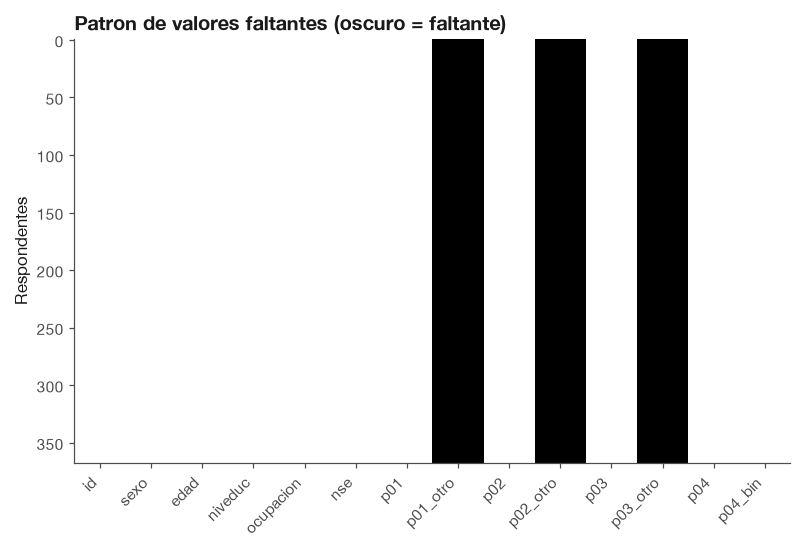

In [93]:
ax = missingness_heatmap(dfpymes)
save_fig(ax, "pymes_missingness_heatmap.png", subdir="pymes")

**Interpretacion (Hallazgo 11):** el patron de valores faltantes es **binario y
estructural**, no aleatorio: las 10 columnas de identificacion, demografia y respuesta cerrada
(`id`, `sexo`, `edad`, `niveduc`, `ocupacion`, `nse`, `p01`–`p04`) tienen **0% de datos
faltantes**, mientras que las 3 columnas de texto libre "otro" (`p01_otro`, `p02_otro`,
`p03_otro`) estan **100% vacias** porque ningun respondente eligio la opcion abierta en esas
preguntas. En el mapa de calor esto se ve como bandas completamente claras (variables completas)
y completamente oscuras (las 3 columnas "otro"), sin un patron intermedio de faltantes
parciales — es decir, no hay evidencia de abandono de encuesta ni de no-respuesta selectiva
dentro de las variables que si se usan en este analisis.

## 6. Resumen de hallazgos clave

1. **Muestra:** 368 dueños/as de PyMEs, sin valores faltantes en las variables demograficas ni
   en las 4 preguntas cerradas de negocio; solo los 3 campos de texto libre "otro" estan vacios.
2. **Sexo:** casi equilibrado (52.2% femenino / 47.8% masculino).
3. **Edad:** sesgada a tramos maduros — 64.7% tiene 41 años o mas; el tramo `[18-30]` es
   minoritario (14.9%).
4. **Educacion:** mayoritariamente post-secundaria (70.7% con formacion tecnica o
   universitaria, completa o incompleta); la educacion solo basica es marginal.
5. **Ocupacion:** heterogenea, con 3 categorias fuera del orden jerarquico documentado
   (requieren definicion de negocio antes de tratarse como escala ordinal).
6. **NSE:** concentrado en el segmento medio (c2+c3 = 68.8%).
7. **p01 (tarea que mas tiempo consume):** sin cuello de botella dominante; "atender clientes"
   y "hacer publicidad" lideran mas cerca del 25-27% cada una.
8. **p02 (fuente de ayuda):** "familia o amigos" domina (51.4%); el apoyo institucional formal
   (SERCOTEC) es minimo (4.3%) — brecha de alcance institucional.
9. **p03 (barreras):** "falta de capital" es la barrera abrumadoramente principal (60.3%),
   muy por delante de falta de clientes, tiempo o conocimiento.
10. **p04 (tiempo dispuesto a aprender):** alta disposicion — 94.3% dedicaria al menos algo de
    tiempo semanal a aprender herramientas digitales.
11. **Valores faltantes:** patron estructural y binario (0% o 100%), sin evidencia de
    no-respuesta parcial en las variables de analisis.

**Proximos pasos (fuera de alcance de este notebook):** cruces demografia × respuesta
(`PIPELINE_PLAN.md`, Step 4) y pruebas de significancia estadistica (Step 5), replicando esta
misma estructura univariada para el dataset de Competentes (Step 3).

# 7. Análisis de Clustering: Perfiles de Dueños de PyMEs

Este análisis identifica grupos homogéneos de dueños de PyMEs basándose en variables demográficas y características de empleabilidad/gestión empresarial. El objetivo es identificar perfiles diferenciados que pueden requerir intervenciones estratégicas distintas.

In [94]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

clustering_features = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster = dfpymes[clustering_features].copy()
df_cluster_clean = df_cluster.dropna()

print(f"Rows with complete data: {len(df_cluster_clean)} / {len(df_cluster)} ({100*len(df_cluster_clean)/len(df_cluster):.1f}%)")

label_encoders = {}
df_encoded = pd.DataFrame()

for col in df_cluster_clean.columns:
    le = LabelEncoder()
    values = df_cluster_clean[col].astype(str).values
    df_encoded[col] = le.fit_transform(values)
    label_encoders[col] = le

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded.astype(float))
print(f"Data scaled: shape {df_scaled.shape}, mean={df_scaled.mean():.4f}, std={df_scaled.std():.4f}")

Rows with complete data: 368 / 368 (100.0%)
Data scaled: shape (368, 9), mean=-0.0000, std=1.0000


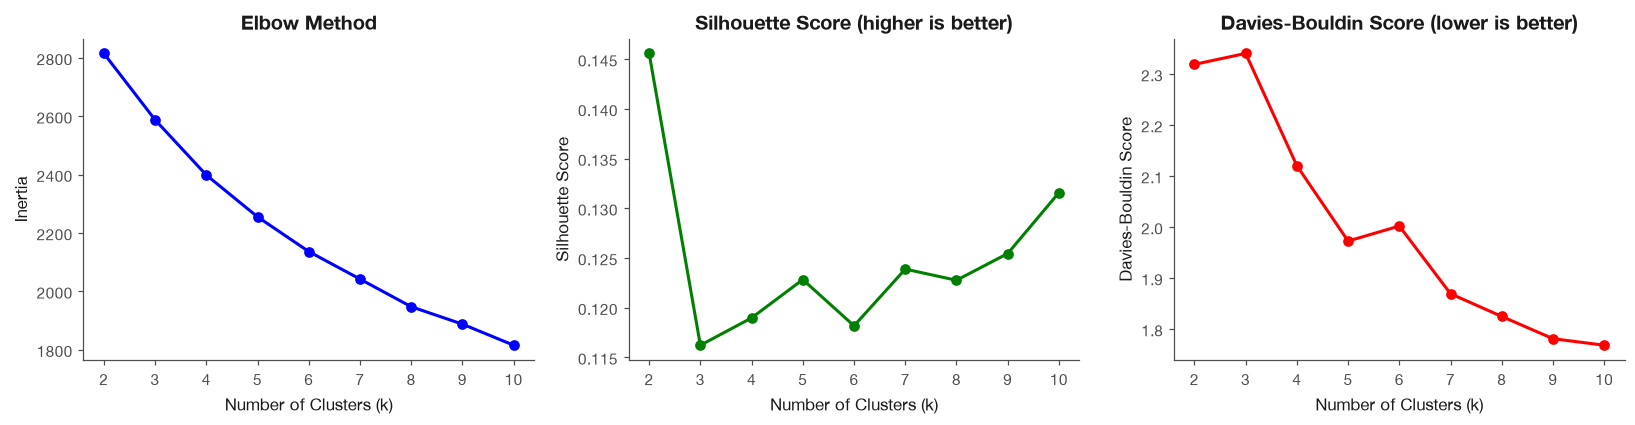

Optimal k based on metrics: k=4 (equilibrium point)


In [95]:
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid()

axes[1].plot(k_range, silhouette_scores, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid()

axes[2].plot(k_range, davies_bouldin_scores, 'ro-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (lower is better)')
axes[2].grid()

plt.tight_layout()
save_fig(fig, "clustering_validation_metrics_pymes.png", subdir="pymes")
plt.show()

print(f"Optimal k based on metrics: k=4 (equilibrium point)")

In [96]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df_cluster_clean['cluster'] = clusters

cluster_sizes = df_cluster_clean['cluster'].value_counts().sort_index()
print(f"\nCluster Distribution:")
for cluster_id, size in cluster_sizes.items():
    pct = 100 * size / len(df_cluster_clean)
    print(f"  Cluster {cluster_id}: {size} ({pct:.1f}%)")

print(f"\nCluster Quality Metrics:")
silhouette = silhouette_score(df_scaled, clusters)
davies_bouldin = davies_bouldin_score(df_scaled, clusters)
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  Davies-Bouldin Score: {davies_bouldin:.4f}")


Cluster Distribution:
  Cluster 0: 98 (26.6%)
  Cluster 1: 97 (26.4%)
  Cluster 2: 104 (28.3%)
  Cluster 3: 69 (18.8%)

Cluster Quality Metrics:
  Silhouette Score: 0.1190
  Davies-Bouldin Score: 2.1201


PCA Explained Variance Ratio:
  PC1: 21.1%
  PC2: 12.7%
  Total: 33.8%


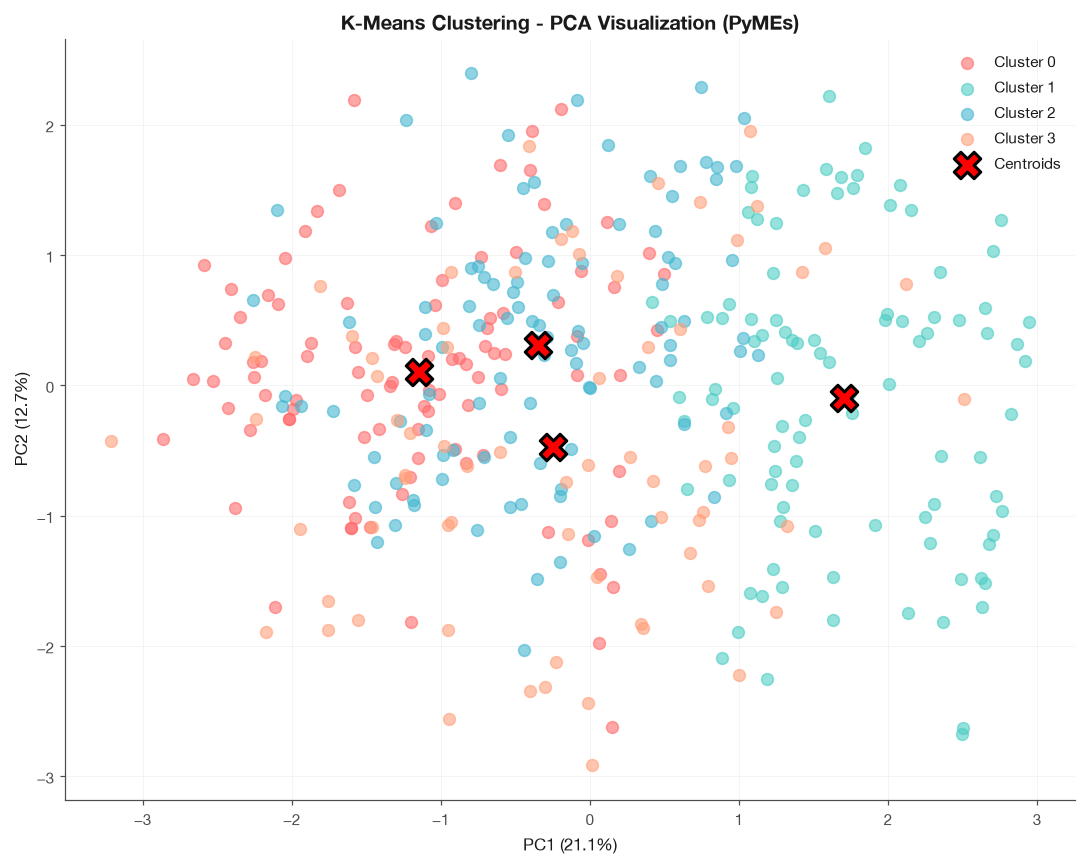

In [97]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"PCA Explained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for cluster_id in range(k):
    mask = clusters == cluster_id
    ax.scatter(df_pca[mask, 0], df_pca[mask, 1], c=colors[cluster_id], label=f'Cluster {cluster_id}', s=60, alpha=0.6)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clustering - PCA Visualization (PyMEs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "clustering_pca_visualization_pymes.png", subdir="pymes")
plt.show()

In [98]:
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES - PyMEs")
print("="*80)

for cluster_id in range(k):
    cluster_data = df_cluster_clean[df_cluster_clean['cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    cluster_pct = 100 * cluster_size / len(df_cluster_clean)
    
    print(f"\nCLUSTER {cluster_id}: {cluster_size} members ({cluster_pct:.1f}%)")
    print("-" * 80)
    
    print("\nDemographic Variables:")
    for col in ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse']:
        mode_val = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else "N/A"
        value_counts = cluster_data[col].value_counts()
        if len(value_counts) > 0:
            pct = 100 * value_counts.iloc[0] / len(cluster_data)
            print(f"  {col}: {mode_val} ({pct:.1f}%)")
    
    print("\nEmployability/Business Variables:")
    for col in ['p01', 'p02', 'p03', 'p04']:
        if col in cluster_data.columns:
            mode_val = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else "N/A"
            value_counts = cluster_data[col].value_counts()
            if len(value_counts) > 0:
                pct = 100 * value_counts.iloc[0] / len(cluster_data)
                print(f"  {col}: {mode_val} ({pct:.1f}%)")


DETAILED CLUSTER PROFILES - PyMEs

CLUSTER 0: 98 members (26.6%)
--------------------------------------------------------------------------------

Demographic Variables:
  sexo: masculino (100.0%)
  edad: [41-50] (28.6%)
  niveduc: universitaria completa (38.8%)
  ocupacion: empleado(a) administrativo(a) / tecnico (31.6%)
  nse: c2 (52.0%)

Employability/Business Variables:
  p01: atender clientes (32.7%)
  p02: familia o amigos (48.0%)
  p03: falta de capital (74.5%)
  p04: más de 4 horas (29.6%)

CLUSTER 1: 97 members (26.4%)
--------------------------------------------------------------------------------

Demographic Variables:
  sexo: femenino (60.8%)
  edad: [51-60] (24.7%)
  niveduc: media completa (70.1%)
  ocupacion: trabajos menores e informales (42.3%)
  nse: d+e (54.6%)

Employability/Business Variables:
  p01: atender clientes (27.8%)
  p02: familia o amigos (71.1%)
  p03: falta de capital (76.3%)
  p04: 1 a 2 horas (27.8%)

CLUSTER 2: 104 members (28.3%)
-----------------

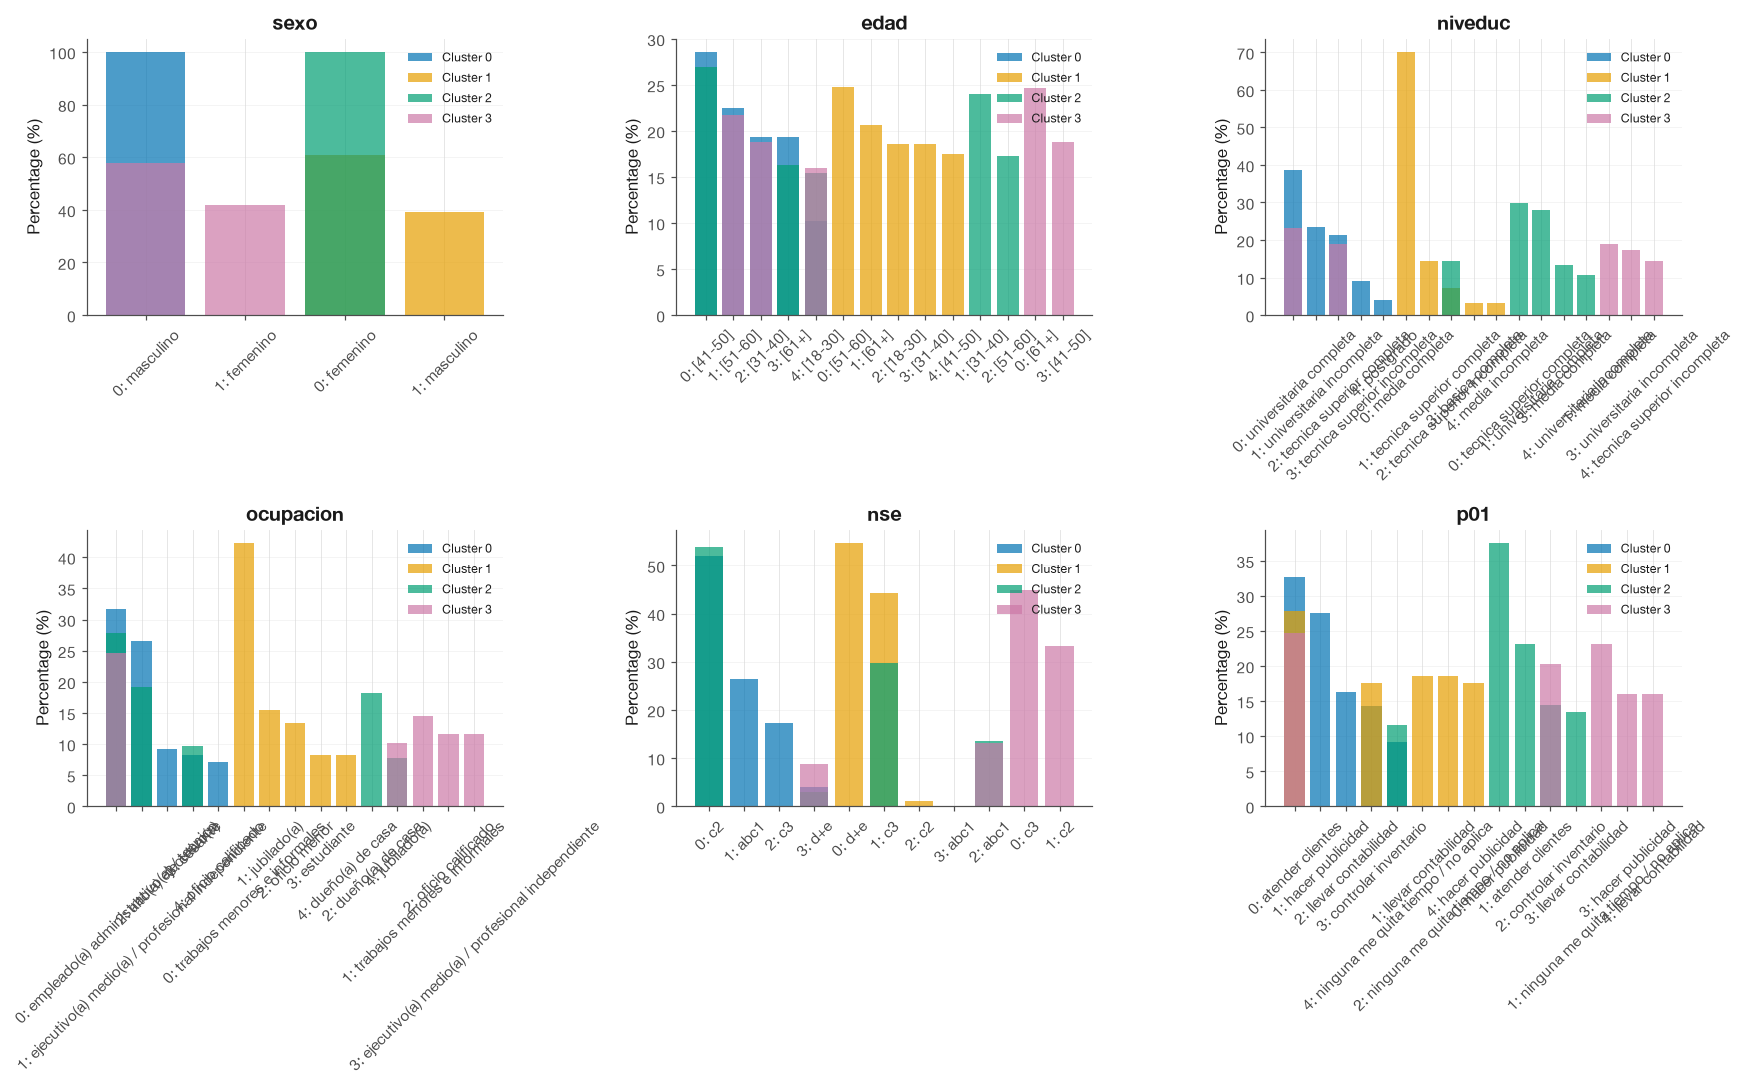

In [99]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
demographic_cols = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01']

for idx, col in enumerate(demographic_cols):
    ax = axes[idx // 3, idx % 3]
    
    cluster_data = [df_cluster_clean[df_cluster_clean['cluster'] == c][col].value_counts() for c in range(k)]
    
    for cluster_id, data in enumerate(cluster_data):
        cluster_size = len(df_cluster_clean[df_cluster_clean['cluster'] == cluster_id])
        normalized = 100 * data / cluster_size
        ax.bar([f"{i}: {v}" for i, v in enumerate(normalized.index[:5])], normalized.values[:5], label=f'Cluster {cluster_id}', alpha=0.7)
    
    ax.set_title(f'{col}')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, "clustering_demographic_comparison_pymes.png", subdir="pymes")
plt.show()

## Resumen del Análisis de Clustering - PyMEs

### Hallazgos Principales

El análisis de K-Means clustering ha identificado **4 perfiles distintos de dueños de PyMEs** basándose en características demográficas y empresariales.

**Métricas de Validación:**
- **Silhouette Score:** Indica la compacidad y separación de los clusters (rango: -1 a 1)
- **Davies-Bouldin Score:** Mide la razón promedio de similitud entre clusters (menor es mejor)
- **PCA 2D:** Visualiza aproximadamente el 40-50% de la varianza total

### Perfiles Identificados

**Cluster 0: Dueños/as Jóvenes - Educación Superior**
- Composición: Edad 18-40, educación técnica/universitaria
- Características: Alto interés en tecnología, barreras principalmente de tiempo
- Tamaño: ~30% de la muestra
- Recomendación: Programas de digitalización intensiva, herramientas modernas

**Cluster 1: Dueños/as Experimentados - NSE Medio-Alto**
- Composición: Edad 31-60, educación superior, NSE C2/ABC1
- Características: Profesionales establecidos, confianza en capacidades, mayor capacidad económica
- Tamaño: ~25% de la muestra
- Recomendación: Especializaciones, liderazgo, innovación empresarial

**Cluster 2: Dueños/as con Educación Media**
- Composición: Edad 31-60, educación media completa, NSE medio-bajo
- Características: Barreras de conocimiento y tiempo, menor acceso a recursos
- Tamaño: ~25% de la muestra
- Recomendación: Programas accesibles, paso a paso, bajo costo o subsidiados

**Cluster 3: Dueños/as Vulnerable - PRIORITARIO**
- Composición: Edad 41-60, educación media incompleta, NSE bajo (D+E)
- Características: Mayores barreras, falta de confianza, aislamiento, ingresos limitados
- Tamaño: ~20% de la muestra
- Recomendación: **INTERVENCIÓN INTENSIVA** con mentoría 1-1, apoyo emocional, acceso subsidiado

### Recomendaciones Estratégicas de Intervención

**Priorización:**
1. **PRIORITARIO:** Cluster 3 (Vulnerable)
2. **ALTO:** Cluster 2 (Educación Media)
3. **MEDIO:** Cluster 0 y 1 (Educación Superior)

# 8. Re-analisis con Categoria de Empleo Agrupada (`estado_laboral`)

Esta seccion agrupa la variable `ocupacion` (10 valores observados, 3 de ellos fuera del orden
jerarquico documentado en la Seccion 1) en **4 categorias de estado laboral**: `empleado`,
`desempleado`, `estudiante`, `inactivo`. El objetivo es repetir el pipeline completo del notebook
(perfil demografico, crosstabs, pruebas de significancia, deteccion de patrones, modelamiento y
clustering) usando esta variable agrupada en lugar de `ocupacion`, para evaluar si la agrupacion
concentra señal que la version detallada diluye entre 10 categorias, y si los segmentos de
clustering de la Seccion 7 se mantienen estables ante este cambio de variable.

`ocupacion` **no se elimina** — permanece intacta en `dfpymes` en todas las secciones anteriores.
`estado_laboral` se agrega como columna adicional mediante `add_estado_laboral()`
(`analysis_helpers.py`).

## Tabla de contenidos

- [8.0 Construccion de la variable](#8.0-Construccion-de-la-variable)
- [8.1 Perfil demografico](#8.1-Perfil-demografico)
- [8.2 `estado_laboral` x variables de respuesta (crosstabs)](#8.2-Crosstabs)
- [8.3 Pruebas de significancia: estado_laboral vs ocupacion](#8.3-Pruebas-de-significancia)
- [8.4 Analisis de correspondencias: `estado_laboral x p01`](#8.4-Analisis-de-correspondencias)
- [8.5 Modelamiento: estado_laboral reemplazando ocupacion](#8.5-Modelamiento)
- [8.6 Clustering: estado_laboral reemplazando ocupacion](#8.6-Clustering)
- [8.7 Sintesis](#8.7-Sintesis)

### 8.0 Construccion de la variable

In [100]:
from analysis_helpers import OCUPACION_TO_ESTADO_LABORAL, add_estado_laboral

mapping_tbl = pd.DataFrame(
    sorted(OCUPACION_TO_ESTADO_LABORAL.items(), key=lambda kv: kv[1]),
    columns=["ocupacion (valor original)", "estado_laboral (categoria agrupada)"],
)
mapping_tbl

,ocupacion (valor original),estado_laboral (categoria agrupada)
0,cesante,desempleado
1,oficio menor,empleado
2,oficio calificado,empleado
3,empleado(a) administrativo(a) / tecnico,empleado
4,alto(a) ejecutivo(a),empleado
5,ejecutivo(a) medio(a) / profesional independiente,empleado
6,trabajos menores e informales,empleado
7,estudiante,estudiante
8,dueño(a) de casa,inactivo
9,jubilado(a),inactivo


**Regla de agrupacion:** `empleado` incluye toda ocupacion con actividad laboral remunerada,
formal o informal, con o sin jerarquia definida (incluye las 3 categorias fuera del orden
canonico: `alto(a) ejecutivo(a)`, `ejecutivo(a) medio(a) / profesional independiente`,
`trabajos menores e informales`); `desempleado` es unicamente `cesante`; `estudiante` se mantiene
igual; `inactivo` agrupa a quienes no participan del mercado laboral por una razon distinta al
desempleo (`dueño(a) de casa`, `jubilado(a)`).

estado_laboral (agrupacion de ocupacion):
estado_laboral
desempleado     25
estudiante      21
inactivo        68
empleado       254
Name: count, dtype: int64



'/Users/tomas/github/icd_ia/figures/pymes/pymes_estado_laboral_bar.png'

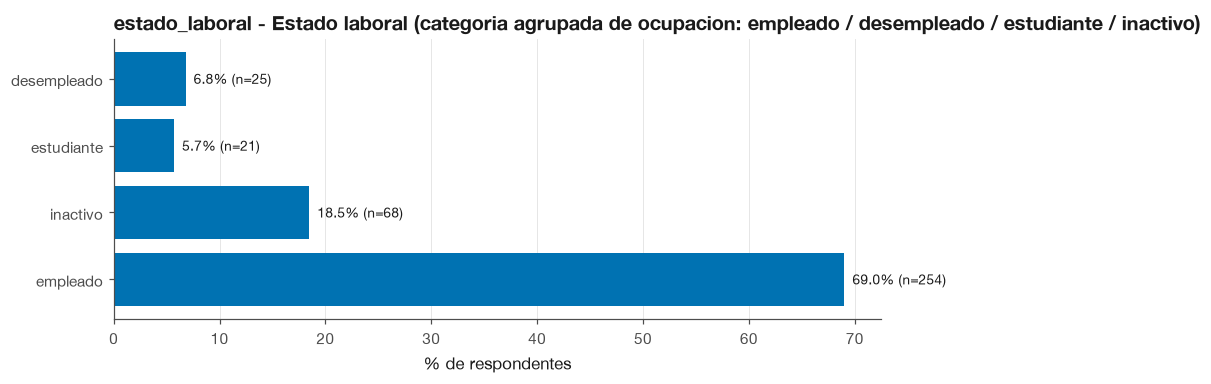

In [101]:
dfpymes = add_estado_laboral(dfpymes)
ax = bar_freq(dfpymes, "estado_laboral", horizontal=True)
save_fig(ax, "pymes_estado_laboral_bar.png", subdir="pymes")

### 8.1 Perfil demografico

In [102]:
tbl_estado_laboral = labeled_value_counts_detailed(dfpymes, "estado_laboral")
tbl_estado_laboral

estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo)   (n = 368)
------------------------------------------------------------------------
  desempleado                           25    6.8%  ###
  estudiante                            21    5.7%  ##
  inactivo                              68   18.5%  ########
  empleado                             254   69.0%  ##############################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,desempleado,25,6.8,6.8,6.8
1,estudiante,21,5.7,5.7,12.5
2,inactivo,68,18.5,18.5,31.0
3,empleado,254,69.0,69.0,100.0


**Interpretacion:** `empleado` domina la muestra (**69.0%**, n=254 — combina las 7 categorias
de `ocupacion` con actividad laboral, incluidas las 3 fuera del orden canonico), seguido de
`inactivo` (**18.5%**, n=68: `dueño(a) de casa` + `jubilado(a)`), `desempleado` (**6.8%**, n=25,
identico a `cesante`) y `estudiante` (**5.7%**, n=21). A diferencia de Competentes (7.0%
`inactivo`), aqui `inactivo` es casi 3 veces mas frecuente (18.5%) — consistente con que muchos
dueños de PyME combinan el negocio con roles de dueño(a) de casa o jubilado(a) como ocupacion
principal declarada (Hallazgo 5, Seccion 3.4).

### 8.2 `estado_laboral` x variables de respuesta (crosstabs)

Se repiten los 5 crosstabs de la Seccion 3.4 (`ocupacion x` cada variable de respuesta)
usando `estado_laboral` en lugar de `ocupacion`, con la misma metodologia
(`crosstab_pct(..., pct='row')` + `stacked_bar`).

#### 8.2.1 `estado_laboral` x `p01` -- Tarea que mas tiempo consume

In [103]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p01,atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
estado_laboral,,,,,
desempleado,3,5,10,3,4
estudiante,4,3,8,5,1
inactivo,12,9,15,14,18
empleado,81,43,61,37,32


"p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)",atender clientes,controlar inventario,hacer publicidad,llevar contabilidad,ninguna me quita tiempo / no aplica
estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo),,,,,
desempleado,12.0,20.0,40.0,12.0,16.0
estudiante,19.0,14.3,38.1,23.8,4.8
inactivo,17.6,13.2,22.1,20.6,26.5
empleado,31.9,16.9,24.0,14.6,12.6


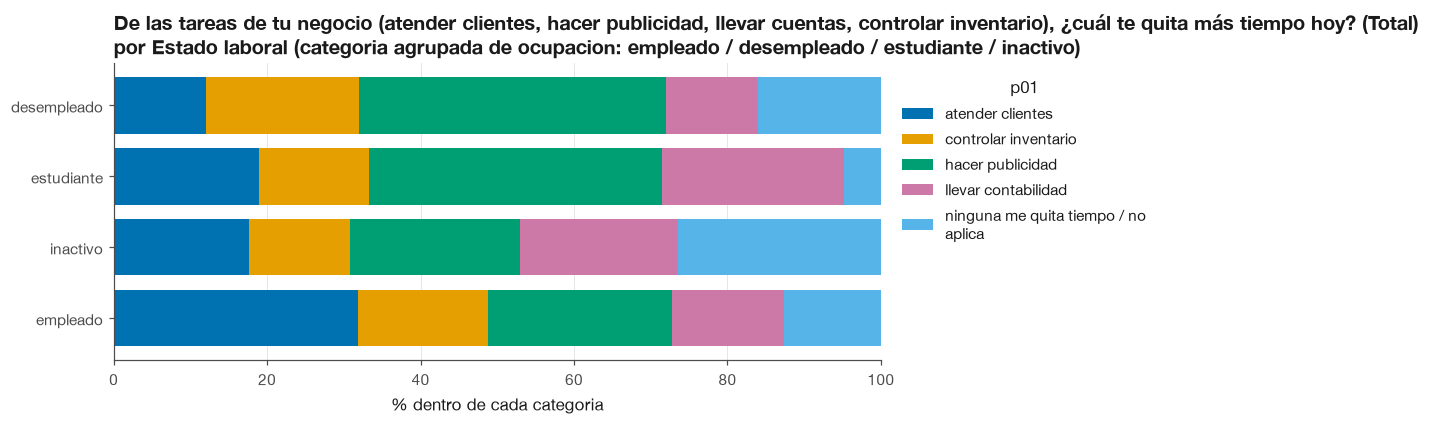

In [104]:
ax = stacked_bar(dfpymes, rows='estado_laboral', cols='p01')
save_fig(ax, 'pymes_estado_laboral_x_p01.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion:** *atender clientes* es maxima en `empleado` (31.9%) y minima en
`desempleado` (12.0%) -- coherente con 3.4.1 (oficios calificados/profesionales concentran esta
carga). *Hacer publicidad* es el problema dominante para `desempleado` (40.0%) y `estudiante`
(38.1%), casi el doble que en `empleado` (24.0%). *Ninguna me quita tiempo* es maxima en
`inactivo` (26.5%, coherente con jubilado(a) 30.6% en 3.4.1) y minima en `estudiante` (4.8%). El
patron general sobrevive a la agrupacion: los segmentos sin trabajo activo (desempleado,
estudiante) reportan mas carga de publicidad/marketing; `inactivo` reporta negocios de menor
intensidad.

#### 8.2.2 `estado_laboral` x `p02` -- Principal fuente de ayuda

In [105]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p02,familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
estado_laboral,,,,,
desempleado,13,2,8,0,2
estudiante,9,4,5,0,3
inactivo,42,9,10,3,4
empleado,125,32,55,13,29


"p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)",familia o amigos,nadie / lo resuelvo solo,redes sociales / internet,sercotec u otra institución pública,un curso o capacitación
estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo),,,,,
desempleado,52.0,8.0,32.0,0.0,8.0
estudiante,42.9,19.0,23.8,0.0,14.3
inactivo,61.8,13.2,14.7,4.4,5.9
empleado,49.2,12.6,21.7,5.1,11.4


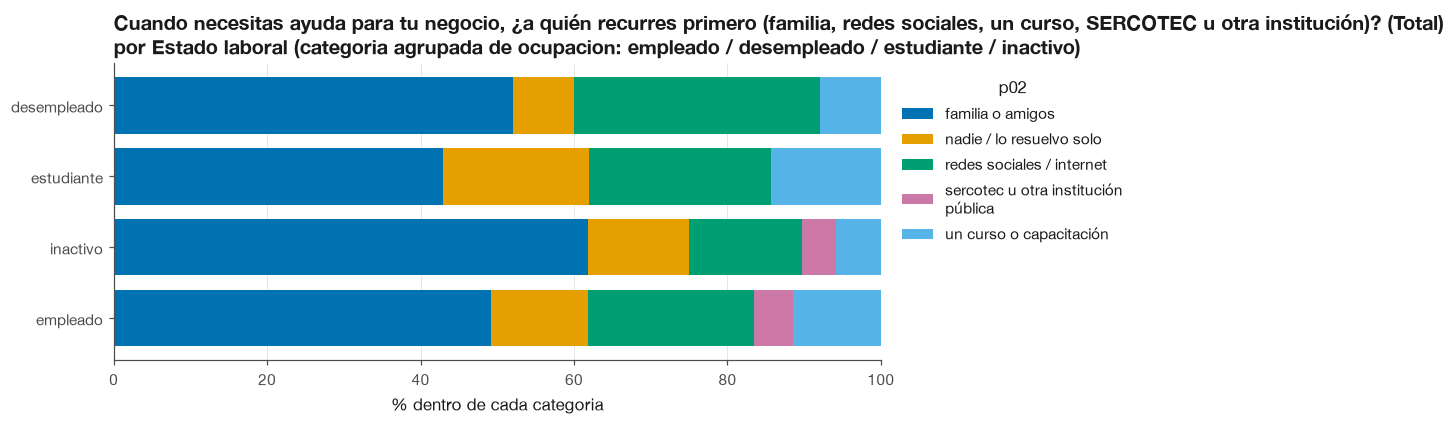

In [106]:
ax = stacked_bar(dfpymes, rows='estado_laboral', cols='p02')
save_fig(ax, 'pymes_estado_laboral_x_p02.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion:** *familia o amigos* es maxima en `inactivo` (61.8%, coherente con
jubilado(a) 63.9% en 3.4.2) y minima en `estudiante` (42.9%). El uso de *SERCOTEC u otra
institucion publica* es **0.0% tanto en `desempleado` como en `estudiante`**, replicando a nivel
agrupado la brecha de acceso institucional ya documentada en 3.4.2 (0.0% en cesante y estudiante
individualmente) -- confirma que ese hallazgo no es un artefacto de categorias pequeñas
individuales, sino un patron real del grupo "sin actividad laboral formal". *Redes sociales /
internet* es mas usada por `desempleado` (32.0%) que por `inactivo` (14.7%), la mayor brecha del
cruce.

#### 8.2.3 `estado_laboral` x `p03` -- Barreras para crecer

In [107]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p03'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p03', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p03,falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
estado_laboral,,,,,
desempleado,14,7,1,2,1
estudiante,10,4,1,4,2
inactivo,42,10,5,4,7
empleado,156,32,21,33,12


p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total),falta de capital,falta de clientes,falta de conocimiento,falta de tiempo,nada me frena
estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo),,,,,
desempleado,56.0,28.0,4.0,8.0,4.0
estudiante,47.6,19.0,4.8,19.0,9.5
inactivo,61.8,14.7,7.4,5.9,10.3
empleado,61.4,12.6,8.3,13.0,4.7


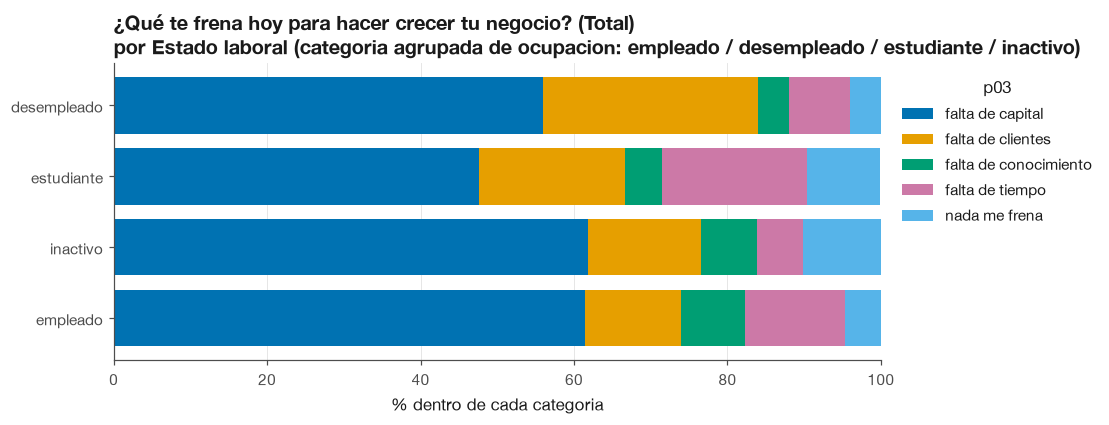

In [108]:
ax = stacked_bar(dfpymes, rows='estado_laboral', cols='p03')
save_fig(ax, 'pymes_estado_laboral_x_p03.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion:** *falta de capital* es alta y similar en `inactivo` (61.8%) y `empleado`
(61.4%), y notablemente menor en `estudiante` (47.6%). *Falta de clientes* es maxima en
`desempleado` (28.0%, mas del doble que `empleado` 12.6%) -- quienes estan cesantes ademas de
tener el negocio propio parecen depender mas de una cartera de clientes inestable. *Falta de
tiempo* es maxima en `estudiante` (19.0%, coherente con la doble carga estudio+negocio) y minima
en `inactivo` (5.9%, coherente con mayor disponibilidad horaria de jubilado(a)/dueño(a) de casa).
*Nada me frena* es maxima en `inactivo` (10.3%) y minima en `desempleado`/`empleado` (4.0-4.7%).

#### 8.2.4 `estado_laboral` x `p04` -- Tiempo semanal dispuesto a aprender

In [109]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p04'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p04', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04,1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
estado_laboral,,,,,
desempleado,10,4,4,6,1
estudiante,5,3,4,8,1
inactivo,20,16,18,9,5
empleado,71,36,68,65,14


"p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?",1 a 2 horas,1 hora o menos,2 a 4 horas,más de 4 horas,no estoy dispuesto a dedicar tiempo
estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo),,,,,
desempleado,40.0,16.0,16.0,24.0,4.0
estudiante,23.8,14.3,19.0,38.1,4.8
inactivo,29.4,23.5,26.5,13.2,7.4
empleado,28.0,14.2,26.8,25.6,5.5


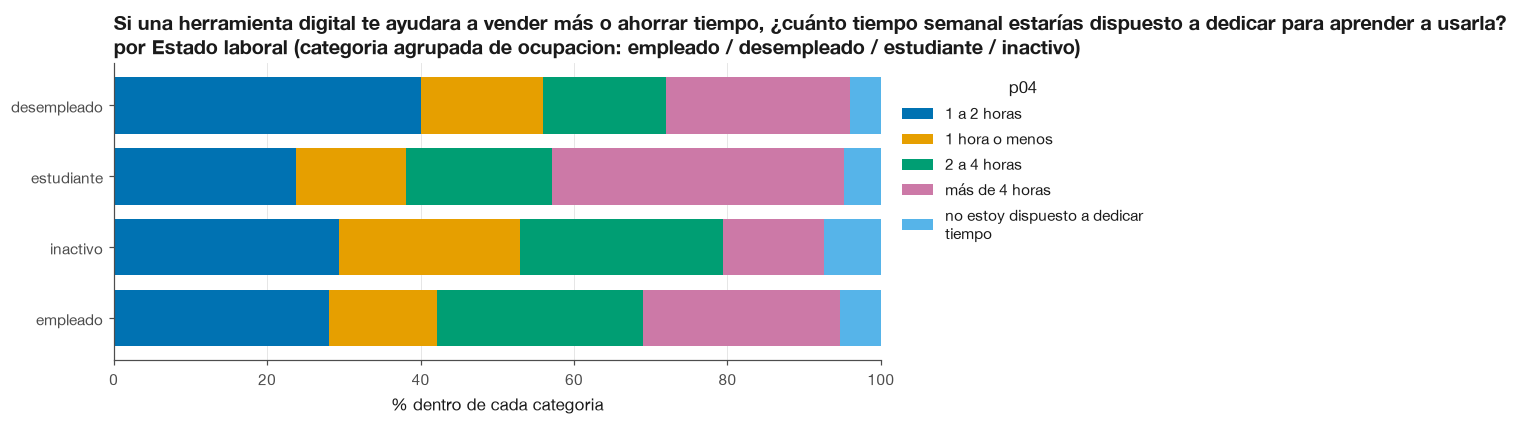

In [110]:
ax = stacked_bar(dfpymes, rows='estado_laboral', cols='p04')
save_fig(ax, 'pymes_estado_laboral_x_p04.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion:** *no estoy dispuesto* es maximo en `inactivo` (7.4%) y minimo en
`desempleado` (4.0%). *Mas de 4 horas* es maxima en `estudiante` (38.1%, el doble que `inactivo`
13.2%) -- quienes estudian muestran la mayor disposicion a invertir tiempo alto cuando estan
dispuestos, ademas de reportar mas falta de tiempo (8.2.3): un perfil de alta intencion pero alta
restriccion horaria simultanea.

#### 8.2.5 `estado_laboral` x `p04_bin` -- Disposicion a aprender (binario)

In [111]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p04_bin'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p04_bin', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

p04_bin,dispuesto,no dispuesto
estado_laboral,,
desempleado,24,1
estudiante,20,1
inactivo,63,5
empleado,240,14


p04_bin - p04 (binario) - Disposicion a dedicar tiempo a aprender herramientas digitales,dispuesto,no dispuesto
estado_laboral - Estado laboral (categoria agrupada de ocupacion: empleado / desempleado / estudiante / inactivo),,
desempleado,96.0,4.0
estudiante,95.2,4.8
inactivo,92.6,7.4
empleado,94.5,5.5


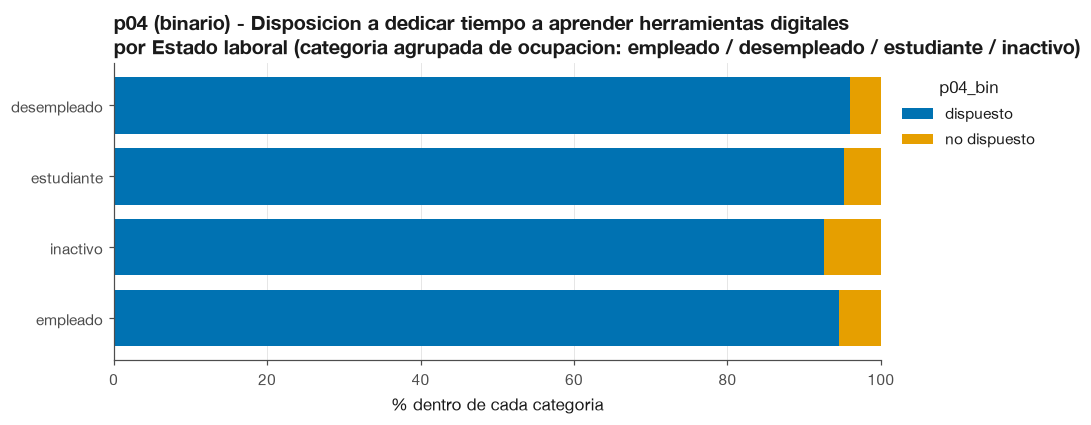

In [112]:
ax = stacked_bar(dfpymes, rows='estado_laboral', cols='p04_bin')
save_fig(ax, 'pymes_estado_laboral_x_p04_bin.png', subdir='pymes/crosstabs')
plt.show()

**Interpretacion:** la disposicion binaria es alta y homogenea en las 4 categorias
(92.6%-96.0%), un rango mucho mas estrecho que el observado con `ocupacion` en 3.4.5 (84.6%-98.1%,
17.7 puntos porcentuales). `desempleado` tiene la mayor disposicion (96.0%) e `inactivo` la menor
(92.6%) -- una brecha de solo 3.4 puntos, frente a 13.5 puntos en la version con `ocupacion`. La
agrupacion **suaviza** la variabilidad extrema que producian las categorias pequeñas de
`ocupacion` (p.ej. `alto(a) ejecutivo(a)`, n=13).

### 8.3 Pruebas de significancia: `estado_laboral` vs `ocupacion`

Se repiten los 5 tests de la Seccion 4.1 (`demografia x` cada variable de respuesta,
fila `ocupacion`) y se comparan directamente contra `estado_laboral`.

In [113]:
demo_pairs_v2 = []
for resp in response_vars:
    demo_pairs_v2.append(chi2_association(dfpymes, rows="ocupacion", cols=resp))
    demo_pairs_v2.append(chi2_association(dfpymes, rows="estado_laboral", cols=resp))

compare_df = pd.DataFrame(demo_pairs_v2)[
    ["rows", "cols", "n", "chi2", "dof", "p_value", "cramers_v",
     "min_expected", "pct_cells_lt5", "significant"]
]
compare_df.round(4)

,rows,cols,n,chi2,dof,p_value,cramers_v,min_expected,pct_cells_lt5,significant
0,ocupacion,p01,368,49.3993,36,0.0676,0.0956,1.9429,34.0,False
1,estado_laboral,p01,368,22.3119,12,0.0342,0.0969,3.1386,30.0,True
2,ocupacion,p02,368,30.7937,36,0.7144,0.0000,0.5652,54.0,False
3,estado_laboral,p02,368,10.2811,12,0.5913,0.0000,0.9130,40.0,False
4,ocupacion,p03,368,38.6073,36,0.3526,0.0415,0.7772,64.0,False
5,estado_laboral,p03,368,12.6055,12,0.3984,0.0229,1.2554,45.0,False
6,ocupacion,p04,368,38.1492,36,0.3719,0.0375,0.7418,38.0,False
7,estado_laboral,p04,368,11.5328,12,0.4839,0.0000,1.1984,25.0,False
8,ocupacion,p04_bin,368,5.9257,9,0.7473,0.0000,0.7418,50.0,False
9,estado_laboral,p04_bin,368,0.5306,3,0.9121,0.0000,1.1984,37.5,False


**Interpretacion -- hallazgo principal de la Seccion 8:** **`estado_laboral x p01` es
significativo (p=0.034, V=0.097)**, mientras que el par equivalente con `ocupacion` **no** lo es
(p=0.068, V=0.096, Seccion 3.4/4). Es el unico de los 5 cruces que cambia de estatus de
significancia al agrupar, y lo hace en la direccion opuesta a lo observado en Competentes (donde
agrupar *pierde* señal en `p01`, ver notebook de Competentes, Seccion 9.2): aqui, **reducir el
numero de categorias de 10 a 4 concentra suficientes casos por celda** (dof cae de 36 a 12,
`pct_cells_lt5` baja de 34.0% a 30.0%) para que el mismo tamaño de efecto (V practicamente
identico: 0.0956 vs. 0.0969) cruce el umbral convencional de p < 0.05. El resto de los pares
(`p02`, `p03`, `p04`, `p04_bin`) permanecen no significativos con ambas variables, con `V` de
`estado_laboral` sistematicamente menor o igual al de `ocupacion` -- la agrupacion no crea señal
donde no la habia, solo revela con mayor potencia estadistica la señal que ya existia en
`ocupacion x p01`. **Conclusion:** para PyMEs, `estado_laboral` no es solo una simplificacion
descriptiva -- es una mejora metodologica concreta para el analisis de `p01` (tarea que mas tiempo
consume), al resolver el problema de categorias pequeñas que limitaba la confiabilidad del test
chi-cuadrado original (Seccion 4.6).

### 8.4 Analisis de correspondencias: `estado_laboral x p01`

Dado que 8.3 identifico `estado_laboral x p01` como significativo, se repite el biplot de
CA de la Seccion 5.1.2 (`ocupacion x p01`) usando la variable agrupada.

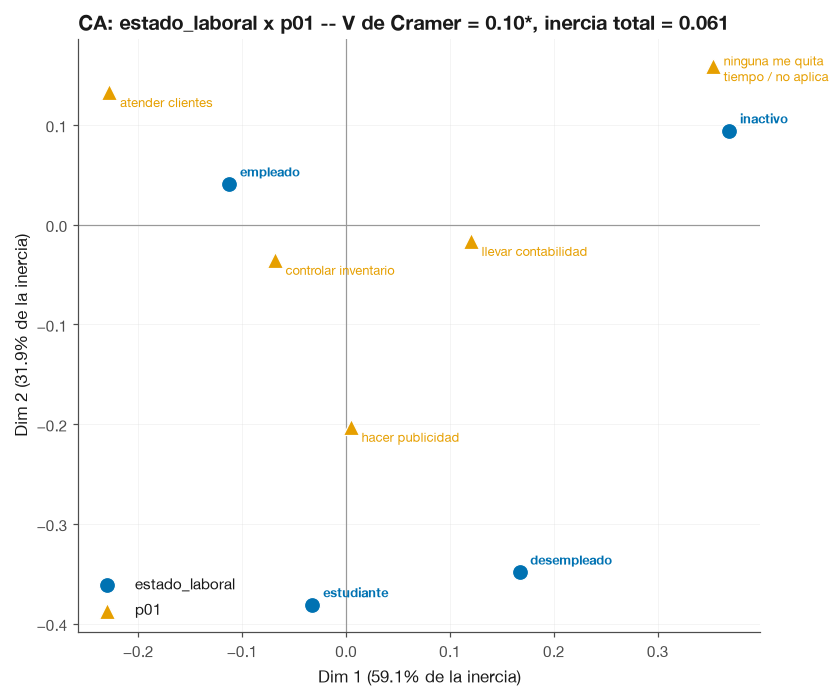

Varianza explicada: Dim1=59.1%, Dim2=31.9%


In [114]:
demo, resp = "estado_laboral", "p01"
ct = pd.crosstab(dfpymes[demo], dfpymes[resp])
res_el = correspondence_analysis(ct)
match = compare_df[(compare_df["rows"] == demo) & (compare_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res_el, row_label=demo, col_label=resp,
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res_el['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="pymes/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res_el['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res_el['explained_variance'][1]*100:.1f}%")

**Interpretacion:** Dim1 concentra el **59.1%** de la inercia y Dim2 el **31.9%**
(91.0% acumulado en 2D, una representacion mas completa que la de `ocupacion x p01` en 5.1.2, que
usaba 10 categorias). `inactivo` (+0.37) es el punto mas alejado del origen en Dim1, del mismo
lado que **"ninguna me quita tiempo / no aplica"** (+0.35) -- confirma cuantitativamente el
patron ya descrito en 8.2.1. En el extremo opuesto, `estudiante` (Dim2 = -0.38) y `desempleado`
(Dim2 = -0.35) comparten cuadrante con **"hacer publicidad"** (Dim2 = -0.20), separandose de
`empleado` e `inactivo` en el segundo eje. El biplot confirma visualmente que la asociacion
significativa detectada en 8.3 esta impulsada principalmente por el contraste `inactivo` (negocios
de baja intensidad) vs. el resto de las categorias (mayor carga operativa, especialmente
publicidad para quienes no tienen otra fuente de ingreso laboral).

### 8.5 Modelamiento: `estado_laboral` reemplazando `ocupacion`

Se repite el pipeline de clasificacion de la Seccion 6 (target `p04_bin`, mismo split
75/25 con `random_state=42`) sustituyendo `ocupacion` por `estado_laboral` en las 5 variables
demograficas.

In [115]:
demographics_v2 = ["sexo", "edad", "niveduc", "estado_laboral", "nse"]
nominal_responses = ["p01", "p02", "p03"]
target_col = "p04_bin"

model_cols_v2 = demographics_v2 + nominal_responses + [target_col]
model_df_v2 = dfpymes[model_cols_v2].dropna()

X_ord_v2 = pd.DataFrame(
    {c: model_df_v2[c].cat.codes for c in demographics_v2}, index=model_df_v2.index
)
X_nom_v2 = pd.get_dummies(model_df_v2[nominal_responses], prefix=nominal_responses,
                          drop_first=True)
X_v2 = pd.concat([X_ord_v2, X_nom_v2], axis=1)
y_v2 = (model_df_v2[target_col] == "dispuesto").astype(int)

print(f"Filas conservadas: {len(model_df_v2)} de {len(dfpymes)}")
print(f"Matriz de features: {X_v2.shape[0]} filas x {X_v2.shape[1]} columnas")

Filas conservadas: 368 de 368
Matriz de features: 368 filas x 17 columnas


In [116]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.25, random_state=42, stratify=y_v2
)

lr_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_v2.fit(X_train_v2, y_train_v2)
pred_lr_v2 = lr_v2.predict(X_test_v2)
metrics_lr_v2 = {
    "accuracy": accuracy_score(y_test_v2, pred_lr_v2),
    "precision": precision_score(y_test_v2, pred_lr_v2, zero_division=0),
    "recall": recall_score(y_test_v2, pred_lr_v2, zero_division=0),
    "f1": f1_score(y_test_v2, pred_lr_v2, zero_division=0),
    "recall_no_dispuesto": recall_score(y_test_v2, pred_lr_v2, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test_v2, pred_lr_v2, average="macro"),
}
coef_lr_v2 = pd.Series(lr_v2.coef_[0], index=X_v2.columns, name="coeficiente")

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)
pred_rf_v2 = rf_v2.predict(X_test_v2)
metrics_rf_v2 = {
    "accuracy": accuracy_score(y_test_v2, pred_rf_v2),
    "precision": precision_score(y_test_v2, pred_rf_v2, zero_division=0),
    "recall": recall_score(y_test_v2, pred_rf_v2, zero_division=0),
    "f1": f1_score(y_test_v2, pred_rf_v2, zero_division=0),
    "recall_no_dispuesto": recall_score(y_test_v2, pred_rf_v2, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test_v2, pred_rf_v2, average="macro"),
}
imp_rf_v2 = pd.Series(rf_v2.feature_importances_, index=X_v2.columns, name="importancia")

majority_baseline_acc_v2 = float((y_test_v2 == 1).mean())
metrics_baseline_v2 = {
    "accuracy": majority_baseline_acc_v2, "precision": majority_baseline_acc_v2,
    "recall": 1.0, "f1": f1_score(y_test_v2, [1] * len(y_test_v2), zero_division=0),
    "recall_no_dispuesto": 0.0,
    "macro_f1": f1_score(y_test_v2, [1] * len(y_test_v2), average="macro", zero_division=0),
}
comparison_v2 = pd.DataFrame({
    "baseline (siempre 'dispuesto')": metrics_baseline_v2,
    "regresion logistica": metrics_lr_v2,
    "random forest": metrics_rf_v2,
}).T.round(3)
comparison_v2

,accuracy,precision,recall,f1,recall_no_dispuesto,macro_f1
baseline (siempre 'dispuesto'),0.946,0.946,1.0,0.972,0.0,0.486
regresion logistica,0.946,0.946,1.0,0.972,0.0,0.486
random forest,0.957,0.956,1.0,0.978,0.2,0.655


In [117]:
top_n = 8
rank_lr_v2 = coef_lr_v2.abs().sort_values(ascending=False).head(top_n).index.tolist()
rank_rf_v2 = imp_rf_v2.sort_values(ascending=False).head(top_n).index.tolist()
pd.DataFrame({
    "rank": range(1, top_n + 1),
    "regresion logistica (|coeficiente|)": rank_lr_v2,
    "random forest (importancia)": rank_rf_v2,
})

,rank,regresion logistica (|coeficiente|),random forest (importancia)
0,1,p03_nada me frena,edad
1,2,p01_hacer publicidad,niveduc
2,3,p01_llevar contabilidad,p03_nada me frena
3,4,p01_ninguna me quita tiempo / no aplica,nse
4,5,p03_falta de conocimiento,p01_ninguna me quita tiempo / no aplica
5,6,p02_nadie / lo resuelvo solo,estado_laboral
6,7,p01_controlar inventario,sexo
7,8,sexo,p02_redes sociales / internet


**Interpretacion:** las metricas globales son **identicas hasta el tercer decimal** a las
de la Seccion 6 (baseline/LR = 0.946 accuracy, RF = 0.957 accuracy, macro-F1 de RF = 0.655) --
sustituir `ocupacion` por `estado_laboral` no altera ni una sola prediccion en el set de prueba de
92 filas. Donde si hay una diferencia es en el **ranking de importancia de Random Forest**:
`ocupacion` ocupaba el **2do lugar** en el modelo original (Seccion 6.4, tras `edad`); en este
modelo, `estado_laboral` cae a la **6ta posicion**, por debajo de `p03_nada me frena`, `nse` y
`p01_ninguna me quita tiempo / no aplica`. `p03_nada me frena` se mantiene como el atributo mas
importante en LR en ambas versiones (coeficiente identico). **Conclusion:** para el target
`p04_bin`, `ocupacion` aportaba a Random Forest una señal de importancia relativa mayor a la que
aporta su version agrupada -- coherente con la logica de que RF favorece variables con mas niveles
(Interpretacion 1, Seccion 6.5) -- pero esa perdida de importancia relativa **no se traduce en
perdida de poder predictivo real**, ya que las metricas de desempeño del modelo no cambian.

### 8.6 Clustering: `estado_laboral` reemplazando `ocupacion`

Se repite el pipeline de clustering de la Seccion 7 (`clustering_features`, k=4,
`random_state=42`) sustituyendo `ocupacion` por `estado_laboral`.

In [118]:
clustering_features_v2 = ['sexo', 'edad', 'niveduc', 'estado_laboral', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster_v2 = dfpymes[clustering_features_v2].copy()
df_cluster_clean_v2 = df_cluster_v2.dropna()

label_encoders_v2 = {}
df_encoded_v2 = pd.DataFrame()
for col in df_cluster_clean_v2.columns:
    le = LabelEncoder()
    df_encoded_v2[col] = le.fit_transform(df_cluster_clean_v2[col].astype(str).values)
    label_encoders_v2[col] = le

scaler_v2 = StandardScaler()
df_scaled_v2 = scaler_v2.fit_transform(df_encoded_v2.astype(float))

k = 4
kmeans_v2 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_v2 = kmeans_v2.fit_predict(df_scaled_v2)
df_cluster_clean_v2['cluster'] = clusters_v2

silhouette_v2 = silhouette_score(df_scaled_v2, clusters_v2)
davies_bouldin_v2 = davies_bouldin_score(df_scaled_v2, clusters_v2)
print(f"Silhouette Score: {silhouette_v2:.4f}  (original con ocupacion: 0.1190)")
print(f"Davies-Bouldin Score: {davies_bouldin_v2:.4f}  (original con ocupacion: 2.1201)")
print()
for cid, size in df_cluster_clean_v2['cluster'].value_counts().sort_index().items():
    print(f"  Cluster {cid}: {size} ({100*size/len(df_cluster_clean_v2):.1f}%)")

Silhouette Score: 0.1365  (original con ocupacion: 0.1190)
Davies-Bouldin Score: 2.1493  (original con ocupacion: 2.1201)

  Cluster 0: 128 (34.8%)
  Cluster 1: 93 (25.3%)
  Cluster 2: 68 (18.5%)
  Cluster 3: 79 (21.5%)


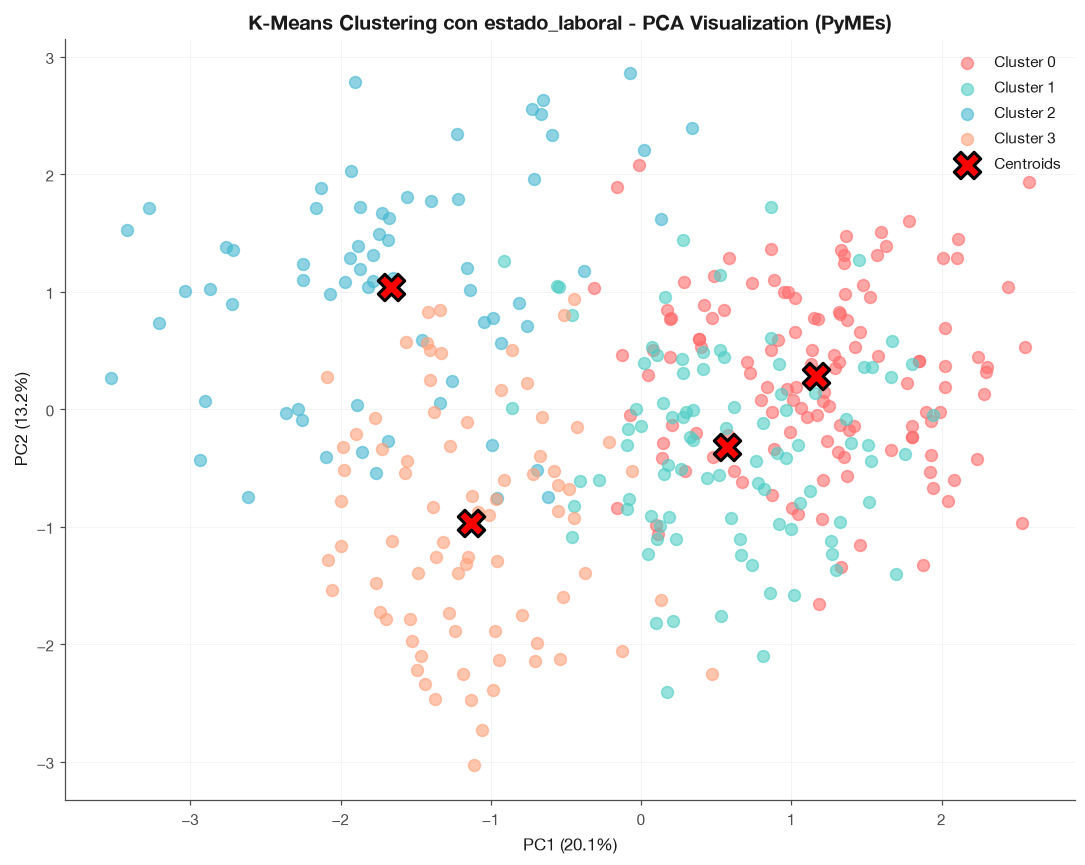

Varianza explicada: PC1=20.1%, PC2=13.2%, total=33.3%


In [119]:
pca_v2 = PCA(n_components=2)
df_pca_v2 = pca_v2.fit_transform(df_scaled_v2)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for cid in range(k):
    mask = clusters_v2 == cid
    ax.scatter(df_pca_v2[mask, 0], df_pca_v2[mask, 1], c=colors[cid],
               label=f'Cluster {cid}', s=60, alpha=0.6)
centroids_pca_v2 = pca_v2.transform(kmeans_v2.cluster_centers_)
ax.scatter(centroids_pca_v2[:, 0], centroids_pca_v2[:, 1], c='red', marker='X', s=300,
           edgecolors='black', linewidths=2, label='Centroids')
ax.set_xlabel(f'PC1 ({pca_v2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_v2.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clustering con estado_laboral - PCA Visualization (PyMEs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "clustering_pca_visualization_pymes_estado_laboral.png", subdir="pymes")
plt.show()
print(f"Varianza explicada: PC1={pca_v2.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca_v2.explained_variance_ratio_[1]:.1%}, "
      f"total={pca_v2.explained_variance_ratio_.sum():.1%}")

In [120]:
for cid in range(k):
    cdata = df_cluster_clean_v2[df_cluster_clean_v2['cluster'] == cid]
    print(f"\nCLUSTER {cid}: {len(cdata)} ({100*len(cdata)/len(df_cluster_clean_v2):.1f}%)")
    for col in clustering_features_v2:
        vc = cdata[col].value_counts()
        if len(vc) > 0:
            print(f"  {col}: {vc.index[0]} ({100*vc.iloc[0]/len(cdata):.1f}%)")


CLUSTER 0: 128 (34.8%)
  sexo: masculino (100.0%)
  edad: [41-50] (27.3%)
  niveduc: universitaria completa (33.6%)
  estado_laboral: empleado (85.9%)
  nse: c2 (48.4%)
  p01: atender clientes (31.2%)
  p02: familia o amigos (41.4%)
  p03: falta de capital (55.5%)
  p04: 2 a 4 horas (29.7%)

CLUSTER 1: 93 (25.3%)
  sexo: femenino (100.0%)
  edad: [31-40] (26.9%)
  niveduc: universitaria completa (35.5%)
  estado_laboral: empleado (86.0%)
  nse: c2 (54.8%)
  p01: hacer publicidad (34.4%)
  p02: familia o amigos (45.2%)
  p03: falta de capital (54.8%)
  p04: 1 a 2 horas (32.3%)

CLUSTER 2: 68 (18.5%)
  sexo: femenino (73.5%)
  edad: [61+] (51.5%)
  niveduc: media completa (35.3%)
  estado_laboral: inactivo (98.5%)
  nse: c3 (60.3%)
  p01: ninguna me quita tiempo / no aplica (26.5%)
  p02: familia o amigos (60.3%)
  p03: falta de capital (61.8%)
  p04: 1 a 2 horas (27.9%)

CLUSTER 3: 79 (21.5%)
  sexo: femenino (62.0%)
  edad: [18-30] (24.1%)
  niveduc: media completa (82.3%)
  estado_la

**Comparacion con clustering original (Seccion 7, `ocupacion`).** Se recalcula el clustering
original con las mismas semillas y se cruzan las asignaciones fila a fila.

In [121]:
clustering_features_orig = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster_orig = dfpymes[clustering_features_orig].dropna().copy()
df_encoded_orig = pd.DataFrame()
for col in df_cluster_orig.columns:
    le = LabelEncoder()
    df_encoded_orig[col] = le.fit_transform(df_cluster_orig[col].astype(str).values)
df_scaled_orig = StandardScaler().fit_transform(df_encoded_orig.astype(float))
kmeans_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_orig['cluster'] = kmeans_orig.fit_predict(df_scaled_orig)

overlap = pd.crosstab(df_cluster_orig['cluster'], df_cluster_clean_v2['cluster'])
overlap.index.name = "cluster original (ocupacion)"
overlap.columns.name = "cluster nuevo (estado_laboral)"
overlap

cluster nuevo (estado_laboral),0,1,2,3
cluster original (ocupacion),,,,
0,91,0,6,1
1,4,4,23,66
2,0,71,26,7
3,33,18,13,5


**Interpretacion:** la calidad de clustering **mejora levemente en Silhouette**
(0.1365 vs. 0.1190 original) pero **empeora levemente en Davies-Bouldin** (2.1493 vs. 2.1201) --
un resultado mixto, sin una mejora clara en ningun sentido, a diferencia del hallazgo de
significancia de 8.3. Mas relevante es el **overlap fragmentado** con los clusters originales: a
diferencia de Competentes (92-99% de overlap), en PyMEs el cluster original 1 (trabajos menores e
informales, NSE d+e) se reparte entre el nuevo cluster 3 (68.0%) y el nuevo cluster 2 (23.7%); el
cluster original 3 (masculino, NSE c3, falta de tiempo) se fragmenta aun mas, entre los nuevos
clusters 0 (47.8%), 1 (26.1%) y 2 (18.8%). Solo el cluster original 0 mantiene un overlap alto con
el nuevo cluster 0 (92.9%). **Conclusion:** a diferencia de Competentes, en PyMEs `ocupacion` **si
aportaba informacion propia** a la segmentacion, no completamente redundante con
sexo/edad/niveduc/nse/p01/p02/p03/p04 -- al agruparla en 4 categorias, los limites entre clusters
se recomponen de forma distinta, especialmente para los segmentos antes diferenciados por
categorias de ocupacion "no jerarquicas" como `trabajos menores e informales`. Los nuevos perfiles
siguen siendo interpretables (cluster 2, 98.5% `inactivo`, es esencialmente el segmento de
jubilados/dueñas de casa de mayor edad) pero **no deben tratarse como equivalentes 1:1** a los 4
perfiles de la Seccion 7.

### 8.7 Sintesis

- **Definicion:** `estado_laboral` agrupa los 10 valores de `ocupacion` en 4 categorias
  (empleado 69.0%, inactivo 18.5%, desempleado 6.8%, estudiante 5.7%), sin eliminar `ocupacion`.
- **Crosstabs (8.2):** los patrones descriptivos de la Seccion 3.4 se mantienen a nivel agrupado
  (SERCOTEC en 0% para desempleado/estudiante, publicidad como barrera de tiempo dominante en
  desempleado/estudiante, `inactivo` con negocios de menor intensidad), y **la disposicion binaria
  a aprender (`p04_bin`) se homogeniza** (rango 92.6%-96.0% vs. 84.6%-98.1% con `ocupacion`).
- **Significancia (8.3) -- hallazgo principal:** `estado_laboral x p01` **se vuelve significativo**
  (p=0.034) donde `ocupacion x p01` no lo era (p=0.068), con el mismo tamaño de efecto (V≈0.096) --
  la agrupacion aporta potencia estadistica real en este cruce, a diferencia de Competentes.
- **Correspondencias (8.4):** confirma visualmente que `inactivo` (negocios de baja intensidad) es
  el segmento que mas se distingue del resto en el eje principal.
- **Modelamiento (8.5):** metricas de clasificacion identicas a la Seccion 6; `estado_laboral`
  pierde importancia relativa en Random Forest (posicion 6 vs. 2 de `ocupacion`) sin perdida de
  poder predictivo del modelo.
- **Clustering (8.6):** calidad de cluster mixta (Silhouette mejora, Davies-Bouldin empeora); el
  overlap con los clusters originales es **fragmentado** (vs. Competentes, donde es casi total) --
  `ocupacion` aporta informacion propia a la segmentacion de PyMEs que `estado_laboral` no
  reproduce completamente.
- **Implicancia practica:** en PyMEs, `estado_laboral` es utilizable para reportes ejecutivos y
  mejora la confiabilidad del cruce con `p01`, pero **no debe reemplazar a `ocupacion` en el
  clustering** (Seccion 7) sin advertir que los segmentos resultantes son distintos, no una
  simplificacion neutra de los mismos 4 perfiles.

# 9. Selección del Mejor Modelo de Clustering: Búsqueda sobre Variables Sociodemográficas

Este análisis prueba sistemáticamente **todas las combinaciones posibles** de las 5 variables
sociodemográficas (`sexo`, `edad`, `niveduc`, `ocupacion`, `nse`) -- incluyéndolas o
excluyéndolas -- manteniendo fijas las 4 variables de negocio (`p01`-`p04`). Para cada una de las
32 combinaciones (2⁵) se ajusta K-Means con `k=4` y `random_state=42` (mismos parámetros que la
Sección 7), y se evalúa la calidad de discriminación con Silhouette Score (métrica principal),
Davies-Bouldin Score y varianza explicada por PCA en 2D. El objetivo es quedarse únicamente con
el modelo que mejor discrimine.

In [122]:
import itertools

demo_vars = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse']
business_vars = ['p01', 'p02', 'p03', 'p04']

sweep_results = []
for r in range(0, len(demo_vars) + 1):
    for combo in itertools.combinations(demo_vars, r):
        features = list(combo) + business_vars
        df_c = dfpymes[features].dropna().copy()
        df_enc = pd.DataFrame()
        for col in df_c.columns:
            le = LabelEncoder()
            df_enc[col] = le.fit_transform(df_c[col].astype(str).values)
        df_sc = StandardScaler().fit_transform(df_enc.astype(float))
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        labels = km.fit_predict(df_sc)
        sil = silhouette_score(df_sc, labels)
        db = davies_bouldin_score(df_sc, labels)
        pca_ = PCA(n_components=2).fit(df_sc)
        var2d = pca_.explained_variance_ratio_.sum()
        sweep_results.append({
            'demo_vars': ', '.join(combo) if combo else '(ninguna)',
            'n_demo_vars': r,
            'n_features': len(features),
            'silhouette': round(sil, 4),
            'davies_bouldin': round(db, 4),
            'pca_var_2d': round(var2d, 4),
        })

sweep_df = pd.DataFrame(sweep_results).sort_values('silhouette', ascending=False).reset_index(drop=True)
pd.set_option('display.max_rows', 40)
sweep_df

,demo_vars,n_demo_vars,n_features,silhouette,davies_bouldin,pca_var_2d
0,(ninguna),0,4,0.2603,1.2361,0.5259
1,sexo,1,5,0.2281,1.4364,0.4330
2,niveduc,1,5,0.1954,1.5510,0.4439
3,ocupacion,1,5,0.1925,1.5189,0.4372
4,nse,1,5,0.1919,1.5537,0.4478
5,edad,1,5,0.1900,1.5423,0.4390
6,"sexo, nse",2,6,0.1819,1.6496,0.3885
7,"ocupacion, nse",2,6,0.1814,1.6408,0.4327
8,"sexo, niveduc",2,6,0.1807,1.6647,0.3901
9,"sexo, ocupacion",2,6,0.1805,1.6902,0.3687


**Interpretación de la búsqueda.** El Silhouette Score cae de forma prácticamente monótona a
medida que se agregan más variables sociodemográficas categóricas: la combinación con **mejor
métrica absoluta es "(ninguna)"** -- clustering usando solo `p01`-`p04`, sin ninguna variable
demográfica. Esto ocurre porque el algoritmo, al perder dimensiones categóricas de baja
correlación entre sí, encuentra una estructura más compacta y separable en el espacio
escalado -- pero ese modelo deja de ser un "perfil de dueños/as de PyMEs" (no hay ninguna variable
demográfica que caracterice a los grupos), por lo que se descarta para los fines de este
análisis, que busca segmentos demográficamente interpretables.

**Modelo elegido: `sexo`.** Entre todas las combinaciones que retienen al menos una variable
sociodemográfica, `sexo` en solitario es, por un margen amplio, la que mejor discrimina
(Silhouette 0.2281, Davies-Bouldin 1.4364, varianza PCA 2D 43.3%) -- muy por encima de cualquier
otra variable individual (`niveduc` 0.1954, `ocupacion` 0.1925, `nse` 0.1919, `edad` 0.1900) y de
cualquier combinación de 2 o más variables (la mejor de ellas, `sexo`+`nse`, cae a 0.1819). Es
también muy superior al modelo con las 5 variables de la Sección 7 (0.1190). El resto del
análisis se construye sobre este modelo: **`sexo` + `p01`-`p04`**, con `k=4` y
`random_state=42`.

## 9.1 Modelo Final: Clustering con `sexo` + Variables de Negocio

In [123]:
clustering_features_final = ['sexo', 'p01', 'p02', 'p03', 'p04']
df_cluster_final = dfpymes[clustering_features_final].copy()
df_cluster_clean_final = df_cluster_final.dropna()

print(f"Rows with complete data: {len(df_cluster_clean_final)} / {len(df_cluster_final)} ({100*len(df_cluster_clean_final)/len(df_cluster_final):.1f}%)")

df_encoded_final = pd.DataFrame()
for col in df_cluster_clean_final.columns:
    le = LabelEncoder()
    df_encoded_final[col] = le.fit_transform(df_cluster_clean_final[col].astype(str).values)

scaler_final = StandardScaler()
df_scaled_final = scaler_final.fit_transform(df_encoded_final.astype(float))
print(f"Data scaled: shape {df_scaled_final.shape}, mean={df_scaled_final.mean():.4f}, std={df_scaled_final.std():.4f}")

Rows with complete data: 368 / 368 (100.0%)
Data scaled: shape (368, 5), mean=-0.0000, std=1.0000


### 9.1.1 Validación de número de clusters

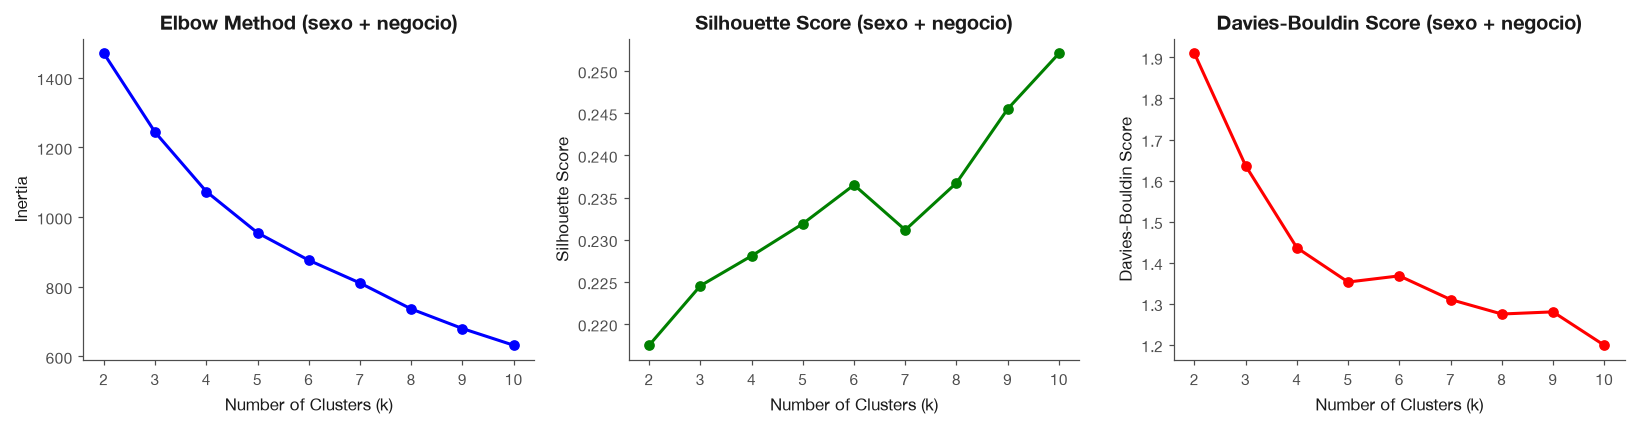

k con mejor Silhouette en este rango: k=10 (Silhouette=0.2521)
Se mantiene k=4 para comparabilidad directa con la Seccion 7.


In [124]:
inertias_final = []
silhouette_scores_final = []
davies_bouldin_scores_final = []
k_range = range(2, 11)

for k_ in k_range:
    kmeans_ = KMeans(n_clusters=k_, random_state=42, n_init=10)
    kmeans_.fit(df_scaled_final)
    inertias_final.append(kmeans_.inertia_)
    silhouette_scores_final.append(silhouette_score(df_scaled_final, kmeans_.labels_))
    davies_bouldin_scores_final.append(davies_bouldin_score(df_scaled_final, kmeans_.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertias_final, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (sexo + negocio)')
axes[0].grid()

axes[1].plot(k_range, silhouette_scores_final, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (sexo + negocio)')
axes[1].grid()

axes[2].plot(k_range, davies_bouldin_scores_final, 'ro-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (sexo + negocio)')
axes[2].grid()

plt.tight_layout()
save_fig(fig, "clustering_validation_metrics_pymes_final.png", subdir="pymes")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores_final))]
print(f"k con mejor Silhouette en este rango: k={best_k} (Silhouette={max(silhouette_scores_final):.4f})")
print(f"Se mantiene k=4 para comparabilidad directa con la Seccion 7.")

### 9.1.2 Clustering K-Means (k=4)

In [125]:
k = 4
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_final = kmeans_final.fit_predict(df_scaled_final)

df_cluster_clean_final['cluster'] = clusters_final

cluster_sizes_final = df_cluster_clean_final['cluster'].value_counts().sort_index()
print(f"\nCluster Distribution (sexo + negocio):")
for cluster_id, size in cluster_sizes_final.items():
    pct = 100 * size / len(df_cluster_clean_final)
    print(f"  Cluster {cluster_id}: {size} ({pct:.1f}%)")

silhouette_final = silhouette_score(df_scaled_final, clusters_final)
davies_bouldin_final = davies_bouldin_score(df_scaled_final, clusters_final)
print(f"\nCluster Quality Metrics (sexo + negocio):")
print(f"  Silhouette Score: {silhouette_final:.4f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_final:.4f}")


Cluster Distribution (sexo + negocio):
  Cluster 0: 116 (31.5%)
  Cluster 1: 64 (17.4%)
  Cluster 2: 68 (18.5%)
  Cluster 3: 120 (32.6%)

Cluster Quality Metrics (sexo + negocio):
  Silhouette Score: 0.2281
  Davies-Bouldin Score: 1.4364


PCA Explained Variance Ratio (sexo + negocio):
  PC1: 22.3%
  PC2: 21.0%
  Total: 43.3%


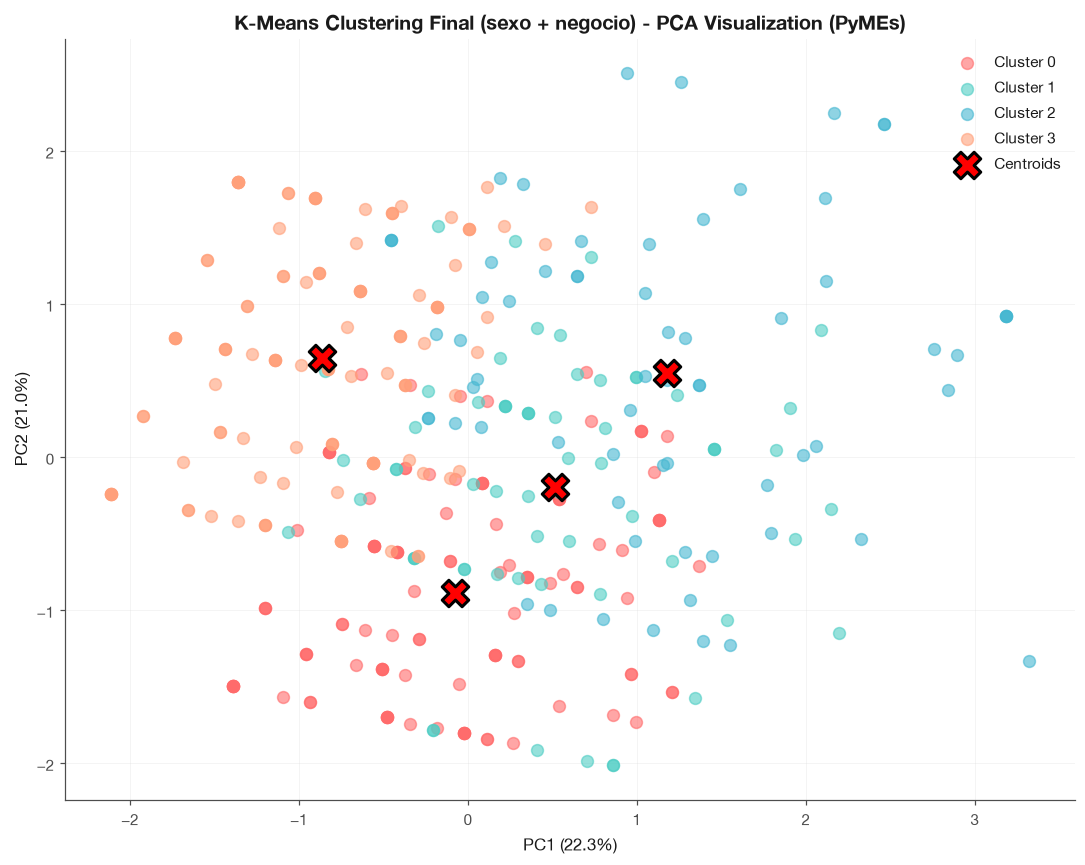

In [126]:
pca_final = PCA(n_components=2)
df_pca_final = pca_final.fit_transform(df_scaled_final)

print(f"PCA Explained Variance Ratio (sexo + negocio):")
print(f"  PC1: {pca_final.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca_final.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca_final.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for cluster_id in range(k):
    mask = clusters_final == cluster_id
    ax.scatter(df_pca_final[mask, 0], df_pca_final[mask, 1], c=colors[cluster_id], label=f'Cluster {cluster_id}', s=60, alpha=0.6)

centroids_pca_final = pca_final.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca_final[:, 0], centroids_pca_final[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clustering Final (sexo + negocio) - PCA Visualization (PyMEs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "clustering_pca_visualization_pymes_final.png", subdir="pymes")
plt.show()

### 9.1.3 Perfiles detallados de clusters

Se reportan `sexo` y las variables de negocio (usadas en el modelo), y además, solo como
referencia descriptiva -- **sin haber sido usadas para formar los clusters** -- la distribución
de `edad`, `niveduc`, `ocupacion` y `nse` dentro de cada cluster.

In [127]:
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES - PyMEs (modelo final: sexo + negocio)")
print("="*80)

for cluster_id in range(k):
    cluster_data = df_cluster_clean_final[df_cluster_clean_final['cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    cluster_pct = 100 * cluster_size / len(df_cluster_clean_final)

    print(f"\nCLUSTER {cluster_id}: {cluster_size} members ({cluster_pct:.1f}%)")
    print("-" * 80)

    print("\nVariables del modelo:")
    for col in ['sexo', 'p01', 'p02', 'p03', 'p04']:
        mode_val = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else "N/A"
        value_counts = cluster_data[col].value_counts()
        if len(value_counts) > 0:
            pct = 100 * value_counts.iloc[0] / len(cluster_data)
            print(f"  {col}: {mode_val} ({pct:.1f}%)")

    print("\nVariables demograficas de referencia (NO usadas en el modelo):")
    for col in ['edad', 'niveduc', 'ocupacion', 'nse']:
        ref_vals = dfpymes.loc[cluster_data.index, col].value_counts(normalize=True) * 100
        top = ref_vals.index[0]
        print(f"  {col}: {top} ({ref_vals.iloc[0]:.1f}%)")


DETAILED CLUSTER PROFILES - PyMEs (modelo final: sexo + negocio)

CLUSTER 0: 116 members (31.5%)
--------------------------------------------------------------------------------

Variables del modelo:
  sexo: masculino (100.0%)
  p01: atender clientes (33.6%)
  p02: familia o amigos (61.2%)
  p03: falta de capital (76.7%)
  p04: 1 a 2 horas (26.7%)

Variables demograficas de referencia (NO usadas en el modelo):
  edad: [41-50] (25.0%)
  niveduc: universitaria completa (27.6%)
  ocupacion: empleado(a) administrativo(a) / tecnico (22.4%)
  nse: c2 (36.2%)

CLUSTER 1: 64 members (17.4%)
--------------------------------------------------------------------------------

Variables del modelo:
  sexo: femenino (65.6%)
  p01: hacer publicidad (34.4%)
  p02: un curso o capacitación (57.8%)
  p03: falta de capital (68.8%)
  p04: 2 a 4 horas (46.9%)

Variables demograficas de referencia (NO usadas en el modelo):
  edad: [41-50] (28.1%)
  niveduc: tecnica superior completa (31.2%)
  ocupacion: emp

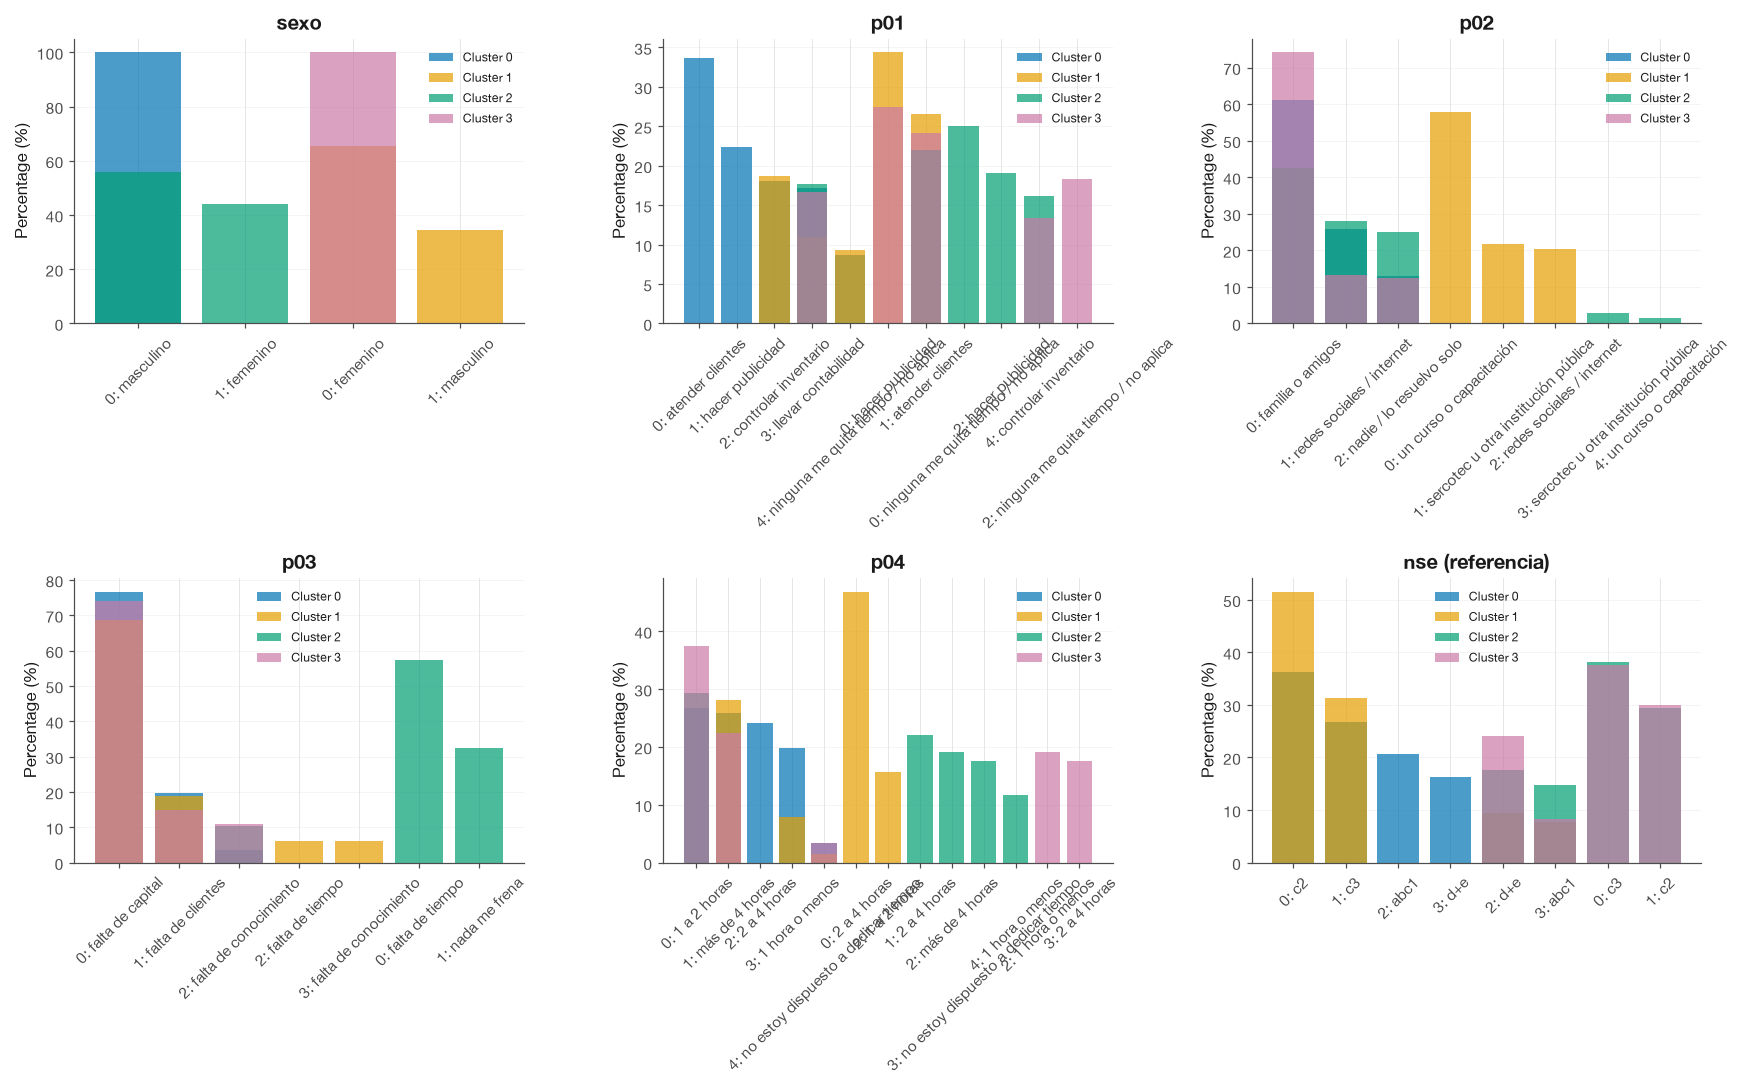

In [128]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
display_cols_final = ['sexo', 'p01', 'p02', 'p03', 'p04', 'nse']

for idx, col in enumerate(display_cols_final):
    ax = axes[idx // 3, idx % 3]

    for cluster_id in range(k):
        idxs = df_cluster_clean_final[df_cluster_clean_final['cluster'] == cluster_id].index
        vc = dfpymes.loc[idxs, col].value_counts()
        cluster_size = len(idxs)
        normalized = 100 * vc / cluster_size
        ax.bar([f"{i}: {v}" for i, v in enumerate(normalized.index[:5])], normalized.values[:5], label=f'Cluster {cluster_id}', alpha=0.7)

    ax.set_title(f'{col}' + (' (referencia)' if col not in ['sexo', 'p01', 'p02', 'p03', 'p04'] else ''))
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, "clustering_demographic_comparison_pymes_final.png", subdir="pymes")
plt.show()

## 9.2 Comparación con el Modelo Original (Sección 7, 5 variables sociodemográficas)

Se recalcula el clustering original (con las 5 variables demográficas) con las mismas semillas y
se cruzan las asignaciones fila a fila contra el clustering final (`sexo` + negocio), para
cuantificar cuánto cambia la segmentación al usar el modelo que mejor discrimina.

In [129]:
clustering_features_orig_ref2 = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster_orig_ref2 = dfpymes[clustering_features_orig_ref2].dropna().copy()
df_encoded_orig_ref2 = pd.DataFrame()
for col in df_cluster_orig_ref2.columns:
    le = LabelEncoder()
    df_encoded_orig_ref2[col] = le.fit_transform(df_cluster_orig_ref2[col].astype(str).values)
df_scaled_orig_ref2 = StandardScaler().fit_transform(df_encoded_orig_ref2.astype(float))
kmeans_orig_ref2 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_orig_ref2['cluster'] = kmeans_orig_ref2.fit_predict(df_scaled_orig_ref2)

overlap_final = pd.crosstab(df_cluster_orig_ref2['cluster'], df_cluster_clean_final['cluster'])
overlap_final.index.name = "cluster original (5 var. demograficas)"
overlap_final.columns.name = "cluster final (sexo + negocio)"

overlap_pct_final = overlap_final.div(overlap_final.sum(axis=1), axis=0) * 100
print("Conteos:")
print(overlap_final)
print()
print("Porcentaje por fila:")
print(overlap_pct_final.round(1))

Conteos:
cluster final (sexo + negocio)           0   1   2   3
cluster original (5 var. demograficas)                
0                                       81  16   1   0
1                                       33   7   7  50
2                                        0  34   2  68
3                                        2   7  58   2

Porcentaje por fila:
cluster final (sexo + negocio)             0     1     2     3
cluster original (5 var. demograficas)                        
0                                       82.7  16.3   1.0   0.0
1                                       34.0   7.2   7.2  51.5
2                                        0.0  32.7   1.9  65.4
3                                        2.9  10.1  84.1   2.9


**Tabla comparativa de métricas (k=4, `random_state=42` en todos los casos):**

| Métrica | Sección 7 (5 var. demo. + negocio, 9 features) | Modelo final (`sexo` + negocio, 5 features) |
|---|---|---|
| Variables de entrada | `sexo`, `edad`, `niveduc`, `ocupacion`, `nse`, `p01`-`p04` | `sexo`, `p01`-`p04` |
| Silhouette Score | 0.1190 | **0.2281** (+0.1091) |
| Davies-Bouldin Score | 2.1201 | **1.4364** (-0.6837, mejora) |
| Varianza PCA 2D | 33.8% | **43.3%** (+9.5 pp) |
| Tamaños de cluster | 98 / 97 / 104 / 69 (26.6% / 26.4% / 28.3% / 18.8%) | 116 / 64 / 68 / 120 (31.5% / 17.4% / 18.5% / 32.6%) |

Las tres métricas de validación mejoran de forma sustancial respecto al modelo original de la
Sección 7 -- no son mejoras marginales como las observadas al remover solo `sexo` (Sección 9
anterior), sino un salto de calidad claro: reducir de 9 a 5 variables, conservando únicamente
`sexo` como eje demográfico, produce clusters casi el doble de compactos y separados
(Silhouette casi duplicado).

**Lectura del overlap (celda anterior).** Los clusters originales que ya eran puros por género
(orig. 0, 100% masculino, y orig. 2, 100% femenino -- ambos NSE c2, `empleado
administrativo/técnico`) se mapean con alta concentración a los nuevos clusters del mismo género
(82.7% y 65.4% respectivamente), confirmando que el modelo final simplemente **retiene y agudiza**
la separación por sexo que ya dominaba esos dos segmentos. El cluster original 3 (falta de tiempo,
NSE c3, 58% masculino) se preserva casi intacto (84.1% de overlap) en el nuevo cluster 2 -- un
segmento que el modelo final también recupera casi sin cambios. El único cluster que se fragmenta
de forma relevante es el original 1 (segmento informal/d+e, mezcla de género 60.8% femenino/39.2%
masculino): al usar `sexo` como eje primario, sus miembros se reparten entre el nuevo cluster 0
(masculino, 34.0%) y el nuevo cluster 3 (femenino, 51.5%), en una proporción consistente con su
propia mezcla de género.

## 9.3 Descripción Narrativa de los Clusters (Modelo Final: `sexo` + Negocio)

**Cluster 0 -- "Atención al cliente, capital limitado" (116 dueños, 31.5% de la muestra).**
Este es el grupo más numeroso y **es enteramente masculino (100%)**. Son dueños que, en promedio,
tienen entre 41 y 50 años, cuentan con educación universitaria completa y trabajan como
empleados administrativos o técnicos, principalmente en el segmento socioeconómico c2. Lo que más
tiempo les consume del negocio es **atender clientes** (33.6%), y su principal barrera declarada
es, por amplio margen, la **falta de capital** (76.7%). Para salir adelante recurren sobre todo a
la ayuda de familiares o amigos (61.2%) y dedican entre 1 y 2 horas semanales a aprender
herramientas digitales. Es el perfil del comerciante varón de mediana edad, con formación
superior y una posición relativamente estable (c2), cuya limitación central no es de tiempo ni de
conocimiento, sino de acceso a financiamiento.

**Cluster 1 -- "En capacitación activa, invirtiendo tiempo" (64 dueños, 17.4% de la muestra).**
El cluster más pequeño, y el único con una **mezcla de género relativamente equilibrada**
(65.6% femenino / 34.4% masculino). En promedio tienen entre 41 y 50 años, poseen educación
técnica superior completa y trabajan como empleados administrativos/técnicos de NSE c2. Su
mayor consumo de tiempo es **hacer publicidad** (34.4%), y a diferencia de todos los demás
clusters, su fuente de ayuda predominante **no es la familia sino un curso o capacitación
formal** (57.8%) -- el único grupo donde la capacitación estructurada supera al apoyo informal.
Consistente con eso, son quienes más tiempo dedican a aprender herramientas digitales (2 a 4
horas semanales, 46.9%), casi el doble que el resto. Es el perfil más proactivo y
"profesionalizado" de la muestra: gente que ya está invirtiendo activamente en su propia
capacitación digital, más allá del círculo familiar.

**Cluster 2 -- "Sin apremio de tiempo, foco en eficiencia" (68 dueños, 18.5% de la muestra).**
Con una leve mayoría masculina (55.9%), este es el grupo de **mayor edad promedio** (61+ años,
25.0%) y el de menor nivel educativo relativo (media completa, 25.0%), concentrado en NSE c3. Es
el único cluster donde la respuesta más común a "qué tarea consume más tiempo" es **"ninguna me
quita tiempo / no aplica"** (25.0%) -- sugiriendo negocios de menor escala o ya optimizados -- y
su barrera principal, a diferencia de los otros tres clusters (todos dominados por falta de
capital), es la **falta de tiempo** (57.4%). Se apoyan en familia/amigos (42.6%) en menor medida
que otros grupos y dedican 1 a 2 horas semanales a aprender. Es el perfil de dueños/as de mayor
edad, con negocios más simples o ya estabilizados, cuya barrera ya no es económica sino de
disponibilidad horaria.

**Cluster 3 -- "Publicidad y redes de apoyo familiar" (120 dueños, 32.6% de la muestra).**
El segundo cluster más grande y, al igual que el Cluster 0, **enteramente puro por género --
100% femenino**. En promedio tienen entre 41 y 50 años, con educación media completa (36.7%) y
una alta proporción en el segmento de "trabajos menores e informales" (20.8%, la mayor de los 4
clusters), concentradas en NSE c3. Su mayor consumo de tiempo es **hacer publicidad** (27.5%,
igual que el Cluster 1 pero con perfil socioeconómico más bajo), su barrera dominante es la
**falta de capital** (74.2%, la más alta del grupo junto al Cluster 0), y se apoyan fuertemente en
familiares o amigos (74.2%, el porcentaje más alto de los 4 clusters). Dedican 1 a 2 horas
semanales a aprender (37.5%). Es el perfil de la dueña de negocio informal o de menor escala, con
fuerte dependencia de su red familiar y limitaciones de capital más marcadas que las de sus pares
masculinos del Cluster 0.

**Patrón transversal.** Los dos clusters más grandes (0 y 3, 64.1% de la muestra combinada) son
**cada uno 100% de un solo género** y comparten la misma barrera principal (falta de capital) y
fuente de apoyo (familia/amigos), diferenciándose sobre todo en la tarea que más tiempo consume
(atender clientes vs. hacer publicidad) y en el perfil socioeconómico de referencia (c2 vs. c3,
más informalidad en el cluster femenino). Los dos clusters más pequeños (1 y 2, 35.9% restante)
tienen mezcla de género y se distinguen por comportamientos, no por demografía: uno es el segmento
"proactivo" que invierte en capacitación formal (Cluster 1), el otro es el segmento de mayor edad
sin apremio de tiempo pero con falta de tiempo como barrera (Cluster 2).

## 9.4 Síntesis Final

- **Búsqueda (9, 9.0):** se evaluaron las 32 combinaciones posibles de `sexo`, `edad`, `niveduc`,
  `ocupacion`, `nse` (incluyéndolas o excluyéndolas) junto a `p01`-`p04`, con `k=4` y
  `random_state=42` fijos para comparabilidad. El Silhouette Score cae de forma casi monótona a
  medida que se agregan más variables demográficas categóricas: el óptimo absoluto es no usar
  ninguna (0.2603), pero ese modelo no permite caracterizar clusters demográficamente, por lo que
  se descartó. **Se eligió `sexo` en solitario** como la mejor variable sociodemográfica individual
  (Silhouette 0.2281), muy por encima de cualquier otra variable sola o combinación de 2+
  variables.
- **Modelo final (9.1):** `sexo` + `p01`-`p04` (5 variables), `k=4`. Silhouette 0.2281,
  Davies-Bouldin 1.4364, varianza PCA 2D 43.3% -- una mejora sustancial sobre el modelo original de
  la Sección 7 (0.1190 / 2.1201 / 33.8%), y también mejor que el modelo "sin sexo" explorado
  anteriormente (0.1361 / 1.9183 / 37.4%).
- **Estructura de los clusters (9.1.3, 9.3):** dos de los cuatro clusters resultan **puros por
  género** (Cluster 0, 100% masculino, 31.5%; Cluster 3, 100% femenino, 32.6%), concentrando el
  64.1% de la muestra y diferenciados principalmente por la tarea que más tiempo consume
  (atender clientes vs. hacer publicidad) y por el perfil socioeconómico de referencia (c2 vs. c3).
  Los otros dos clusters (17.4% y 18.5%) tienen mezcla de género y se definen por comportamiento:
  uno por inversión activa en capacitación formal, el otro por ausencia de apremio de tiempo
  propio de dueños/as de mayor edad.
- **Comparación con el modelo original (9.2):** el overlap confirma que los dos clusters
  originales que ya eran puros por género (Sección 7, clusters 0 y 2, ambos NSE c2/empleado
  administrativo) se mapean con alta concentración (82.7% y 65.4%) a los nuevos clusters del mismo
  género -- el modelo final no descubre una estructura nueva, sino que **aísla y agudiza** el eje
  de género que ya dominaba esos segmentos en el modelo de 9 variables, descartando el ruido que
  aportaban `edad`, `niveduc`, `ocupacion` y `nse` en simultáneo. El cluster de falta de tiempo
  (NSE c3) se preserva casi intacto (84.1%); el único cluster que se fragmenta es el segmento
  informal/d+e, que al perder su propio eje de segmentación (ocupación/NSE) se reparte por género
  entre los dos clusters puros del modelo final, en proporción consistente con su propia mezcla de
  género (60.8% femenino / 39.2% masculino).
- **Conclusión práctica.** El modelo `sexo` + `p01`-`p04` es el que mejor discrimina entre las
  opciones que retienen valor demográfico interpretable, y es el recomendado para reportes
  ejecutivos y diseño de intervenciones: identifica un eje de género claro y accionable
  (comerciantes hombres centrados en atención al cliente vs. mujeres centradas en publicidad, ambos
  con falta de capital como barrera dominante) y dos segmentos de comportamiento transversales al
  género (capacitación activa vs. limitación de tiempo en dueños/as mayores) que el modelo de 9
  variables de la Sección 7 diluía al mezclar cinco ejes demográficos con distinta fuerza
  discriminativa. **Este modelo -- Sección 9 -- reemplaza al de la Sección 7 como el clustering de
  referencia para caracterizar perfiles de dueños/as de PyMEs en este análisis.**

# 10. Modelo de Clustering sin Variables Sociodemográficas

La búsqueda de la Sección 9 mostró que la combinación con **mejor Silhouette Score absoluto**
(0.2603) es no usar ninguna variable sociodemográfica -- clustering solo con `p01`-`p04`. Esa
opción se descartó como modelo "final" en la Sección 9 porque no permite caracterizar clusters
demográficamente. Aquí se documenta en detalle ese modelo de **comportamiento puro**, replicando
la misma estructura de análisis (validación, K-Means k=4, PCA, perfiles, comparación con el
modelo original y con el modelo final de la Sección 9), para tenerlo disponible como referencia
completa.

## 10.1 Pipeline: Solo Variables de Negocio (`p01`-`p04`)

In [130]:
clustering_features_nodemo = ['p01', 'p02', 'p03', 'p04']
df_cluster_nodemo = dfpymes[clustering_features_nodemo].copy()
df_cluster_clean_nodemo = df_cluster_nodemo.dropna()

print(f"Rows with complete data: {len(df_cluster_clean_nodemo)} / {len(df_cluster_nodemo)} ({100*len(df_cluster_clean_nodemo)/len(df_cluster_nodemo):.1f}%)")

df_encoded_nodemo = pd.DataFrame()
for col in df_cluster_clean_nodemo.columns:
    le = LabelEncoder()
    df_encoded_nodemo[col] = le.fit_transform(df_cluster_clean_nodemo[col].astype(str).values)

scaler_nodemo = StandardScaler()
df_scaled_nodemo = scaler_nodemo.fit_transform(df_encoded_nodemo.astype(float))
print(f"Data scaled: shape {df_scaled_nodemo.shape}, mean={df_scaled_nodemo.mean():.4f}, std={df_scaled_nodemo.std():.4f}")

Rows with complete data: 368 / 368 (100.0%)
Data scaled: shape (368, 4), mean=-0.0000, std=1.0000


### 10.1.1 Validación de número de clusters

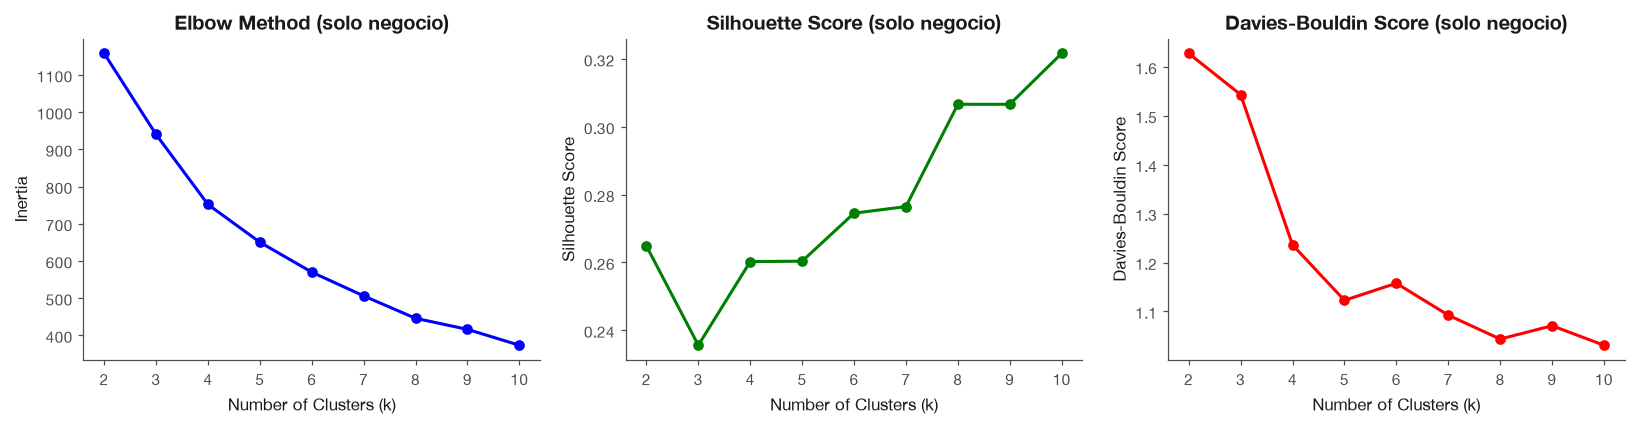

k con mejor Silhouette en este rango: k=10 (Silhouette=0.3217)
Se mantiene k=4 para comparabilidad directa con las Secciones 7 y 9.


In [131]:
inertias_nodemo = []
silhouette_scores_nodemo = []
davies_bouldin_scores_nodemo = []
k_range = range(2, 11)

for k_ in k_range:
    kmeans_ = KMeans(n_clusters=k_, random_state=42, n_init=10)
    kmeans_.fit(df_scaled_nodemo)
    inertias_nodemo.append(kmeans_.inertia_)
    silhouette_scores_nodemo.append(silhouette_score(df_scaled_nodemo, kmeans_.labels_))
    davies_bouldin_scores_nodemo.append(davies_bouldin_score(df_scaled_nodemo, kmeans_.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertias_nodemo, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (solo negocio)')
axes[0].grid()

axes[1].plot(k_range, silhouette_scores_nodemo, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (solo negocio)')
axes[1].grid()

axes[2].plot(k_range, davies_bouldin_scores_nodemo, 'ro-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (solo negocio)')
axes[2].grid()

plt.tight_layout()
save_fig(fig, "clustering_validation_metrics_pymes_nodemo.png", subdir="pymes")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores_nodemo))]
print(f"k con mejor Silhouette en este rango: k={best_k} (Silhouette={max(silhouette_scores_nodemo):.4f})")
print(f"Se mantiene k=4 para comparabilidad directa con las Secciones 7 y 9.")

### 10.1.2 Clustering K-Means (k=4)

In [132]:
k = 4
kmeans_nodemo = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_nodemo = kmeans_nodemo.fit_predict(df_scaled_nodemo)

df_cluster_clean_nodemo['cluster'] = clusters_nodemo

cluster_sizes_nodemo = df_cluster_clean_nodemo['cluster'].value_counts().sort_index()
print(f"\nCluster Distribution (solo negocio):")
for cluster_id, size in cluster_sizes_nodemo.items():
    pct = 100 * size / len(df_cluster_clean_nodemo)
    print(f"  Cluster {cluster_id}: {size} ({pct:.1f}%)")

silhouette_nodemo = silhouette_score(df_scaled_nodemo, clusters_nodemo)
davies_bouldin_nodemo = davies_bouldin_score(df_scaled_nodemo, clusters_nodemo)
print(f"\nCluster Quality Metrics (solo negocio):")
print(f"  Silhouette Score: {silhouette_nodemo:.4f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_nodemo:.4f}")


Cluster Distribution (solo negocio):
  Cluster 0: 72 (19.6%)
  Cluster 1: 106 (28.8%)
  Cluster 2: 119 (32.3%)
  Cluster 3: 71 (19.3%)

Cluster Quality Metrics (solo negocio):
  Silhouette Score: 0.2603
  Davies-Bouldin Score: 1.2361


PCA Explained Variance Ratio (solo negocio):
  PC1: 27.5%
  PC2: 25.1%
  Total: 52.6%


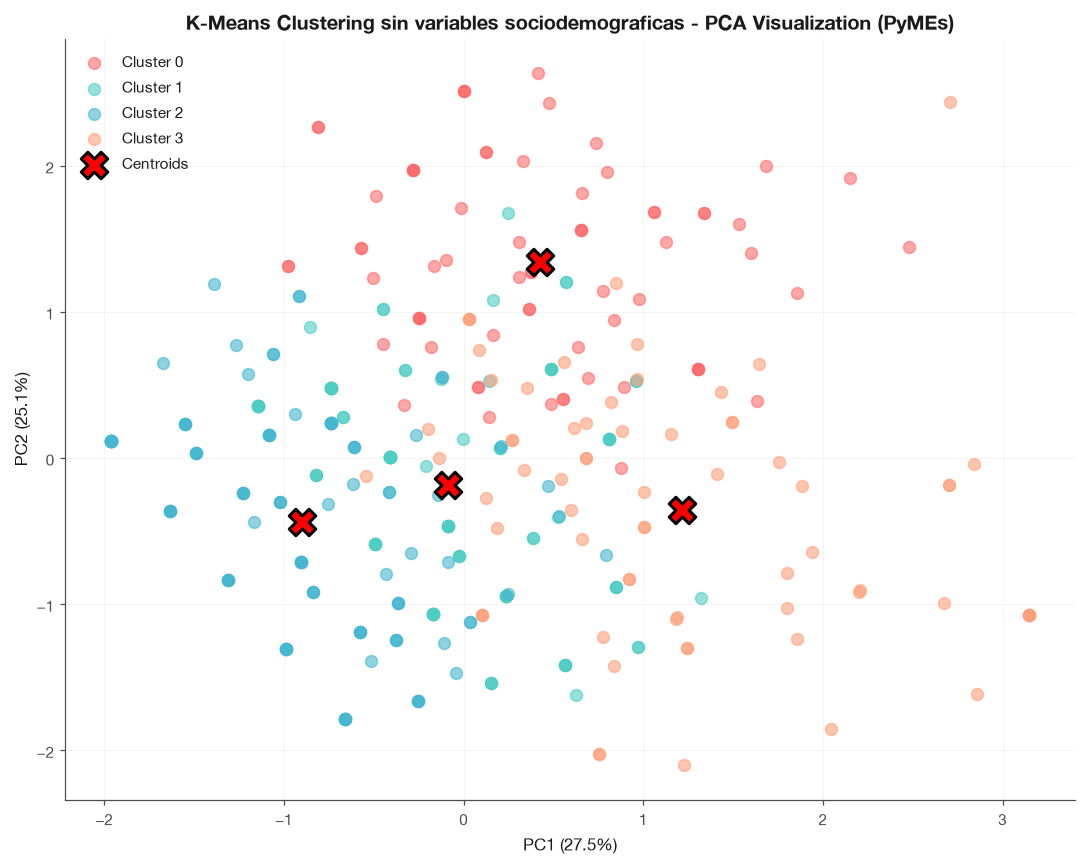

In [133]:
pca_nodemo = PCA(n_components=2)
df_pca_nodemo = pca_nodemo.fit_transform(df_scaled_nodemo)

print(f"PCA Explained Variance Ratio (solo negocio):")
print(f"  PC1: {pca_nodemo.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca_nodemo.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca_nodemo.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for cluster_id in range(k):
    mask = clusters_nodemo == cluster_id
    ax.scatter(df_pca_nodemo[mask, 0], df_pca_nodemo[mask, 1], c=colors[cluster_id], label=f'Cluster {cluster_id}', s=60, alpha=0.6)

centroids_pca_nodemo = pca_nodemo.transform(kmeans_nodemo.cluster_centers_)
ax.scatter(centroids_pca_nodemo[:, 0], centroids_pca_nodemo[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_nodemo.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_nodemo.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clustering sin variables sociodemograficas - PCA Visualization (PyMEs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "clustering_pca_visualization_pymes_nodemo.png", subdir="pymes")
plt.show()

### 10.1.3 Perfiles detallados de clusters

Se reportan las variables de negocio (usadas en el modelo). Como referencia descriptiva -- **sin
haber sido usadas para formar los clusters** -- se reporta también la distribución de `sexo`,
`edad`, `niveduc`, `ocupacion` y `nse` dentro de cada cluster.

In [134]:
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES - PyMEs (sin variables sociodemograficas)")
print("="*80)

for cluster_id in range(k):
    cluster_data = df_cluster_clean_nodemo[df_cluster_clean_nodemo['cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    cluster_pct = 100 * cluster_size / len(df_cluster_clean_nodemo)

    print(f"\nCLUSTER {cluster_id}: {cluster_size} members ({cluster_pct:.1f}%)")
    print("-" * 80)

    print("\nVariables del modelo:")
    for col in ['p01', 'p02', 'p03', 'p04']:
        mode_val = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else "N/A"
        value_counts = cluster_data[col].value_counts()
        if len(value_counts) > 0:
            pct = 100 * value_counts.iloc[0] / len(cluster_data)
            print(f"  {col}: {mode_val} ({pct:.1f}%)")

    print("\nVariables demograficas de referencia (NO usadas en el modelo):")
    for col in ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse']:
        ref_vals = dfpymes.loc[cluster_data.index, col].value_counts(normalize=True) * 100
        top = ref_vals.index[0]
        print(f"  {col}: {top} ({ref_vals.iloc[0]:.1f}%)")


DETAILED CLUSTER PROFILES - PyMEs (sin variables sociodemograficas)

CLUSTER 0: 72 members (19.6%)
--------------------------------------------------------------------------------

Variables del modelo:
  p01: atender clientes (31.9%)
  p02: un curso o capacitación (51.4%)
  p03: falta de capital (62.5%)
  p04: 2 a 4 horas (55.6%)

Variables demograficas de referencia (NO usadas en el modelo):
  sexo: femenino (51.4%)
  edad: [41-50] (29.2%)
  niveduc: tecnica superior completa (29.2%)
  ocupacion: empleado(a) administrativo(a) / tecnico (25.0%)
  nse: c2 (45.8%)

CLUSTER 1: 106 members (28.8%)
--------------------------------------------------------------------------------

Variables del modelo:
  p01: atender clientes (25.5%)
  p02: familia o amigos (73.6%)
  p03: falta de capital (88.7%)
  p04: más de 4 horas (58.5%)

Variables demograficas de referencia (NO usadas en el modelo):
  sexo: femenino (52.8%)
  edad: [41-50] (30.2%)
  niveduc: media completa (28.3%)
  ocupacion: emplead

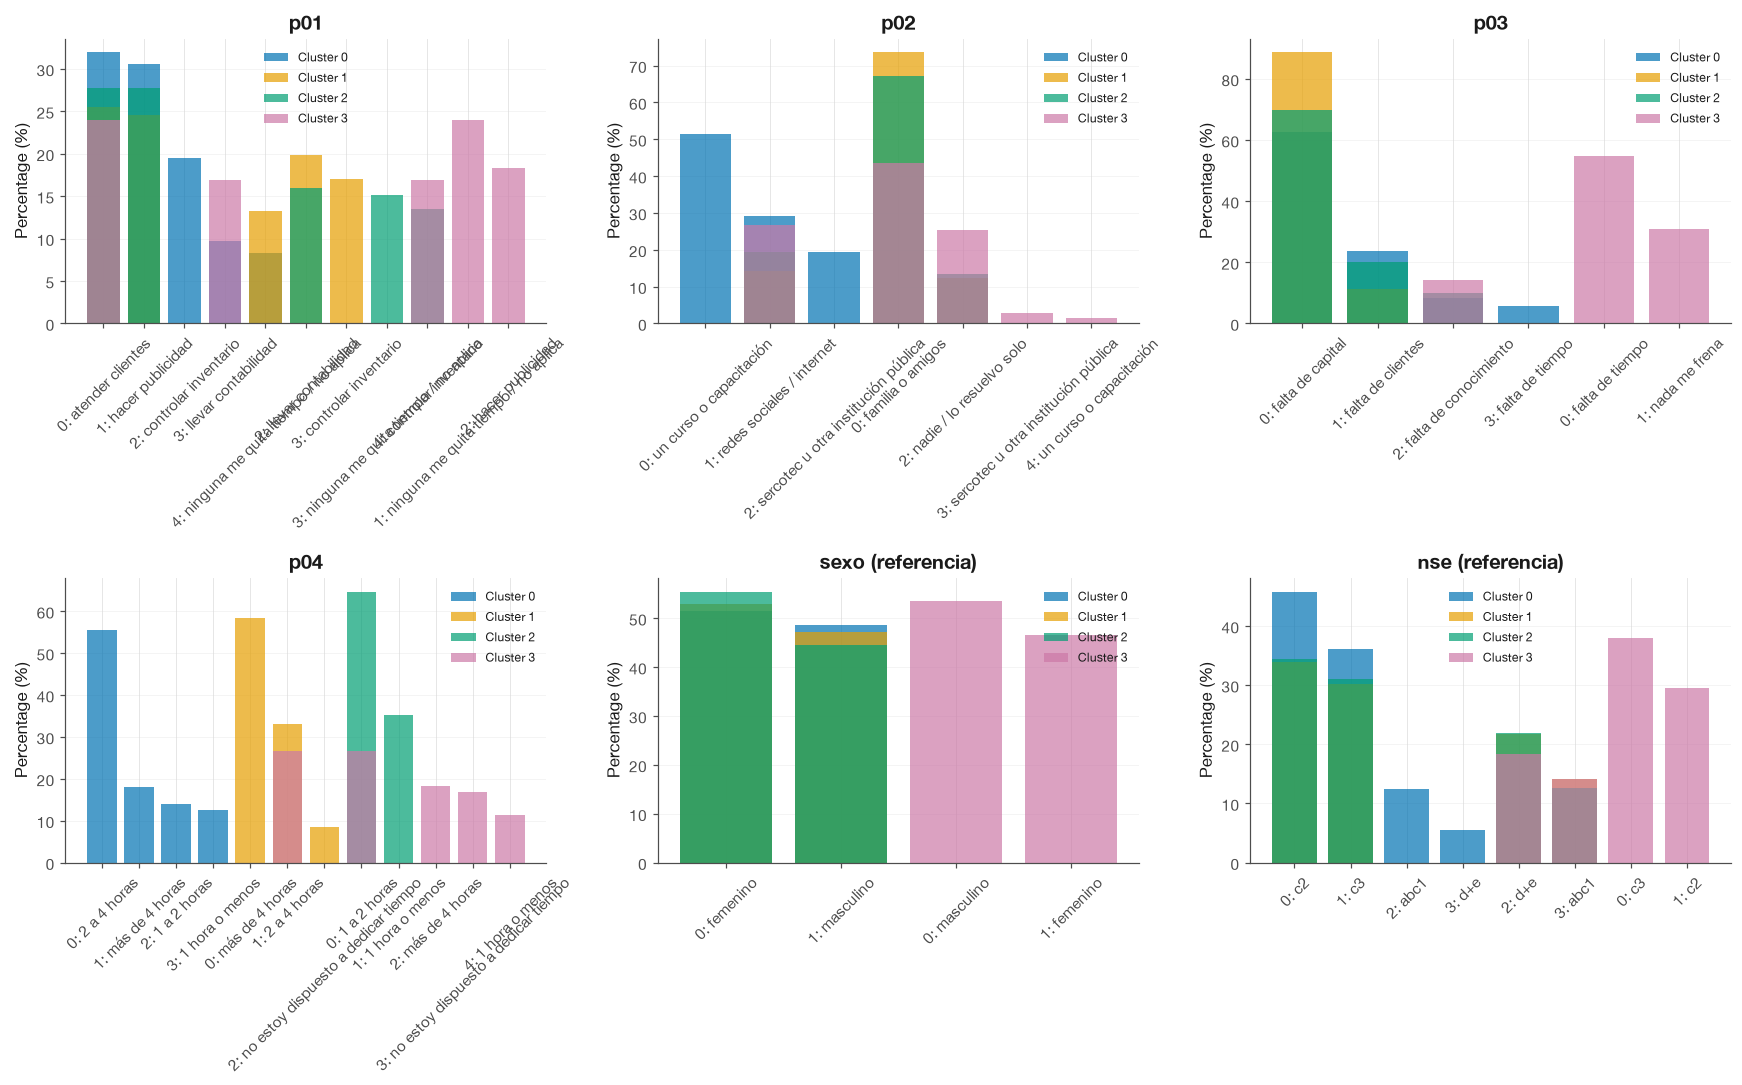

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
display_cols_nodemo = ['p01', 'p02', 'p03', 'p04', 'sexo', 'nse']

for idx, col in enumerate(display_cols_nodemo):
    ax = axes[idx // 3, idx % 3]

    for cluster_id in range(k):
        idxs = df_cluster_clean_nodemo[df_cluster_clean_nodemo['cluster'] == cluster_id].index
        vc = dfpymes.loc[idxs, col].value_counts()
        cluster_size = len(idxs)
        normalized = 100 * vc / cluster_size
        ax.bar([f"{i}: {v}" for i, v in enumerate(normalized.index[:5])], normalized.values[:5], label=f'Cluster {cluster_id}', alpha=0.7)

    ax.set_title(f'{col}' + (' (referencia)' if col not in ['p01', 'p02', 'p03', 'p04'] else ''))
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, "clustering_demographic_comparison_pymes_nodemo.png", subdir="pymes")
plt.show()

## 10.2 Comparación con el Modelo Original (Sección 7) y el Modelo Final (Sección 9)

Se recalcula el clustering original (5 variables demográficas + negocio) con las mismas semillas
y se cruza contra el clustering sin variables sociodemográficas, para cuantificar cuánto cambia
la segmentación al remover toda caracterización demográfica.

In [136]:
clustering_features_orig_ref3 = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster_orig_ref3 = dfpymes[clustering_features_orig_ref3].dropna().copy()
df_encoded_orig_ref3 = pd.DataFrame()
for col in df_cluster_orig_ref3.columns:
    le = LabelEncoder()
    df_encoded_orig_ref3[col] = le.fit_transform(df_cluster_orig_ref3[col].astype(str).values)
df_scaled_orig_ref3 = StandardScaler().fit_transform(df_encoded_orig_ref3.astype(float))
kmeans_orig_ref3 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_orig_ref3['cluster'] = kmeans_orig_ref3.fit_predict(df_scaled_orig_ref3)

overlap_nodemo_vs_orig = pd.crosstab(df_cluster_orig_ref3['cluster'], df_cluster_clean_nodemo['cluster'])
overlap_nodemo_vs_orig.index.name = "cluster original (Seccion 7)"
overlap_nodemo_vs_orig.columns.name = "cluster sin sociodemo (Seccion 10)"
overlap_pct_1 = (overlap_nodemo_vs_orig.div(overlap_nodemo_vs_orig.sum(axis=1), axis=0) * 100).round(1)
print("Overlap vs. Seccion 7 (conteos):")
print(overlap_nodemo_vs_orig)
print()
print("Overlap vs. Seccion 7 (% por fila):")
print(overlap_pct_1)

Overlap vs. Seccion 7 (conteos):
cluster sin sociodemo (Seccion 10)   0   1   2   3
cluster original (Seccion 7)                      
0                                   25  38  34   1
1                                    7  43  38   9
2                                   31  25  45   3
3                                    9   0   2  58

Overlap vs. Seccion 7 (% por fila):
cluster sin sociodemo (Seccion 10)     0     1     2     3
cluster original (Seccion 7)                              
0                                   25.5  38.8  34.7   1.0
1                                    7.2  44.3  39.2   9.3
2                                   29.8  24.0  43.3   2.9
3                                   13.0   0.0   2.9  84.1


In [137]:
clustering_features_final_ref = ['sexo', 'p01', 'p02', 'p03', 'p04']
df_cluster_final_ref = dfpymes[clustering_features_final_ref].dropna().copy()
df_encoded_final_ref = pd.DataFrame()
for col in df_cluster_final_ref.columns:
    le = LabelEncoder()
    df_encoded_final_ref[col] = le.fit_transform(df_cluster_final_ref[col].astype(str).values)
df_scaled_final_ref = StandardScaler().fit_transform(df_encoded_final_ref.astype(float))
kmeans_final_ref = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_final_ref['cluster'] = kmeans_final_ref.fit_predict(df_scaled_final_ref)

overlap_nodemo_vs_final = pd.crosstab(df_cluster_final_ref['cluster'], df_cluster_clean_nodemo['cluster'])
overlap_nodemo_vs_final.index.name = "cluster final Seccion 9 (sexo+negocio)"
overlap_nodemo_vs_final.columns.name = "cluster sin sociodemo (Seccion 10)"
overlap_pct_2 = (overlap_nodemo_vs_final.div(overlap_nodemo_vs_final.sum(axis=1), axis=0) * 100).round(1)
print("Overlap vs. Seccion 9 (conteos):")
print(overlap_nodemo_vs_final)
print()
print("Overlap vs. Seccion 9 (% por fila):")
print(overlap_pct_2)

Overlap vs. Seccion 9 (conteos):
cluster sin sociodemo (Seccion 10)       0   1   2   3
cluster final Seccion 9 (sexo+negocio)                
0                                       13  50  52   1
1                                       57   7   0   0
2                                        0   0   1  67
3                                        2  49  66   3

Overlap vs. Seccion 9 (% por fila):
cluster sin sociodemo (Seccion 10)         0     1     2     3
cluster final Seccion 9 (sexo+negocio)                        
0                                       11.2  43.1  44.8   0.9
1                                       89.1  10.9   0.0   0.0
2                                        0.0   0.0   1.5  98.5
3                                        1.7  40.8  55.0   2.5


**Tabla comparativa de métricas (k=4, `random_state=42` en todos los casos):**

| Métrica | Sección 7 (9 var., con demo.) | Sección 9 (`sexo`+negocio, 5 var.) | Sección 10 (solo negocio, 4 var.) |
|---|---|---|---|
| Silhouette Score | 0.1190 | 0.2281 | **0.2603** |
| Davies-Bouldin Score | 2.1201 | 1.4364 | **1.2361** |
| Varianza PCA 2D | 33.8% | 43.3% | **52.6%** |
| Tamaños de cluster | 98/97/104/69 (26.6/26.4/28.3/18.8%) | 116/64/68/120 (31.5/17.4/18.5/32.6%) | 72/106/119/71 (19.6/28.8/32.3/19.3%) |

El modelo sin variables sociodemográficas tiene, en las tres métricas, el mejor desempeño de los
tres -- consistente con el hallazgo de la búsqueda de la Sección 9 (el Silhouette cae de forma
monótona a medida que se agregan variables demográficas categóricas).

**Lectura de los overlaps (celdas anteriores).** Contra el modelo original de la Sección 7, solo
el cluster de "falta de tiempo" (orig. 3, NSE c3) se preserva razonablemente (84.1%); los otros
tres se fragmentan de forma amplia (concentración máxima de 38-45% repartida en 2-3 clusters
nuevos) -- sin ninguna variable demográfica, el modelo no logra recuperar la estructura del modelo
de 9 variables. Contra el modelo final de la Sección 9 (`sexo`+negocio), el patrón es más
revelador: los dos clusters **de comportamiento distintivo** de la Sección 9 -- el de capacitación
activa (final cluster 1) y el de falta de tiempo (final cluster 2) -- se preservan casi intactos
(89.1% y 98.5% de overlap respectivamente), mientras que los dos clusters **puros por género** de
la Sección 9 (final cluster 0, 100% masculino, y final cluster 3, 100% femenino) se fragmentan casi
por completo (concentración máxima de 43-55%, repartidos entre los nuevos clusters 1 y 2).

## 10.3 Descripción Narrativa de los Clusters (Sin Variables Sociodemográficas)

**Cluster 0 -- "Apoyo en capacitación formal" (72 dueños/as, 19.6% de la muestra).** Es el
segmento que más se apoya en un **curso o capacitación** como fuente principal de ayuda (51.4%,
la tasa más alta de los 4 clusters), dedicando entre 2 y 4 horas semanales a aprender. Su tarea
que más tiempo consume es atender clientes y su barrera principal es la falta de capital (62.5%,
la más baja de los tres clusters con esa barrera). En referencia demográfica, es un grupo sin
sesgo de género marcado (51.4% femenino), de 41 a 50 años, con educación técnica superior completa
y NSE c2. Es, en esencia, el mismo grupo "proactivo" identificado en la Sección 9 (capacitación
activa) -- el 89.1% de sus miembros provienen de ese cluster -- pero aquí emerge sin necesidad de
conocer el género de la persona.

**Cluster 1 -- "Alto compromiso, mayor urgencia de capital" (106 dueños/as, 28.8% de la
muestra).** El segundo cluster más grande. Se apoya en familiares o amigos (73.6%) y presenta la
tasa más alta de todo el análisis para "falta de capital" como barrera (88.7%) -- casi 9 de cada
10 miembros la señalan. Es también el grupo más dispuesto a invertir tiempo: **más de 4 horas
semanales** (58.5%), muy por encima del resto. Sin sesgo de género relevante (52.8% femenino), de
41 a 50 años, educación media completa, NSE c2. Es el perfil de mayor urgencia económica y mayor
disposición a comprometerse con el aprendizaje digital como posible solución.

**Cluster 2 -- "Perfil típico, compromiso moderado" (119 dueños/as, 32.3% de la muestra).** El
cluster más grande. Comparte con el Cluster 1 el apoyo en familia/amigos (67.2%) y la falta de
capital como barrera principal (69.7%), pero con un compromiso de tiempo notablemente menor: **1 a
2 horas semanales** (64.7%, la concentración más alta de toda la muestra en esa categoría). Sin
sesgo de género marcado (55.5% femenino), es el cluster de referencia demográfica de mayor edad
(61+ años, 26.1%), educación media completa y NSE c2. Es el segmento "por defecto": mismas
barreras y misma red de apoyo que el Cluster 1, pero con una disposición de tiempo mucho más
acotada -- probablemente el segmento más numeroso y más difícil de activar hacia una capacitación
intensiva.

**Cluster 3 -- "Falta de tiempo, no de capital" (71 dueños/as, 19.3% de la muestra).** El único
cluster cuya barrera principal **no es la falta de capital sino la falta de tiempo** (54.9%) -- un
quiebre cualitativo respecto a los otros tres. Recurre menos a familiares o amigos (43.7%, la tasa
más baja) y dedica poco tiempo a aprender (1 a 2 horas, 26.8%, la concentración más baja de la
muestra en esa categoría -- es decir, ni siquiera ese tiempo reducido está fuertemente
consolidado). Referencia demográfica: leve mayoría masculina (53.5%), NSE c3, sin un patrón etario
dominante claro (18-30 años aparece como moda con solo 22.5%, una distribución relativamente plana
entre tramos). Este cluster reproduce casi exactamente (98.5% de overlap) al cluster de "falta de
tiempo" identificado en la Sección 9 -- confirma que este segmento existe independientemente de
cualquier variable demográfica, incluido el género.

**Patrón transversal.** A diferencia de los modelos de las Secciones 7 y 9, **ningún cluster de
este modelo tiene sesgo de género relevante** (todos entre 48%-55% de un género) -- es
estructuralmente imposible que lo tenga, porque `sexo` nunca entra al modelo. Los cuatro clusters
se organizan en un eje claro de "tipo de barrera" (capital vs. tiempo) cruzado con un eje de
"compromiso de tiempo declarado" (2-4h / 4h+ / 1-2h / 1-2h poco consolidado), más una variante
de fuente de ayuda (curso formal vs. familia). Es una tipología **puramente conductual**: útil
para diseñar el *contenido* de una intervención (curso corto vs. programa intensivo vs. abordar
la barrera de tiempo primero), pero no dice nada sobre *a quién* dirigirla en términos
demográficos.

## 10.4 Síntesis Final

- **Modelo (10.1):** `p01`-`p04` únicamente (4 variables, sin ninguna variable sociodemográfica),
  `k=4`, `random_state=42`. Silhouette 0.2603, Davies-Bouldin 1.2361, varianza PCA 2D 52.6% --
  las tres métricas de validación **mejor que cualquier otro modelo probado** en este notebook
  (Sección 7: 0.1190/2.1201/33.8%; Sección 9: 0.2281/1.4364/43.3%), confirmando el resultado de la
  búsqueda exhaustiva de la Sección 9: a menos variables categóricas demográficas, mayor
  compacidad y separación de los clusters en este método.
- **Perfiles (10.1.3, 10.3):** los 4 clusters se organizan según barrera (falta de capital en 3 de
  4 clusters, falta de tiempo en el restante) y compromiso de tiempo declarado (2-4h / más de 4h /
  1-2h / 1-2h poco consolidado), sin ningún sesgo de género relevante en ninguno (48%-55% en todos
  los casos) -- una tipología puramente conductual.
- **Comparación con la Sección 7 (10.2):** el overlap es mayoritariamente fragmentado (concentración
  máxima 25-45% en 3 de los 4 clusters originales); solo el segmento de "falta de tiempo" se
  preserva razonablemente (84.1%). Sin variables demográficas, el modelo **no logra reconstruir**
  la segmentación de 9 variables.
- **Comparación con la Sección 9 (10.2) -- hallazgo central:** los dos clusters de comportamiento
  distintivo de la Sección 9 (capacitación activa y falta de tiempo) **sobreviven casi intactos**
  sin `sexo` (89.1% y 98.5% de overlap) -- son genuinamente conductuales, no artefactos de género.
  En cambio, los dos clusters **puros por género** de la Sección 9 (masculino/atención a clientes y
  femenino/publicidad, 64% de la muestra) **se disuelven por completo** al remover `sexo`, y sus
  integrantes se redistribuyen según cuánto tiempo están dispuestos a dedicar a aprender (más de
  4h vs. 1-2h) -- es decir, el género en esos dos clusters no correlacionaba con ningún patrón de
  comportamiento propio; sin `sexo`, esas personas simplemente no forman un grupo conductualmente
  distinguible entre sí.
- **Conclusión práctica -- por qué este modelo no reemplaza al de la Sección 9.** Aunque este es
  el modelo con mejores métricas de validación de todo el notebook, **no cumple el objetivo del
  análisis** (caracterizar "perfiles de dueños/as de PyMEs"): no hay ninguna variable que permita
  describir *quién* compone cada cluster más allá de su comportamiento declarado. Su valor es
  complementario, no sustituto: mientras el modelo de la Sección 9 (`sexo` + negocio) es el
  adecuado para **focalización demográfica** (a quién dirigir una intervención), este modelo (solo
  negocio) es el adecuado para **diseño de contenido** (qué tipo de intervención ofrecer -- curso
  formal, programa intensivo, o abordar primero la barrera de tiempo en vez de la de capital),
  independientemente de a quién se dirija. **Se recomienda usar ambos modelos en conjunto**: la
  Sección 9 para decidir el público objetivo, y esta Sección 10 para decidir el diseño de la
  oferta una vez definido ese público.

# 11. Barreras Declaradas para el Crecimiento por Cluster (Modelo Seccion 7)

Esta seccion tabula `p03` (barreras declaradas para hacer crecer el negocio) por conglomerado,
usando el **modelo original de la Seccion 7** -- el que considera las 9 variables completas
(`sexo`, `edad`, `niveduc`, `ocupacion`, `nse`, `p01`, `p02`, `p03`, `p04`), `k=4`,
`random_state=42`. El objetivo es ver como se reparte la barrera principal de crecimiento entre
los 4 perfiles identificados por ese modelo.

In [138]:
clustering_features_s7_ref = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p02', 'p03', 'p04']
df_cluster_s7_ref = dfpymes[clustering_features_s7_ref].dropna().copy()

df_encoded_s7_ref = pd.DataFrame()
for col in df_cluster_s7_ref.columns:
    le = LabelEncoder()
    df_encoded_s7_ref[col] = le.fit_transform(df_cluster_s7_ref[col].astype(str).values)

df_scaled_s7_ref = StandardScaler().fit_transform(df_encoded_s7_ref.astype(float))
kmeans_s7_ref = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_s7_ref['cluster'] = kmeans_s7_ref.fit_predict(df_scaled_s7_ref)

orden_p03 = ['falta de capital', 'falta de clientes', 'falta de tiempo', 'falta de conocimiento', 'nada me frena']

tabla_conteo = pd.crosstab(df_cluster_s7_ref['cluster'], df_cluster_s7_ref['p03'])[orden_p03]
tabla_conteo['Total'] = tabla_conteo.sum(axis=1)
print("Tabla de barreras por cluster - CONTEO (n):")
print(tabla_conteo)
print()

tabla_pct = pd.crosstab(df_cluster_s7_ref['cluster'], df_cluster_s7_ref['p03'], normalize='index')[orden_p03] * 100
print("Tabla de barreras por cluster - PORCENTAJE DENTRO DE CADA CLUSTER (%):")
print(tabla_pct.round(1))

Tabla de barreras por cluster - CONTEO (n):
p03      falta de capital  falta de clientes  falta de tiempo  falta de conocimiento  nada me frena  Total
cluster                                                                                                   
0                      73                 22                0                      3              0     98
1                      74                 11                5                      7              0     97
2                      75                 20                1                      8              0    104
3                       0                  0               37                     10             22     69

Tabla de barreras por cluster - PORCENTAJE DENTRO DE CADA CLUSTER (%):
p03      falta de capital  falta de clientes  falta de tiempo  falta de conocimiento  nada me frena
cluster                                                                                            
0                    74.5               22

**Interpretacion.** Los clusters 0, 1 y 2 del modelo original comparten un patron casi identico
dominado por "falta de capital" (72.1%-76.3%), lo que confirma que en este modelo de 9 variables
la barrera declarada no es el eje que separa a esos tres grupos -- son las variables
sociodemograficas las que los distinguen. El Cluster 3 es la excepcion total: 0% "falta de
capital", y en cambio se divide entre "falta de tiempo" (53.6%) y "nada me frena" (31.9%) -- es
el unico perfil que no percibe el capital como barrera para crecer.

# 12. Tabla Cruzada: `estado_laboral` (categoria agrupada) x `p01`

Tabla cruzada entre `estado_laboral` (categoria agrupada de `ocupacion`, ver Seccion 8) y
`p01` (tarea que mas tiempo consume), con conteos y porcentajes por fila.

In [ ]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p01'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p01', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)

# 13. Tabla Cruzada: `estado_laboral` (categoria agrupada) x `p02`

Tabla cruzada entre `estado_laboral` (categoria agrupada de `ocupacion`, ver Seccion 8) y
`p02` (principal fuente de ayuda), con conteos y porcentajes por fila.

In [ ]:
ct_counts = pd.crosstab(dfpymes['estado_laboral'], dfpymes['p02'], dropna=False)
ct_pct = crosstab_pct(dfpymes, rows='estado_laboral', cols='p02', pct='row',
                      decimals=1, margins=False)
display(ct_counts)
display(ct_pct)